<a href="https://colab.research.google.com/github/Nahmadid/DataScience/blob/main/NEWmodel__gPIKAN_Helmholtz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem Statement

We want to solve the following **Helmholtz-type** partial differential equation (PDE):

$$
\frac{d^2 u}{dx^2} - u(x) = f(x), \quad x \in [0,1]
$$

where \( f(x) \) is the forcing term, and \( u(x) \) is the solution.

The **exact solution** is given by:

$$
u(x) = \sin\left( \frac{9\pi}{2} x \right)
$$

---

## Boundary Conditions

The boundary conditions are:

$$
u(0) = 0, \quad u(1) = 1
$$

---

## Forcing Term

By substituting \( u(x) \) into the PDE:

First derivative:

$$
\frac{du}{dx} = \frac{9\pi}{2} \cos\left( \frac{9\pi}{2} x \right)
$$

Second derivative:

$$
\frac{d^2 u}{dx^2} = -\left( \frac{9\pi}{2} \right)^2 \sin\left( \frac{9\pi}{2} x \right)
$$

Substituting into the PDE:

$$
f(x) = \left( -\left( \frac{9\pi}{2} \right)^2 - 1 \right) \sin\left( \frac{9\pi}{2} x \right)
$$

Thus, the forcing term \( f(x) \) is:

$$
f(x) = -\left( \left( \frac{9\pi}{2} \right)^2 + 1 \right) \sin\left( \frac{9\pi}{2} x \right)
$$

---


Epoch: 1000, time: 0.00s, Loss_eqn = 2.004e+03, Loss_bc = 5.559e-01
Epoch: 2000, time: 0.00s, Loss_eqn = 8.728e+01, Loss_bc = 5.678e-01
Epoch: 3000, time: 0.00s, Loss_eqn = 4.346e+01, Loss_bc = 2.771e-01
Epoch: 4000, time: 0.00s, Loss_eqn = 2.521e+01, Loss_bc = 1.653e-01
Epoch: 5000, time: 0.00s, Loss_eqn = 7.291e+01, Loss_bc = 8.586e-02
Epoch: 6000, time: 0.00s, Loss_eqn = 3.640e+01, Loss_bc = 3.423e-02
Epoch: 7000, time: 0.00s, Loss_eqn = 2.278e+01, Loss_bc = 1.745e-02
Epoch: 8000, time: 0.00s, Loss_eqn = 5.876e+00, Loss_bc = 1.092e-02
Epoch: 9000, time: 0.00s, Loss_eqn = 5.182e+00, Loss_bc = 5.184e-03
Epoch: 10000, time: 0.00s, Loss_eqn = 2.141e+03, Loss_bc = 1.212e-02
Epoch: 11000, time: 0.00s, Loss_eqn = 3.641e+00, Loss_bc = 1.039e-03
Epoch: 12000, time: 0.00s, Loss_eqn = 5.116e+00, Loss_bc = 3.588e-04
Epoch: 13000, time: 0.00s, Loss_eqn = 2.871e+00, Loss_bc = 9.505e-05
Epoch: 14000, time: 0.00s, Loss_eqn = 2.811e+00, Loss_bc = 1.860e-05
Epoch: 15000, time: 0.00s, Loss_eqn = 2.968

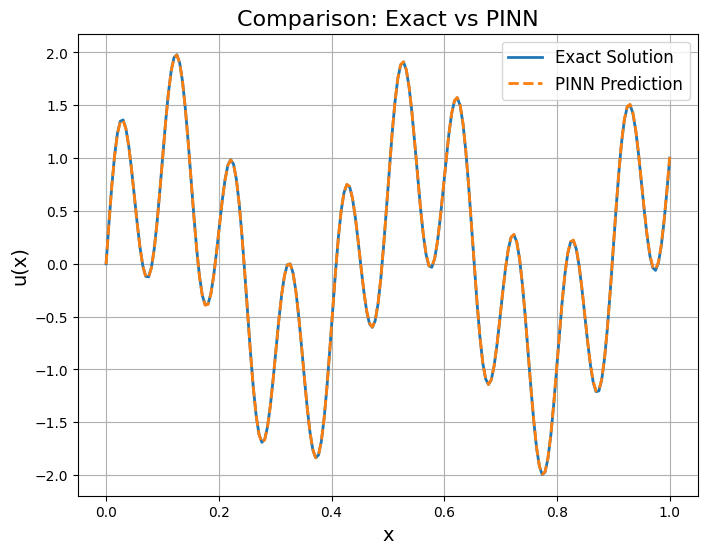

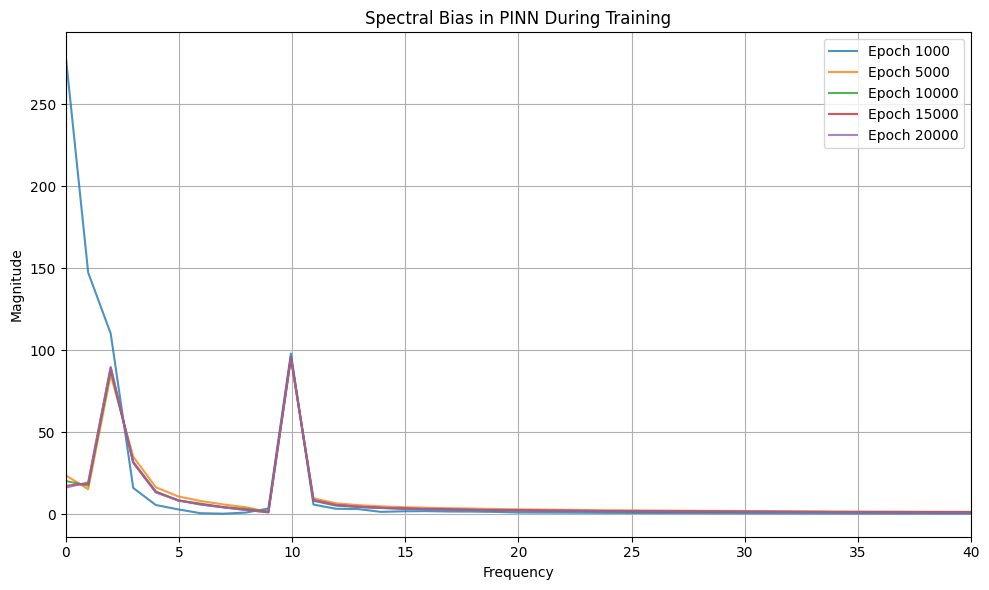

Relative error (normalized MSE) = 6.429e-03
MSE = 1.551e-05


In [ ]:
# %% import modules
import numpy as np
import jax.numpy as jnp
from jax import vjp, jit, grad
from jax.example_libraries import optimizers
from functools import partial
import time
import matplotlib.pyplot as plt

# %% initialization
def xavier_init(in_dim, out_dim):
    glorot_stddev = np.sqrt(2.0 / (in_dim + out_dim))
    W = jnp.array(glorot_stddev * np.random.normal(size=(in_dim, out_dim)))
    b = jnp.zeros(out_dim)
    return W, b

def init_params(layers):
    params = []
    for i in range(len(layers) - 1):
        in_dim, out_dim = layers[i], layers[i + 1]
        W, b = xavier_init(in_dim, out_dim)
        # g = jax.random.normal(n_out,)
        params.append({"W": W, "b": b})
    return params

# %% generic pinn function and vector gradient
def pinn_generic(params, X_in):
    X = X_in
    for layer in params[:-1]:
        X = jnp.sin(X @ layer["W"] + layer["b"])
    X = X @ params[-1]["W"] + params[-1]["b"]
    return X

def vgrad(f, x):
    y, vjp_fn = vjp(f, x)
    return vjp_fn(jnp.ones(y.shape))[0]

# %% exact solution + forcing term (updated to 9π/2 and 20π)
def exact_solution(x):
    return jnp.sin(9*jnp.pi/2 * x) + jnp.sin(20*jnp.pi * x)

def forcing_term(x):
    # u'' - u = f, with u = sin(9π/2 x) + sin(20π x)
    return (
        -(((9*jnp.pi/2)**2) + 1) * jnp.sin(9*jnp.pi/2 * x)
        -(((20*jnp.pi)**2)  + 1) * jnp.sin(20*jnp.pi   * x)
    )

# %% boundary conditions for u(0)=0, u(1)=1
X_bc = (
    (jnp.array([[0.0]]), jnp.array([[1.0]])),   # x=0 → u(0)=0
    (jnp.array([[0.0]]), jnp.array([[1.0]])),   # x=1 → u(1)=1
)



# %% FFT spectrum function
def compute_fourier_spectrum(signal, dx):
    n = len(signal)
    freqs = np.fft.fftfreq(n, d=dx)
    fft_vals = np.fft.fft(signal)
    magnitude = np.abs(fft_vals)
    return freqs[:n // 2], magnitude[:n // 2]

# %% define PINN model
class PINN:
    def __init__(self, layers, weight):
        self.weight_eqn, self.weight_bc = weight
        self.params = init_params(layers)
        self.opt_init, self.opt_update, self.get_params = optimizers.adam(1e-3)
        self.opt_state = self.opt_init(self.params)

    @partial(jit, static_argnums=(0,))
    def equation(self, params, X):
        pinn = partial(pinn_generic, params)
        fu = lambda x: pinn(x)
        dudx = lambda x: vgrad(fu, x)
        d2udx2 = lambda x: vgrad(dudx, x)
        u = fu(X)
        u_xx = d2udx2(X)
        f = forcing_term(X)
        return u_xx - u - f

    @partial(jit, static_argnums=(0,))
    def forward(self, params, X):
        pinn = partial(pinn_generic, params)
        return pinn(X)

    @partial(jit, static_argnums=(0,))
    def loss_component(self, params, X_res, X_bc):
        x_bc, y_bc = X_bc
        eq1 = self.equation(params, X_res)
        loss_res = jnp.mean(eq1 ** 2)
        x_bc_l, x_bc_r = x_bc
        u_l_pred = self.forward(params, x_bc_l)
        u_r_pred = self.forward(params, x_bc_r)
        u_l, u_r = y_bc
        loss_bc = jnp.mean((u_l - u_l_pred) ** 2 + (u_r - u_r_pred) ** 2)
        return 0.1*loss_res, loss_bc

    def loss(self, params, X_res, X_bc):
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return self.weight_eqn * loss_res + self.weight_bc * loss_bc

    @partial(jit, static_argnums=(0,))
    def update(self, i, opt_state, X_res, X_bc):
        params = self.get_params(opt_state)
        next_opt_state = self.opt_update(i, grad(self.loss)(params, X_res, X_bc), opt_state)
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return next_opt_state, (loss_res, loss_bc)

# %% prepare data
N = 1000
X = np.random.uniform(0, 1, size=(N,1))
X_res = jnp.array(X)
# X_bc = (
#     (jnp.array(0.0).reshape(-1, 1), jnp.array(1.0).reshape(-1, 1)),
#     (jnp.array(0.0).reshape(-1, 1), jnp.array(0.0).reshape(-1, 1)),
# )


# X_bc = (
#     (jnp.array(0.0).reshape(-1, 1), jnp.array(1.0).reshape(-1, 1)),
#     (jnp.array(0.0).reshape(-1, 1), jnp.array(0.0).reshape(-1, 1)),
# )

# %% training
layers = [1, 50, 50, 50, 1]
model = PINN(layers, (1, 1))
N_epochs = 40000
Y_result = []
X_result = []
log_epochs = [1000, 5000, 10000, 15000, 20000]

for epoch in range(1, N_epochs + 1):
    start = time.time()
    model.opt_state, losses = model.update(epoch, model.opt_state, X_res, X_bc)
    model.params = model.get_params(model.opt_state)
    end = time.time()

    if epoch % 1000 == 0:
        loss_res, loss_bc = losses
        print(f"Epoch: {epoch:d}, time: {end-start:.2f}s, Loss_eqn = {loss_res:.3e}, Loss_bc = {loss_bc:.3e}")

    if epoch in log_epochs:
        X_sorted = np.linspace(0, 1, 200).reshape(-1, 1)
        Y_sorted = model.forward(model.params, jnp.array(X_sorted))
        Y_result.append(np.array(Y_sorted).flatten())
        X_result.append(np.array(X_sorted).flatten())

# %% final evaluation
X_plot = np.linspace(0, 1, 200).reshape(-1, 1)
X_plot_jax = jnp.array(X_plot)
Y_pred_plot = model.forward(model.params, X_plot_jax).flatten()
Y_true_plot = exact_solution(X_plot_jax).flatten()

plt.figure(figsize=(8,6))
plt.plot(X_plot, Y_true_plot, label="Exact Solution", linewidth=2)
plt.plot(X_plot, Y_pred_plot, '--', label="PINN Prediction", linewidth=2)
plt.xlabel('x', fontsize=14)
plt.ylabel('u(x)', fontsize=14)
plt.title('Comparison: Exact vs PINN', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# %% FFT spectral bias plot
plt.figure(figsize=(10, 6))
dx = X_result[0][1] - X_result[0][0]
for i, (y, ep) in enumerate(zip(Y_result, log_epochs)):
    freqs, mag = compute_fourier_spectrum(y, dx)
    plt.plot(freqs, mag, label=f"Epoch {ep}", alpha=0.8)

plt.title("Spectral Bias in PINN During Training")
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.xlim(0, 40)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# %% Relative error
Y_true = exact_solution(X_res).flatten()
Y_pred = model.forward(model.params, X_res).flatten()

rel_err = np.mean((Y_pred - Y_true)**2) / (np.mean(Y_true)**2)
print(f"Relative error (normalized MSE) = {rel_err:.3e}")

mse = np.mean((Y_pred - Y_true)**2)
print(f"MSE = {mse:.3e}")



Epoch   100, time: 0.00s, Loss_eqn = 6.915e+04, Loss_bc = 7.702e+01
Epoch   200, time: 0.00s, Loss_eqn = 6.911e+04, Loss_bc = 6.497e+01
Epoch   300, time: 0.00s, Loss_eqn = 6.909e+04, Loss_bc = 5.538e+01
Epoch   400, time: 0.00s, Loss_eqn = 6.905e+04, Loss_bc = 4.707e+01
Epoch   500, time: 0.00s, Loss_eqn = 6.680e+04, Loss_bc = 2.278e+01
Epoch   600, time: 0.00s, Loss_eqn = 6.249e+04, Loss_bc = 6.041e+00
Epoch   700, time: 0.00s, Loss_eqn = 2.188e+04, Loss_bc = 4.599e+01
Epoch   800, time: 0.00s, Loss_eqn = 1.099e+04, Loss_bc = 4.233e+01
Epoch   900, time: 0.00s, Loss_eqn = 2.649e+03, Loss_bc = 1.961e+01
Epoch  1000, time: 0.00s, Loss_eqn = 1.569e+02, Loss_bc = 1.524e+01
Epoch  1100, time: 0.00s, Loss_eqn = 3.640e+01, Loss_bc = 5.824e+00
Epoch  1200, time: 0.00s, Loss_eqn = 2.371e+01, Loss_bc = 1.938e+00
Epoch  1300, time: 0.00s, Loss_eqn = 2.766e+01, Loss_bc = 5.549e-01
Epoch  1400, time: 0.00s, Loss_eqn = 1.444e+01, Loss_bc = 1.150e-01
Epoch  1500, time: 0.00s, Loss_eqn = 3.277e+01, 

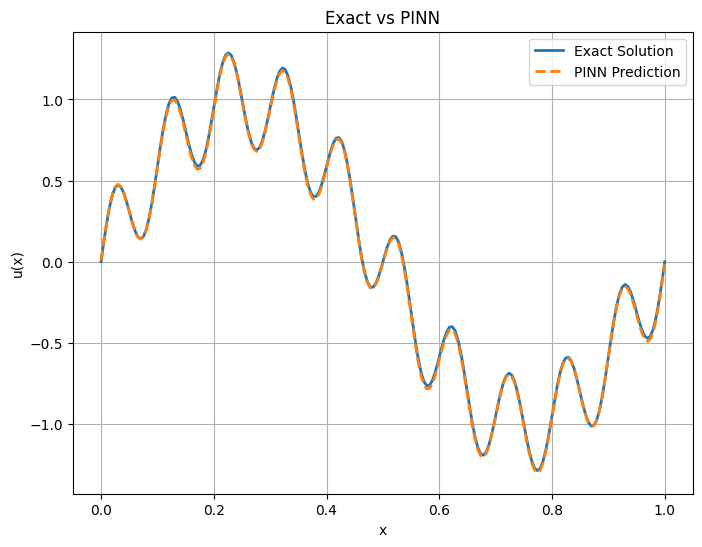

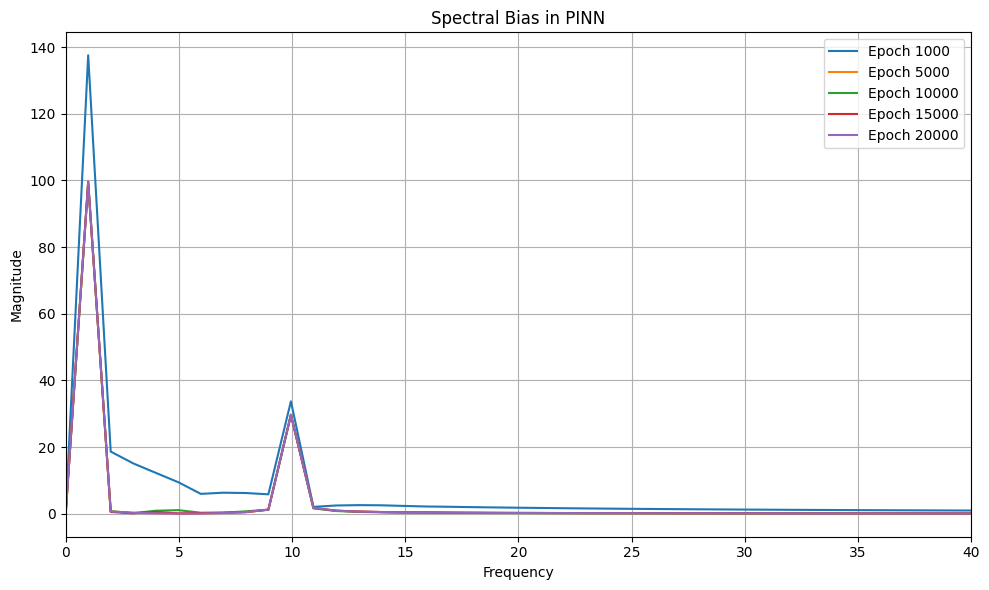

Relative Error = 9.252e-02
MSE = 1.438e-04


In [ ]:
# %% Import modules
import numpy as np
import jax.numpy as jnp
from jax import vjp, jit, grad
from jax.example_libraries import optimizers
from functools import partial
import time
import matplotlib.pyplot as plt

# %% initialization
def xavier_init(in_dim, out_dim):
    glorot_stddev = np.sqrt(2.0 / (in_dim + out_dim))
    W = jnp.array(glorot_stddev * np.random.normal(size=(in_dim, out_dim)))
    b = jnp.zeros(out_dim)
    return W, b

def init_params(layers):
    params = []
    for i in range(len(layers) - 1):
        in_dim, out_dim = layers[i], layers[i + 1]
        W, b = xavier_init(in_dim, out_dim)
        params.append({"W": W, "b": b})
    return params

# %% generic PINN function and gradient
def pinn_generic(params, X_in):
    X = X_in
    for layer in params[:-1]:
        X = jnp.sin(X @ layer["W"] + layer["b"])
    X = X @ params[-1]["W"] + params[-1]["b"]
    return X

def vgrad(f, x):
    y, vjp_fn = vjp(f, x)
    return vjp_fn(jnp.ones_like(y))[0]

# %% new ground truth and forcing
def exact_solution(x):
    return jnp.sin(2 * jnp.pi * x) + 0.3 * jnp.sin(20 * jnp.pi * x)

def forcing_term(x):
    return -(2 * jnp.pi)**2 * jnp.sin(2 * jnp.pi * x) \
           - (0.3 * (20 * jnp.pi)**2) * jnp.sin(20 * jnp.pi * x) \
           - exact_solution(x)

# %% FFT spectrum function (updated)
def compute_fourier_spectrum(signal, dx):
    # detrend
    y = signal - np.mean(signal)
    # real FFT
    n = len(y)
    freqs = np.fft.rfftfreq(n, d=dx)
    mag   = np.abs(np.fft.rfft(y))
    return freqs, mag

# %% define PINN model
class PINN:
    def __init__(self, layers, weight):
        self.weight_eqn, self.weight_bc = weight
        self.params = init_params(layers)
        self.opt_init, self.opt_update, self.get_params = optimizers.adam(1e-3)
        self.opt_state = self.opt_init(self.params)

    @partial(jit, static_argnums=(0,))
    def equation(self, params, X):
        pinn = partial(pinn_generic, params)
        fu = lambda x: pinn(x)
        dudx = lambda x: vgrad(fu, x)
        d2udx2 = lambda x: vgrad(dudx, x)
        u = fu(X)
        u_xx = d2udx2(X)
        return u_xx - u - forcing_term(X)

    @partial(jit, static_argnums=(0,))
    def forward(self, params, X):
        pinn = partial(pinn_generic, params)
        return pinn(X)

    @partial(jit, static_argnums=(0,))
    def loss_component(self, params, X_res, X_bc):
        x_bc, y_bc = X_bc
        eq1 = self.equation(params, X_res)
        loss_res = jnp.mean(eq1 ** 2)
        x_l, x_r = x_bc
        u_l = self.forward(params, x_l)
        u_r = self.forward(params, x_r)
        loss_bc = jnp.mean((y_bc[0] - u_l)**2 + (y_bc[1] - u_r)**2)
        return 0.1*loss_res, loss_bc

    def loss(self, params, X_res, X_bc):
        lr, lb = self.loss_component(params, X_res, X_bc)
        return self.weight_eqn * lr + self.weight_bc * lb

    @partial(jit, static_argnums=(0,))
    def update(self, i, opt_state, X_res, X_bc):
        params = self.get_params(opt_state)
        grads = grad(self.loss)(params, X_res, X_bc)
        new_state = self.opt_update(i, grads, opt_state)
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return new_state, (loss_res, loss_bc)

# %% prepare data
N = 1000
X = np.random.uniform(0, 1, size=(N,1))
X_res = jnp.array(X)
X_bc = (
    (jnp.array(0.0).reshape(-1, 1), jnp.array(1.0).reshape(-1, 1)),
    (jnp.array(0.0).reshape(-1, 1), jnp.array(0.0).reshape(-1, 1)),
)

# %% training
layers = [1, 50, 50, 50, 1]
model = PINN(layers, (1, 1))
N_epochs = 40000
Y_result = []
X_result = []
log_epochs = [1000, 5000, 10000, 15000, 20000]

for epoch in range(1, N_epochs + 1):
    start = time.time()
    model.opt_state, losses = model.update(epoch, model.opt_state, X_res, X_bc)
    model.params = model.get_params(model.opt_state)
    end = time.time()

    # print every 100 epochs
    if epoch % 100 == 0:
        loss_res, loss_bc = losses
        print(f"Epoch {epoch:5d}, time: {end-start:.2f}s, Loss_eqn = {loss_res:.3e}, Loss_bc = {loss_bc:.3e}")

    # log for spectral analysis
    if epoch in log_epochs:
        X_sorted = np.linspace(0, 1, 200).reshape(-1, 1)
        Y_sorted = model.forward(model.params, jnp.array(X_sorted))
        Y_result.append(np.array(Y_sorted).flatten())
        X_result.append(X_sorted.flatten())

# %% final evaluation
X_plot = np.linspace(0, 1, 200).reshape(-1, 1)
Y_pred_plot = model.forward(model.params, jnp.array(X_plot)).flatten()
Y_true_plot = exact_solution(jnp.array(X_plot)).flatten()

plt.figure(figsize=(8,6))
plt.plot(X_plot, Y_true_plot, label="Exact Solution", linewidth=2)
plt.plot(X_plot, np.array(Y_pred_plot), '--', label="PINN Prediction", linewidth=2)
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('Exact vs PINN')
plt.legend()
plt.grid(True)
plt.show()

# %% FFT spectral bias plot
plt.figure(figsize=(10, 6))
dx = X_result[0][1] - X_result[0][0]
for y, ep in zip(Y_result, log_epochs):
    freqs, mag = compute_fourier_spectrum(y, dx)
    plt.plot(freqs, mag, label=f"Epoch {ep}")
plt.xlim(0, 40)
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.title("Spectral Bias in PINN")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# %% Relative error
Y_true = exact_solution(X_res).flatten()
Y_pred = model.forward(model.params, X_res).flatten()
rel_err = np.mean((Y_pred - Y_true)**2) / (np.mean(Y_true)**2)
mse = np.mean((Y_pred - Y_true)**2)
print(f"Relative Error = {rel_err:.3e}")
print(f"MSE = {mse:.3e}")


Epoch   500: Loss_eqn = 5.909e+04, Loss_bc = 8.157e+00
Epoch  1000: Loss_eqn = 3.322e+04, Loss_bc = 1.050e+01
Epoch  1500: Loss_eqn = 1.461e+04, Loss_bc = 6.846e+00
Epoch  2000: Loss_eqn = 4.853e+03, Loss_bc = 4.676e+00
Epoch  2500: Loss_eqn = 1.354e+03, Loss_bc = 5.347e+00
Epoch  3000: Loss_eqn = 4.078e+02, Loss_bc = 4.262e+00
Epoch  3500: Loss_eqn = 1.762e+02, Loss_bc = 3.681e+00
Epoch  4000: Loss_eqn = 9.133e+01, Loss_bc = 3.490e+00
Epoch  4500: Loss_eqn = 4.751e+01, Loss_bc = 3.291e+00
Epoch  5000: Loss_eqn = 2.382e+01, Loss_bc = 3.020e+00
Epoch  5500: Loss_eqn = 1.201e+01, Loss_bc = 2.745e+00
Epoch  6000: Loss_eqn = 6.412e+00, Loss_bc = 2.412e+00
Epoch  6500: Loss_eqn = 4.134e+00, Loss_bc = 2.035e+00
Epoch  7000: Loss_eqn = 2.957e+00, Loss_bc = 1.705e+00
Epoch  7500: Loss_eqn = 2.327e+00, Loss_bc = 1.399e+00
Epoch  8000: Loss_eqn = 1.961e+00, Loss_bc = 1.107e+00
Epoch  8500: Loss_eqn = 1.691e+00, Loss_bc = 8.486e-01
Epoch  9000: Loss_eqn = 1.449e+00, Loss_bc = 6.369e-01
Epoch  950

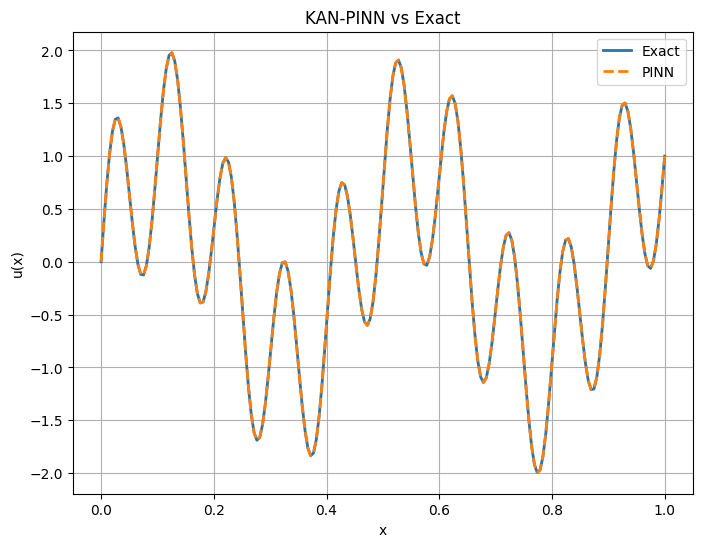

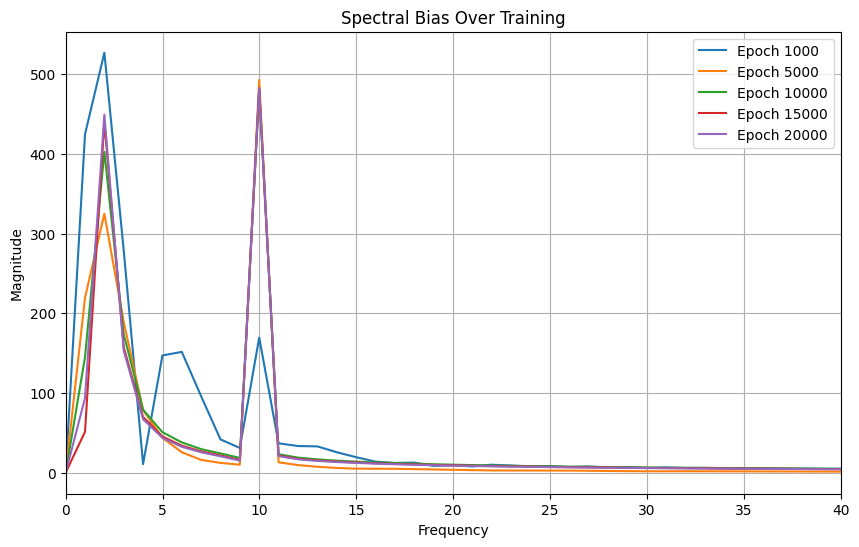

Epoch   500: Loss_eqn = 5.982e+04, Loss_bc = 1.164e+01
Epoch  1000: Loss_eqn = 3.312e+04, Loss_bc = 1.521e+01
Epoch  1500: Loss_eqn = 1.434e+04, Loss_bc = 1.594e+01
Epoch  2000: Loss_eqn = 5.401e+03, Loss_bc = 1.440e+01
Epoch  2500: Loss_eqn = 1.822e+03, Loss_bc = 1.078e+01
Epoch  3000: Loss_eqn = 5.321e+02, Loss_bc = 7.668e+00
Epoch  3500: Loss_eqn = 1.735e+02, Loss_bc = 6.656e+00
Epoch  4000: Loss_eqn = 8.415e+01, Loss_bc = 6.501e+00
Epoch  4500: Loss_eqn = 4.541e+01, Loss_bc = 6.411e+00
Epoch  5000: Loss_eqn = 2.562e+01, Loss_bc = 5.985e+00
Epoch  5500: Loss_eqn = 1.636e+01, Loss_bc = 5.553e+00
Epoch  6000: Loss_eqn = 1.132e+01, Loss_bc = 5.137e+00
Epoch  6500: Loss_eqn = 8.146e+00, Loss_bc = 4.652e+00
Epoch  7000: Loss_eqn = 6.032e+00, Loss_bc = 4.120e+00
Epoch  7500: Loss_eqn = 4.665e+00, Loss_bc = 3.572e+00
Epoch  8000: Loss_eqn = 3.837e+00, Loss_bc = 3.017e+00
Epoch  8500: Loss_eqn = 3.317e+00, Loss_bc = 2.468e+00
Epoch  9000: Loss_eqn = 2.921e+00, Loss_bc = 1.968e+00
Epoch  950

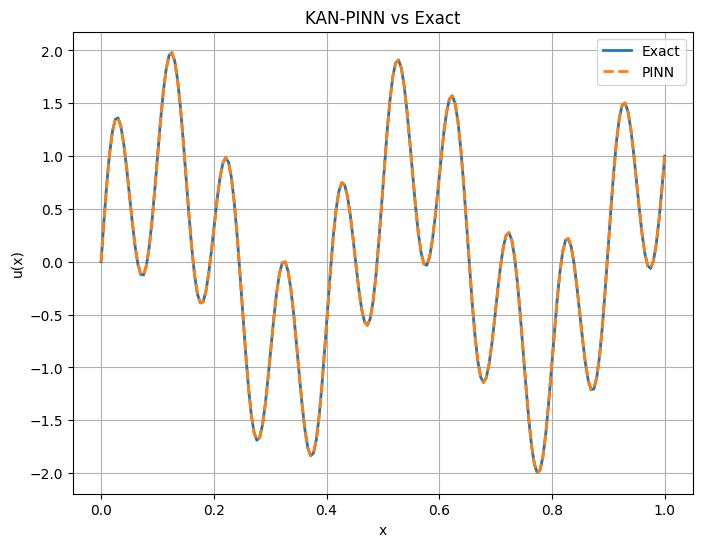

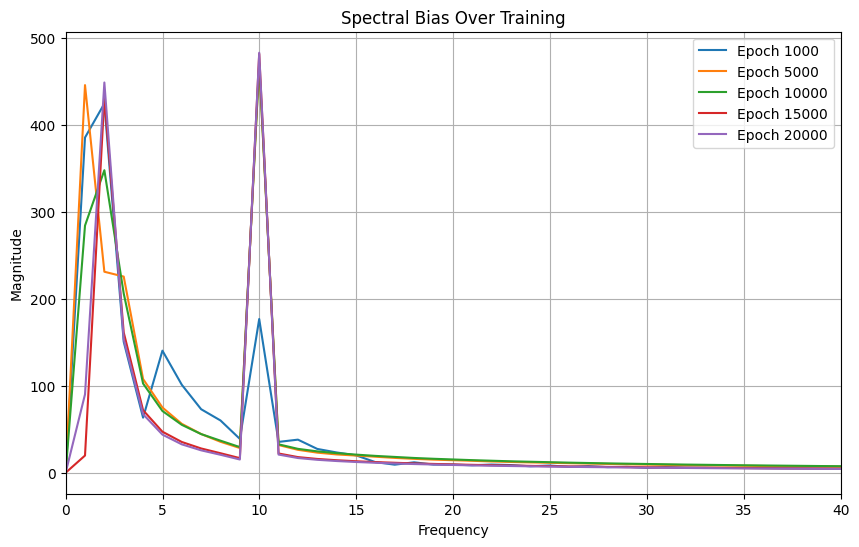

In [ ]:
# %% Import modules
import numpy as np
import jax
import jax.numpy as jnp
from jax import vjp, jit, grad
from jax.example_libraries import optimizers
from functools import partial
import matplotlib.pyplot as plt

# %% Chebyshev helper functions
def chebyshev_recursive(x, degree):
    if degree == 0:
        return x * 0 + 1
    elif degree == 1:
        return x
    else:
        T_n_minus_1 = x
        T_n_minus_2 = x * 0 + 1
        for _ in range(2, degree + 1):
            T_n = 2 * x * T_n_minus_1 - T_n_minus_2
            T_n_minus_2, T_n_minus_1 = T_n_minus_1, T_n
        return T_n

def chebyshev_cosine(x, degree):
    return jnp.cos(degree * jnp.arccos(x))

# %% KAN init
def init_params_kan2(layers, degree):
    keys = jax.random.split(jax.random.PRNGKey(123), len(layers) - 1)
    params = []
    for key, n_in, n_out in zip(keys[:-1], layers[:-2], layers[1:-1]):
        W = jax.random.normal(key, (n_in, n_out, degree+1)) / jnp.sqrt(n_in*(degree+1))
        g = jax.random.normal(key, (n_out,))
        params.append({'W': W, 'g': g})
    Wf = jax.random.normal(keys[-1], (layers[-2], layers[-1])) / jnp.sqrt(layers[-2])
    Bf = jax.random.normal(keys[-1], (layers[-1],))
    params.append({'W': Wf, 'B': Bf})
    return params

# %% KAN forward pass
def fwd_kan(params, t, activation=jax.nn.tanh, use_cosine=False):
    X = t.reshape((-1, 1))
    *hidden, last = params
    for layer in hidden:
        X = activation(X)
        W = layer['W']
        deg = W.shape[-1] - 1
        X_stack = jnp.stack([
            chebyshev_cosine(X, d) if use_cosine else chebyshev_recursive(X, d)
            for d in range(deg+1)
        ], axis=-1)
        X = jnp.einsum("bid,iod->bo", X_stack, W)
        X = activation(X)
    return X @ last['W'] + last['B']

# %% vjp-based gradient
def vgrad(f, x):
    y, vjp_fn = vjp(f, x)
    return vjp_fn(jnp.ones_like(y))[0]

# %% exact solution + forcing
def exact_solution(x):
    return jnp.sin(9*jnp.pi/2 * x) + jnp.sin(20*jnp.pi * x)

def forcing_term(x):
    # u'' - u = f, with u = sin(9π/2 x) + sin(20π x)
    return (
        -(((9*jnp.pi/2)**2) + 1) * jnp.sin(9*jnp.pi/2 * x)
        -(((20*jnp.pi)**2)  + 1) * jnp.sin(20*jnp.pi   * x)
    )

# %% boundary conditions for u(0)=0, u(1)=1
X_bc = (
    (jnp.array([[0.0]]), jnp.array([[1.0]])),   # x=0 ,  x=1
    (jnp.array([[0.0]]), jnp.array([[1.0]])),   # u(0)=0 ,  u(1)=1
)


# %% PINN-KAN class
class PINN_KAN:
    def __init__(self, layers, degree, weight=(1,1), activation=jax.nn.tanh, use_cosine=False):
        self.degree = degree
        self.activation = activation
        self.use_cosine = use_cosine
        self.weight_eqn, self.weight_bc = weight
        self.params = init_params_kan2(layers, degree)
        self.opt_init, self.opt_update, self.get_params = optimizers.adam(1e-5)
        self.opt_state = self.opt_init(self.params)

    @partial(jit, static_argnums=0)
    def equation(self, params, X):
        pinn = lambda x: fwd_kan(params, x, activation=self.activation, use_cosine=self.use_cosine)
        dudx = lambda x: vgrad(pinn, x)
        d2udx2 = lambda x: vgrad(dudx, x)
        u = pinn(X)
        u_xx = d2udx2(X)
        return u_xx - u - forcing_term(X)

    @partial(jit, static_argnums=0)
    def forward(self, params, X):
        return fwd_kan(params, X, activation=self.activation, use_cosine=self.use_cosine)

    @partial(jit, static_argnums=0)
    def loss_component(self, params, X_res, X_bc):
        (x_bc, y_bc) = X_bc
        loss_res = jnp.mean(self.equation(params, X_res)**2)
        u_pred_l = self.forward(params, x_bc[0])
        u_pred_r = self.forward(params, x_bc[1])
        loss_bc  = jnp.mean((y_bc[0] - u_pred_l)**2 + (y_bc[1] - u_pred_r)**2)
        return 0.01*loss_res, loss_bc

    def loss(self, params, X_res, X_bc):
        lr, lbc = self.loss_component(params, X_res, X_bc)
        return self.weight_eqn*lr + self.weight_bc*lbc

    @partial(jit, static_argnums=0)
    def update(self, i, opt_state, X_res, X_bc):
        params = self.get_params(opt_state)
        grads  = grad(self.loss)(params, X_res, X_bc)
        new_opt = self.opt_update(i, grads, opt_state)
        return new_opt

# %% Training & Logging
N_train = 1000
X_res = jnp.array(np.random.rand(N_train,1))
# X_bc = (
#     (jnp.array(0.0).reshape(-1, 1), jnp.array(1.0).reshape(-1, 1)),
#     (jnp.array(0.0).reshape(-1, 1), jnp.array(0.0).reshape(-1, 1)),
# )

# FFT grid (unchanged)
N_spec = 1000
X_spec = np.linspace(0,1,N_spec).reshape(-1,1)
X_spec_jax = jnp.array(X_spec)

layers = [1, 50, 50, 50, 1]
degree = 5
model  = PINN_KAN(layers, degree, weight=(1,1))

epochs     = 50000
log_epochs = [1000, 5000, 10000, 15000, 20000]
Y_logs     = []

for ep in range(1, epochs+1):
    # 1) update
    model.opt_state = model.update(ep, model.opt_state, X_res, X_bc)

    # 2) fetch losses & print every 100 epochs
    if ep % 500 == 0:
        params = model.get_params(model.opt_state)
        lr, lbc = model.loss_component(params, X_res, X_bc)
        print(f"Epoch {ep:5d}: Loss_eqn = {lr:.3e}, Loss_bc = {lbc:.3e}")

    # 3) log for spectrum at chosen epochs
    if ep in log_epochs:
        params     = model.get_params(model.opt_state)
        y_spec     = np.array(model.forward(params, X_spec_jax)).flatten()
        Y_logs.append((ep, y_spec))

# %% final MSE on training set
params = model.get_params(model.opt_state)
Y_pred = np.array(model.forward(params, X_res)).flatten()
Y_true = np.array(exact_solution(X_res)).flatten()
mse    = np.mean((Y_pred - Y_true)**2)
print(f"\nFinal MSE on training set = {mse:.3e}")

# %% Plot PINN vs exact on a test grid
X_plot = np.linspace(0,1,200).reshape(-1,1)
Y_true_plot = exact_solution(jnp.array(X_plot)).flatten()
Y_pred_plot = model.forward(params, jnp.array(X_plot)).flatten()

plt.figure(figsize=(8,6))
plt.plot(X_plot, Y_true_plot, label="Exact", linewidth=2)
plt.plot(X_plot, np.array(Y_pred_plot), '--', label="PINN", linewidth=2)
plt.legend(); plt.grid(True)
plt.title("KAN-PINN vs Exact"); plt.xlabel("x"); plt.ylabel("u(x)")
plt.show()

# %% Compute and plot spectral content (fixed)
def compute_fourier_spectrum(signal, dx):
    y = signal - np.mean(signal)
    n = len(y)
    freqs = np.fft.rfftfreq(n, d=dx)
    mag   = np.abs(np.fft.rfft(y))
    return freqs, mag

plt.figure(figsize=(10,6))
dx = X_spec[1,0] - X_spec[0,0]
for ep, y in Y_logs:
    freqs, mag = compute_fourier_spectrum(y, dx)
    plt.plot(freqs, mag, label=f"Epoch {ep}")
plt.xlim(0,40); plt.xlabel("Frequency"); plt.ylabel("Magnitude")
plt.title("Spectral Bias Over Training"); plt.legend(); plt.grid(True)
plt.show()

Y_true = exact_solution(X_res).flatten()
Y_pred = model.forward(model.params, X_res).flatten()

# rel_err = np.mean((Y_pred - Y_true)**2) / (np.mean(Y_true)**2)




Epoch   500: Loss_eqn = 6.034e+04, Loss_bc = 5.857e+00
Epoch  1000: Loss_eqn = 3.949e+04, Loss_bc = 5.811e+00
Epoch  1500: Loss_eqn = 2.067e+04, Loss_bc = 6.864e+00
Epoch  2000: Loss_eqn = 7.894e+03, Loss_bc = 7.774e+00
Epoch  2500: Loss_eqn = 1.757e+03, Loss_bc = 7.606e+00
Epoch  3000: Loss_eqn = 2.925e+02, Loss_bc = 7.244e+00
Epoch  3500: Loss_eqn = 1.013e+02, Loss_bc = 6.414e+00
Epoch  4000: Loss_eqn = 4.590e+01, Loss_bc = 5.678e+00
Epoch  4500: Loss_eqn = 2.207e+01, Loss_bc = 4.989e+00
Epoch  5000: Loss_eqn = 1.169e+01, Loss_bc = 4.261e+00
Epoch  5500: Loss_eqn = 6.929e+00, Loss_bc = 3.469e+00
Epoch  6000: Loss_eqn = 4.563e+00, Loss_bc = 2.645e+00
Epoch  6500: Loss_eqn = 3.292e+00, Loss_bc = 1.891e+00
Epoch  7000: Loss_eqn = 2.552e+00, Loss_bc = 1.296e+00
Epoch  7500: Loss_eqn = 2.092e+00, Loss_bc = 8.689e-01
Epoch  8000: Loss_eqn = 1.744e+00, Loss_bc = 5.754e-01
Epoch  8500: Loss_eqn = 1.470e+00, Loss_bc = 3.808e-01
Epoch  9000: Loss_eqn = 1.227e+00, Loss_bc = 2.564e-01
Epoch  950

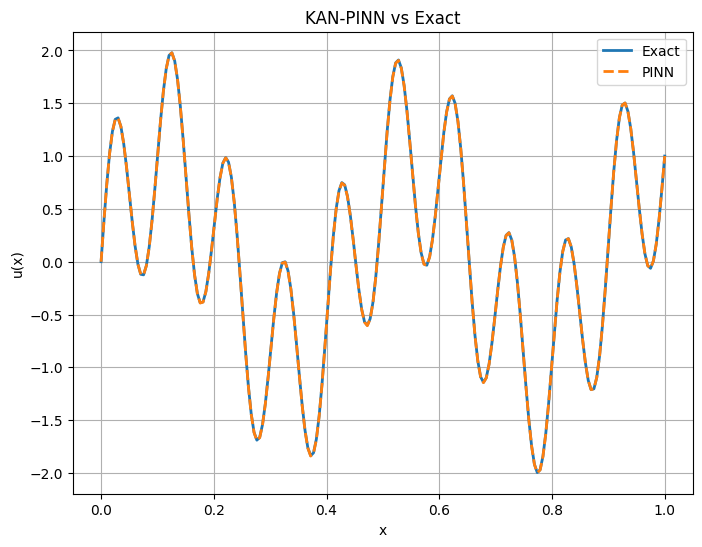

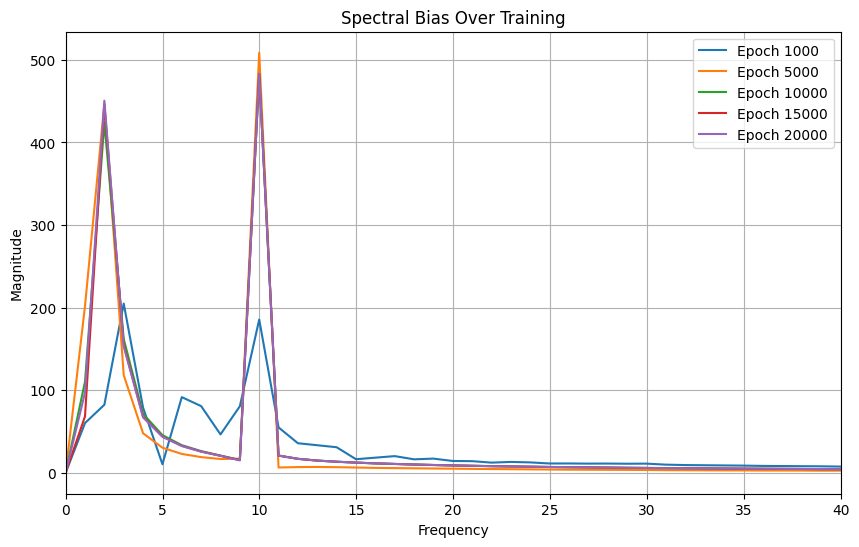

In [ ]:
# %% Import modules
import numpy as np
import jax
import jax.numpy as jnp
from jax import vjp, jit, grad
from jax.example_libraries import optimizers
from functools import partial
import matplotlib.pyplot as plt

# %% Chebyshev helper functions
def chebyshev_recursive(x, degree):
    if degree == 0:
        return x * 0 + 1
    elif degree == 1:
        return x
    else:
        T_n_minus_1 = x
        T_n_minus_2 = x * 0 + 1
        for _ in range(2, degree + 1):
            T_n = 2 * x * T_n_minus_1 - T_n_minus_2
            T_n_minus_2, T_n_minus_1 = T_n_minus_1, T_n
        return T_n

def chebyshev_cosine(x, degree):
    return jnp.cos(degree * jnp.arccos(x))

# %% KAN init
def init_params_kan2(layers, degree):
    keys = jax.random.split(jax.random.PRNGKey(123), len(layers) - 1)
    params = []
    for key, n_in, n_out in zip(keys[:-1], layers[:-2], layers[1:-1]):
        W = jax.random.normal(key, (n_in, n_out, degree+1)) / jnp.sqrt(n_in*(degree+1))
        g = jax.random.normal(key, (n_out,))
        params.append({'W': W, 'g': g})
    Wf = jax.random.normal(keys[-1], (layers[-2], layers[-1])) / jnp.sqrt(layers[-2])
    Bf = jax.random.normal(keys[-1], (layers[-1],))
    params.append({'W': Wf, 'B': Bf})
    return params

# %% KAN forward pass
def fwd_kan(params, t, activation=jax.nn.tanh, use_cosine=False):
    t = activation(t)
    X = t.reshape((-1, 1))
    *hidden, last = params
    for layer in hidden:
        # X = activation(X)
        W = layer['W']
        deg = W.shape[-1] - 1
        X_stack = jnp.stack([
            chebyshev_cosine(X, d) if use_cosine else chebyshev_recursive(X, d)
            for d in range(deg+1)
        ], axis=-1)
        X = jnp.einsum("bid,iod->bo", X_stack, W)
        X = layer['g']* X
        X = activation(X)
    return X @ last['W'] + last['B']

# %% vjp-based gradient
def vgrad(f, x):
    y, vjp_fn = vjp(f, x)
    return vjp_fn(jnp.ones_like(y))[0]

# %% exact solution + forcing
def exact_solution(x):
    return jnp.sin(9*jnp.pi/2 * x) + jnp.sin(20*jnp.pi * x)

def forcing_term(x):
    # u'' - u = f, with u = sin(9π/2 x) + sin(20π x)
    return (
        -(((9*jnp.pi/2)**2) + 1) * jnp.sin(9*jnp.pi/2 * x)
        -(((20*jnp.pi)**2)  + 1) * jnp.sin(20*jnp.pi   * x)
    )

# %% boundary conditions for u(0)=0, u(1)=1
X_bc = (
    (jnp.array([[0.0]]), jnp.array([[1.0]])),   # x=0 ,  x=1
    (jnp.array([[0.0]]), jnp.array([[1.0]])),   # u(0)=0 ,  u(1)=1
)


# %% PINN-KAN class
class PINN_KAN:
    def __init__(self, layers, degree, weight=(1,1), activation=jax.nn.tanh, use_cosine=False):
        self.degree = degree
        self.activation = activation
        self.use_cosine = use_cosine
        self.weight_eqn, self.weight_bc = weight
        self.params = init_params_kan2(layers, degree)
        self.opt_init, self.opt_update, self.get_params = optimizers.adam(1e-5)
        self.opt_state = self.opt_init(self.params)

    @partial(jit, static_argnums=0)
    def equation(self, params, X):
        pinn = lambda x: fwd_kan(params, x, activation=self.activation, use_cosine=self.use_cosine)
        dudx = lambda x: vgrad(pinn, x)
        d2udx2 = lambda x: vgrad(dudx, x)
        u = pinn(X)
        u_xx = d2udx2(X)
        return u_xx - u - forcing_term(X)

    @partial(jit, static_argnums=0)
    def forward(self, params, X):
        return fwd_kan(params, X, activation=self.activation, use_cosine=self.use_cosine)

    @partial(jit, static_argnums=0)
    def loss_component(self, params, X_res, X_bc):
        (x_bc, y_bc) = X_bc
        loss_res = jnp.mean(self.equation(params, X_res)**2)
        u_pred_l = self.forward(params, x_bc[0])
        u_pred_r = self.forward(params, x_bc[1])
        loss_bc  = jnp.mean((y_bc[0] - u_pred_l)**2 + (y_bc[1] - u_pred_r)**2)
        return 0.01*loss_res, loss_bc

    def loss(self, params, X_res, X_bc):
        lr, lbc = self.loss_component(params, X_res, X_bc)
        return self.weight_eqn*lr + self.weight_bc*lbc

    @partial(jit, static_argnums=0)
    def update(self, i, opt_state, X_res, X_bc):
        params = self.get_params(opt_state)
        grads  = grad(self.loss)(params, X_res, X_bc)
        new_opt = self.opt_update(i, grads, opt_state)
        return new_opt

# %% Training & Logging
N_train = 1000
X_res = jnp.array(np.random.rand(N_train,1))
# X_bc = (
#     (jnp.array(0.0).reshape(-1, 1), jnp.array(1.0).reshape(-1, 1)),
#     (jnp.array(0.0).reshape(-1, 1), jnp.array(0.0).reshape(-1, 1)),
# )

# FFT grid (unchanged)
N_spec = 1000
X_spec = np.linspace(0,1,N_spec).reshape(-1,1)
X_spec_jax = jnp.array(X_spec)

layers = [1, 50, 50, 50, 1]
degree = 5
model  = PINN_KAN(layers, degree, weight=(1,1))

epochs     = 50000
log_epochs = [1000, 5000, 10000, 15000, 20000]
Y_logs     = []

for ep in range(1, epochs+1):
    # 1) update
    model.opt_state = model.update(ep, model.opt_state, X_res, X_bc)

    # 2) fetch losses & print every 100 epochs
    if ep % 500 == 0:
        params = model.get_params(model.opt_state)
        lr, lbc = model.loss_component(params, X_res, X_bc)
        print(f"Epoch {ep:5d}: Loss_eqn = {lr:.3e}, Loss_bc = {lbc:.3e}")

    # 3) log for spectrum at chosen epochs
    if ep in log_epochs:
        params     = model.get_params(model.opt_state)
        y_spec     = np.array(model.forward(params, X_spec_jax)).flatten()
        Y_logs.append((ep, y_spec))

# %% final MSE on training set
params = model.get_params(model.opt_state)
Y_pred = np.array(model.forward(params, X_res)).flatten()
Y_true = np.array(exact_solution(X_res)).flatten()
mse    = np.mean((Y_pred - Y_true)**2)
print(f"\nFinal MSE on training set = {mse:.3e}")

# %% Plot PINN vs exact on a test grid
X_plot = np.linspace(0,1,200).reshape(-1,1)
Y_true_plot = exact_solution(jnp.array(X_plot)).flatten()
Y_pred_plot = model.forward(params, jnp.array(X_plot)).flatten()

plt.figure(figsize=(8,6))
plt.plot(X_plot, Y_true_plot, label="Exact", linewidth=2)
plt.plot(X_plot, np.array(Y_pred_plot), '--', label="PINN", linewidth=2)
plt.legend(); plt.grid(True)
plt.title("KAN-PINN vs Exact"); plt.xlabel("x"); plt.ylabel("u(x)")
plt.show()

# %% Compute and plot spectral content (fixed)
def compute_fourier_spectrum(signal, dx):
    y = signal - np.mean(signal)
    n = len(y)
    freqs = np.fft.rfftfreq(n, d=dx)
    mag   = np.abs(np.fft.rfft(y))
    return freqs, mag

plt.figure(figsize=(10,6))
dx = X_spec[1,0] - X_spec[0,0]
for ep, y in Y_logs:
    freqs, mag = compute_fourier_spectrum(y, dx)
    plt.plot(freqs, mag, label=f"Epoch {ep}")
plt.xlim(0,40); plt.xlabel("Frequency"); plt.ylabel("Magnitude")
plt.title("Spectral Bias Over Training"); plt.legend(); plt.grid(True)
plt.show()

Y_true = exact_solution(X_res).flatten()
Y_pred = model.forward(model.params, X_res).flatten()

# rel_err = np.mean((Y_pred - Y_true)**2) / (np.mean(Y_true)**2)




#PIKAN

Epoch: 100, Loss_eqn = 5.027e+04, Loss_bc = 3.557e-01
Epoch: 200, Loss_eqn = 4.171e+04, Loss_bc = 6.706e-01
Epoch: 300, Loss_eqn = 3.589e+04, Loss_bc = 1.189e+00
Epoch: 400, Loss_eqn = 3.054e+04, Loss_bc = 1.745e+00
Epoch: 500, Loss_eqn = 2.531e+04, Loss_bc = 2.250e+00
Epoch: 600, Loss_eqn = 2.054e+04, Loss_bc = 2.716e+00
Epoch: 700, Loss_eqn = 1.650e+04, Loss_bc = 3.191e+00
Epoch: 800, Loss_eqn = 1.325e+04, Loss_bc = 3.650e+00
Epoch: 900, Loss_eqn = 1.065e+04, Loss_bc = 3.958e+00
Epoch: 1000, Loss_eqn = 8.529e+03, Loss_bc = 4.008e+00
Epoch: 1100, Loss_eqn = 6.710e+03, Loss_bc = 3.787e+00
Epoch: 1200, Loss_eqn = 5.097e+03, Loss_bc = 3.367e+00
Epoch: 1300, Loss_eqn = 3.689e+03, Loss_bc = 2.806e+00
Epoch: 1400, Loss_eqn = 2.516e+03, Loss_bc = 2.184e+00
Epoch: 1500, Loss_eqn = 1.610e+03, Loss_bc = 1.628e+00
Epoch: 1600, Loss_eqn = 9.830e+02, Loss_bc = 1.177e+00
Epoch: 1700, Loss_eqn = 5.983e+02, Loss_bc = 8.430e-01
Epoch: 1800, Loss_eqn = 3.849e+02, Loss_bc = 6.076e-01
Epoch: 1900, Loss_e

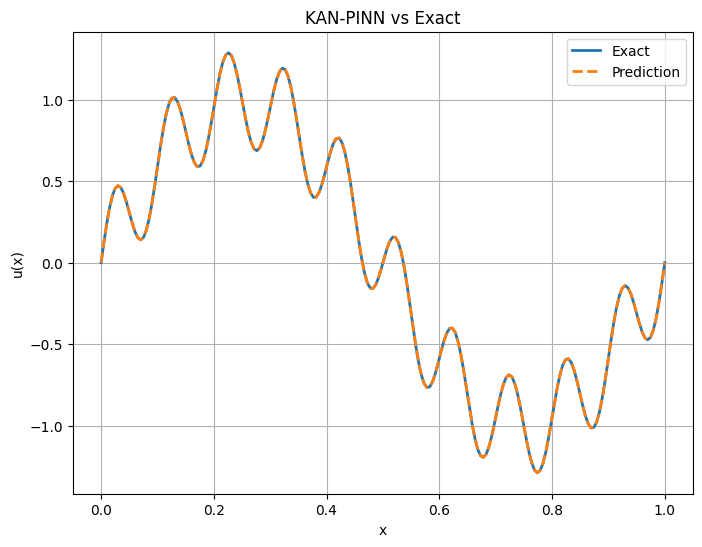

Relative Error = 1.072e-03
MSE = 3.675e-09


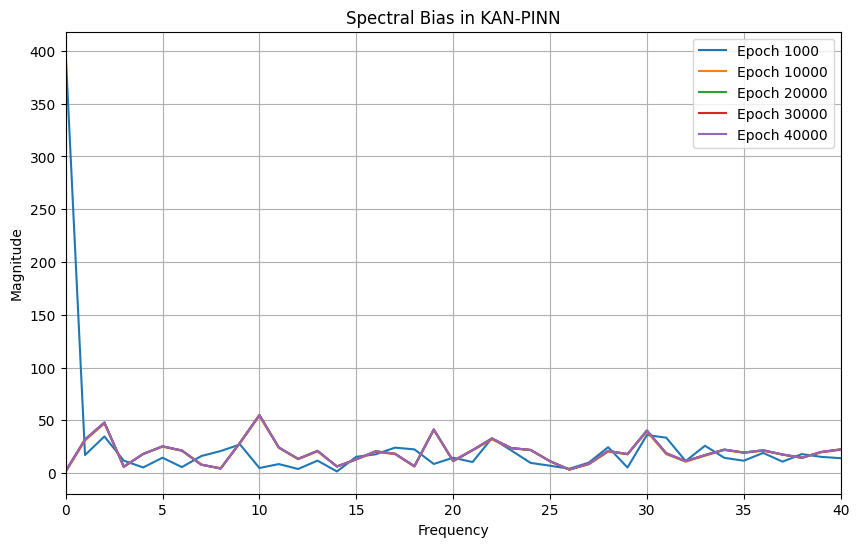

In [ ]:
# %% Import modules
import numpy as np
import jax
import jax.numpy as jnp
from jax import vjp, jit, grad
from jax.example_libraries import optimizers
from functools import partial
import time
import matplotlib.pyplot as plt

# %% Chebyshev helper functions
def chebyshev_recursive(x, degree):
    if degree == 0:
        return x * 0 + 1
    elif degree == 1:
        return x
    else:
        T_n_minus_1 = x
        T_n_minus_2 = x * 0 + 1
        for n in range(2, degree + 1):
            T_n = 2 * x * T_n_minus_1 - T_n_minus_2
            T_n_minus_2, T_n_minus_1 = T_n_minus_1, T_n
        return T_n

def chebyshev_cosine(x, degree):
    return jnp.cos(degree * jnp.arccos(x))

# %% KAN init
def init_params_kan2(layers, degree):
    keys = jax.random.split(jax.random.PRNGKey(123), len(layers) - 1)
    params = []
    for key, n_in, n_out in zip(keys[:-1], layers[:-2], layers[1:-1]):
        W = jax.random.normal(key, shape=(n_in, n_out, degree + 1)) / jnp.sqrt(n_in * (degree + 1))
        g = jax.random.normal(key, shape=(n_out,))
        params.append({'W': W, 'g': g})
    W = jax.random.normal(keys[-1], shape=(layers[-2], layers[-1])) / jnp.sqrt(layers[-2])
    B = jax.random.normal(keys[-1], shape=(layers[-1],))
    params.append({'W': W, 'B': B})
    return params

# %% KAN forward pass
# def fwd_kan(params, t, activation=jax.nn.tanh, use_cosine=False):
#     t = activation(t)
#     X = t.reshape((-1, 1))
#     *hidden, last = params
#     for layer in hidden:
#         W = layer['W']
#         degree = W.shape[-1] - 1
#         X_stack = jnp.stack([chebyshev_cosine(X, d) if use_cosine else chebyshev_recursive(X, d) for d in range(degree + 1)], axis=-1)
#         X = jnp.einsum("bid,iod->bo", X_stack, W)
#         # X = layer['g'] * X
#         X = activation(X)
#     return X @ last['W'] + last['B']
def fwd_kan(params, t, activation=jax.nn.tanh, use_cosine=False):
    # t = 0.01 * t
    # t = activation(t)
    X = t.reshape((-1, 1))
    *hidden, last = params
    for layer in hidden:
        cheby_coeffs = layer['W']
        degree = cheby_coeffs.shape[2] - 1
        X = activation(X)
        X_stack = jnp.stack([chebyshev_recursive(X, d) for d in range(degree + 1)], axis=-1)
        X = jnp.einsum("bid,iod->bo", X_stack, cheby_coeffs)
    if X.shape[1] > 1:
        X = X[:, 0:1]

        # X = jnp.reshape(X, (outdim,))
        # X = layer['g'] * X
        # X = activation(X)
    return X #@ last['W'] + last['B']
# %% vgrad
def vgrad(f, x):
    y, vjp_fn = vjp(f, x)
    return vjp_fn(jnp.ones_like(y))[0]

# %% Target solution with multiple frequencies
# %% new ground truth and forcing term (low + high frequency)
def exact_solution(x):
    return jnp.sin(2 * jnp.pi * x) + 0.3 * jnp.sin(20 * jnp.pi * x)

def forcing_term(x):
    return -(2 * jnp.pi)**2 * jnp.sin(2 * jnp.pi * x) - (0.3 * (20 * jnp.pi)**2) * jnp.sin(20 * jnp.pi * x) - exact_solution(x)

# %% KAN-PINN Class
class PINN_KAN:
    def __init__(self, layers, degree, weight, activation=jax.nn.tanh, use_cosine=False):
        self.degree = degree
        self.activation = activation
        self.use_cosine = use_cosine
        self.weight_eqn, self.weight_bc = weight
        self.params = init_params_kan2(layers, degree)
        self.opt_init, self.opt_update, self.get_params = optimizers.adam(1e-5)
        self.opt_state = self.opt_init(self.params)

    @partial(jit, static_argnums=(0,))
    def equation(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        fu = lambda x: pinn(x)
        dudx = lambda x: vgrad(fu, x)
        d2udx2 = lambda x: vgrad(dudx, x)
        u = fu(X)
        u_xx = d2udx2(X)
        f = forcing_term(X)
        return u_xx - u - f

    @partial(jit, static_argnums=(0,))
    def forward(self, params, X):
        return fwd_kan(params, X, activation=self.activation, use_cosine=self.use_cosine)

    @partial(jit, static_argnums=(0,))
    def loss_component(self, params, X_res, X_bc):
        x_bc, y_bc = X_bc
        eq1 = self.equation(params, X_res)
        loss_res = jnp.mean(eq1 ** 2)
        x_bc_l, x_bc_r = x_bc
        u_l_pred = self.forward(params, x_bc_l)
        u_r_pred = self.forward(params, x_bc_r)
        u_l, u_r = y_bc
        loss_bc = jnp.mean((u_l - u_l_pred)**2 + (u_r - u_r_pred)**2)
        return 0.1*loss_res, loss_bc

    def loss(self, params, X_res, X_bc):
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return self.weight_eqn * loss_res + self.weight_bc * loss_bc

    @partial(jit, static_argnums=(0,))
    def update(self, i, opt_state, X_res, X_bc):
        params = self.get_params(opt_state)
        grads = grad(self.loss)(params, X_res, X_bc)
        opt_state = self.opt_update(i, grads, opt_state)
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return opt_state, (loss_res, loss_bc)

# %% Data prep
N = 1000
X = np.random.uniform(0, 1, size=(N,1))
X_res = jnp.array(X)

X_bc = (
    (jnp.array(0.0).reshape(-1, 1), jnp.array(1.0).reshape(-1, 1)),
    (jnp.array(0.0).reshape(-1, 1), jnp.array(0.0).reshape(-1, 1)),
)


# %% Train
layers = [1, 50, 50,50, 1]
degree = 5
model = PINN_KAN(layers, degree, weight=(1, 1))
N_epochs = 50000
Y_result = []
log_epochs = [1000, 10000, 20000, 30000, 40000]

for epoch in range(1, N_epochs + 1):
    model.opt_state, losses = model.update(epoch, model.opt_state, X_res, X_bc)
    model.params = model.get_params(model.opt_state)
    if epoch % 100 == 0:
        loss_res, loss_bc = losses
        print(f"Epoch: {epoch}, Loss_eqn = {loss_res:.3e}, Loss_bc = {loss_bc:.3e}")
    if epoch in log_epochs:
        Y_result.append(np.array(model.forward(model.params, X_res)))

# %% Plot solution
X_plot = np.linspace(0, 1, 200).reshape(-1, 1)
Y_pred_plot = model.forward(model.params, jnp.array(X_plot)).flatten()
Y_true_plot = exact_solution(jnp.array(X_plot)).flatten()

plt.figure(figsize=(8,6))
plt.plot(X_plot, Y_true_plot, label="Exact", linewidth=2)
plt.plot(X_plot, Y_pred_plot, '--', label="Prediction", linewidth=2)
plt.legend(), plt.grid(), plt.title("KAN-PINN vs Exact"), plt.xlabel("x"), plt.ylabel("u(x)")
plt.show()

# %% Error metrics
Y_true = exact_solution(X_res).flatten()
Y_pred = model.forward(model.params, X_res).flatten()
rel_err = np.mean((Y_pred - Y_true)**2) / (np.mean(Y_true)**2)
mse = np.mean((Y_pred - Y_true)**2)
print(f"Relative Error = {rel_err:.3e}")
print(f"MSE = {mse:.3e}")

# %% FFT Spectral Bias
def compute_fourier_spectrum(signal, dx):
    n = len(signal)
    freqs = np.fft.fftfreq(n, d=dx)
    mag = np.abs(np.fft.fft(signal))
    return freqs[:n//2], mag[:n//2]

plt.figure(figsize=(10,6))
dx = 1 / len(X_res)
for i, (y, ep) in enumerate(zip(Y_result, log_epochs)):
    freqs, mag = compute_fourier_spectrum(np.array(y).flatten(), dx)
    plt.plot(freqs, mag, label=f"Epoch {ep}")
plt.xlim(0, 40)
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.title("Spectral Bias in KAN-PINN")
plt.legend()
plt.grid(True)
plt.show()


Epoch: 100, Loss_eqn = 5.693e+04, Loss_bc = 8.226e+00
Epoch: 200, Loss_eqn = 5.101e+04, Loss_bc = 8.798e+00
Epoch: 300, Loss_eqn = 4.499e+04, Loss_bc = 9.495e+00
Epoch: 400, Loss_eqn = 3.910e+04, Loss_bc = 1.032e+01
Epoch: 500, Loss_eqn = 3.368e+04, Loss_bc = 1.072e+01
Epoch: 600, Loss_eqn = 2.866e+04, Loss_bc = 1.067e+01
Epoch: 700, Loss_eqn = 2.409e+04, Loss_bc = 1.029e+01
Epoch: 800, Loss_eqn = 2.011e+04, Loss_bc = 9.617e+00
Epoch: 900, Loss_eqn = 1.678e+04, Loss_bc = 8.821e+00
Epoch: 1000, Loss_eqn = 1.404e+04, Loss_bc = 8.195e+00
Epoch: 1100, Loss_eqn = 1.161e+04, Loss_bc = 7.398e+00
Epoch: 1200, Loss_eqn = 9.254e+03, Loss_bc = 6.580e+00
Epoch: 1300, Loss_eqn = 7.032e+03, Loss_bc = 6.037e+00
Epoch: 1400, Loss_eqn = 5.147e+03, Loss_bc = 5.729e+00
Epoch: 1500, Loss_eqn = 3.652e+03, Loss_bc = 5.561e+00
Epoch: 1600, Loss_eqn = 2.513e+03, Loss_bc = 5.515e+00
Epoch: 1700, Loss_eqn = 1.682e+03, Loss_bc = 5.550e+00
Epoch: 1800, Loss_eqn = 1.112e+03, Loss_bc = 5.604e+00
Epoch: 1900, Loss_e

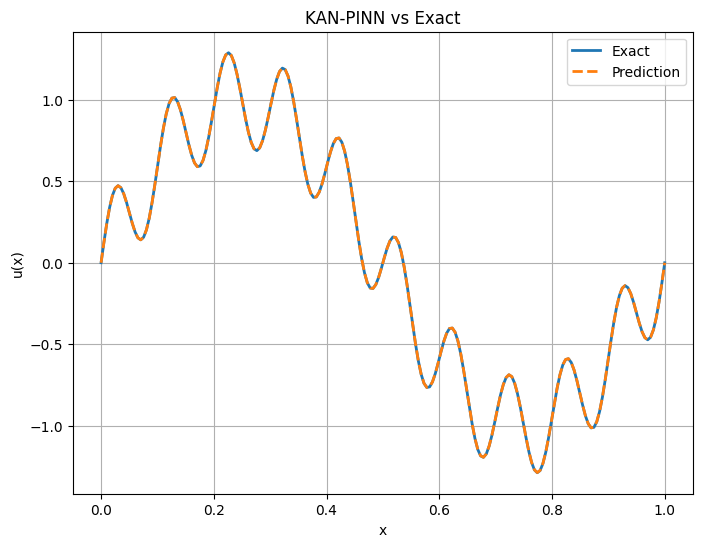

Relative Error = 7.595e-03
MSE = 1.546e-07


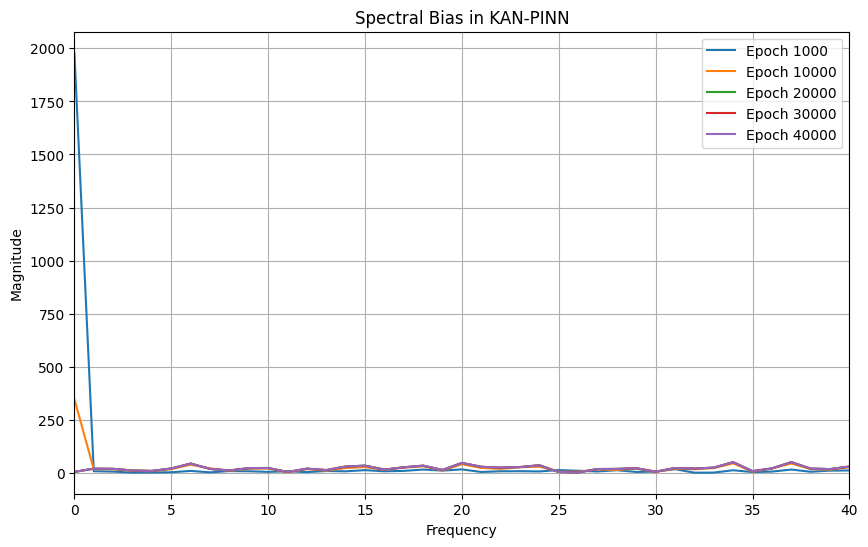

In [ ]:
# %% Import modules
import numpy as np
import jax
import jax.numpy as jnp
from jax import vjp, jit, grad
from jax.example_libraries import optimizers
from functools import partial
import time
import matplotlib.pyplot as plt

# %% Chebyshev helper functions
def chebyshev_recursive(x, degree):
    if degree == 0:
        return x * 0 + 1
    elif degree == 1:
        return x
    else:
        T_n_minus_1 = x
        T_n_minus_2 = x * 0 + 1
        for n in range(2, degree + 1):
            T_n = 2 * x * T_n_minus_1 - T_n_minus_2
            T_n_minus_2, T_n_minus_1 = T_n_minus_1, T_n
        return T_n

def chebyshev_cosine(x, degree):
    return jnp.cos(degree * jnp.arccos(x))

# %% KAN init
def init_params_kan2(layers, degree):
    keys = jax.random.split(jax.random.PRNGKey(123), len(layers) - 1)
    params = []
    for key, n_in, n_out in zip(keys[:-1], layers[:-2], layers[1:-1]):
        W = jax.random.normal(key, shape=(n_in, n_out, degree + 1)) / jnp.sqrt(n_in * (degree + 1))
        g = jax.random.normal(key, shape=(n_out,))
        params.append({'W': W, 'g': g})
    W = jax.random.normal(keys[-1], shape=(layers[-2], layers[-1])) / jnp.sqrt(layers[-2])
    B = jax.random.normal(keys[-1], shape=(layers[-1],))
    params.append({'W': W, 'B': B})
    return params

# %% KAN forward pass
# def fwd_kan(params, t, activation=jax.nn.tanh, use_cosine=False):
#     t = activation(t)
#     X = t.reshape((-1, 1))
#     *hidden, last = params
#     for layer in hidden:
#         W = layer['W']
#         degree = W.shape[-1] - 1
#         X_stack = jnp.stack([chebyshev_cosine(X, d) if use_cosine else chebyshev_recursive(X, d) for d in range(degree + 1)], axis=-1)
#         X = jnp.einsum("bid,iod->bo", X_stack, W)
#         # X = layer['g'] * X
#         X = activation(X)
#     return X @ last['W'] + last['B']
# %% KAN forward pass
def fwd_kan(params, t, activation=jax.nn.tanh, use_cosine=False):
    t = activation(t)
    X = t.reshape((-1, 1))
    *hidden, last = params
    for layer in hidden:
        W = layer['W']
        degree = W.shape[-1] - 1
        X_stack = jnp.stack([chebyshev_cosine(X, d) if use_cosine else chebyshev_recursive(X, d) for d in range(degree + 1)], axis=-1)
        X = jnp.einsum("bid,iod->bo", X_stack, W)
        X = layer['g'] * X
        X = activation(X)
    return X @ last['W'] + last['B']
# %% vgrad
def vgrad(f, x):
    y, vjp_fn = vjp(f, x)
    return vjp_fn(jnp.ones_like(y))[0]

# %% Target solution with multiple frequencies
# %% new ground truth and forcing term (low + high frequency)
def exact_solution(x):
    return jnp.sin(2 * jnp.pi * x) + 0.3 * jnp.sin(20 * jnp.pi * x)

def forcing_term(x):
    return -(2 * jnp.pi)**2 * jnp.sin(2 * jnp.pi * x) - (0.3 * (20 * jnp.pi)**2) * jnp.sin(20 * jnp.pi * x) - exact_solution(x)

# %% KAN-PINN Class
class PINN_KAN:
    def __init__(self, layers, degree, weight, activation=jax.nn.tanh, use_cosine=False):
        self.degree = degree
        self.activation = activation
        self.use_cosine = use_cosine
        self.weight_eqn, self.weight_bc = weight
        self.params = init_params_kan2(layers, degree)
        self.opt_init, self.opt_update, self.get_params = optimizers.adam(1e-5)
        self.opt_state = self.opt_init(self.params)

    @partial(jit, static_argnums=(0,))
    def equation(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        fu = lambda x: pinn(x)
        dudx = lambda x: vgrad(fu, x)
        d2udx2 = lambda x: vgrad(dudx, x)
        u = fu(X)
        u_xx = d2udx2(X)
        f = forcing_term(X)
        return u_xx - u - f

    @partial(jit, static_argnums=(0,))
    def forward(self, params, X):
        return fwd_kan(params, X, activation=self.activation, use_cosine=self.use_cosine)

    @partial(jit, static_argnums=(0,))
    def loss_component(self, params, X_res, X_bc):
        x_bc, y_bc = X_bc
        eq1 = self.equation(params, X_res)
        loss_res = jnp.mean(eq1 ** 2)
        x_bc_l, x_bc_r = x_bc
        u_l_pred = self.forward(params, x_bc_l)
        u_r_pred = self.forward(params, x_bc_r)
        u_l, u_r = y_bc
        loss_bc = jnp.mean((u_l - u_l_pred)**2 + (u_r - u_r_pred)**2)
        return 0.1*loss_res, loss_bc

    def loss(self, params, X_res, X_bc):
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return self.weight_eqn * loss_res + self.weight_bc * loss_bc

    @partial(jit, static_argnums=(0,))
    def update(self, i, opt_state, X_res, X_bc):
        params = self.get_params(opt_state)
        grads = grad(self.loss)(params, X_res, X_bc)
        opt_state = self.opt_update(i, grads, opt_state)
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return opt_state, (loss_res, loss_bc)

# %% Data prep
N = 1000
X = np.random.uniform(0, 1, size=(N,1))
X_res = jnp.array(X)

X_bc = (
    (jnp.array(0.0).reshape(-1, 1), jnp.array(1.0).reshape(-1, 1)),
    (jnp.array(0.0).reshape(-1, 1), jnp.array(0.0).reshape(-1, 1)),
)


# %% Train
layers = [1, 50, 50,50, 1]
degree = 5
model = PINN_KAN(layers, degree, weight=(1, 1))
N_epochs = 50000
Y_result = []
log_epochs = [1000, 10000, 20000, 30000, 40000]

for epoch in range(1, N_epochs + 1):
    model.opt_state, losses = model.update(epoch, model.opt_state, X_res, X_bc)
    model.params = model.get_params(model.opt_state)
    if epoch % 100 == 0:
        loss_res, loss_bc = losses
        print(f"Epoch: {epoch}, Loss_eqn = {loss_res:.3e}, Loss_bc = {loss_bc:.3e}")
    if epoch in log_epochs:
        Y_result.append(np.array(model.forward(model.params, X_res)))

# %% Plot solution
X_plot = np.linspace(0, 1, 200).reshape(-1, 1)
Y_pred_plot = model.forward(model.params, jnp.array(X_plot)).flatten()
Y_true_plot = exact_solution(jnp.array(X_plot)).flatten()

plt.figure(figsize=(8,6))
plt.plot(X_plot, Y_true_plot, label="Exact", linewidth=2)
plt.plot(X_plot, Y_pred_plot, '--', label="Prediction", linewidth=2)
plt.legend(), plt.grid(), plt.title("KAN-PINN vs Exact"), plt.xlabel("x"), plt.ylabel("u(x)")
plt.show()

# %% Error metrics
Y_true = exact_solution(X_res).flatten()
Y_pred = model.forward(model.params, X_res).flatten()
rel_err = np.mean((Y_pred - Y_true)**2) / (np.mean(Y_true)**2)
mse = np.mean((Y_pred - Y_true)**2)
print(f"Relative Error = {rel_err:.3e}")
print(f"MSE = {mse:.3e}")

# %% FFT Spectral Bias
def compute_fourier_spectrum(signal, dx):
    n = len(signal)
    freqs = np.fft.fftfreq(n, d=dx)
    mag = np.abs(np.fft.fft(signal))
    return freqs[:n//2], mag[:n//2]

plt.figure(figsize=(10,6))
dx = 1 / len(X_res)
for i, (y, ep) in enumerate(zip(Y_result, log_epochs)):
    freqs, mag = compute_fourier_spectrum(np.array(y).flatten(), dx)
    plt.plot(freqs, mag, label=f"Epoch {ep}")
plt.xlim(0, 40)
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.title("Spectral Bias in KAN-PINN")
plt.legend()
plt.grid(True)
plt.show()


Epoch: 100, Loss_eqn = 6.083e+04, Loss_bc = 1.739e+01
Epoch: 200, Loss_eqn = 5.335e+04, Loss_bc = 1.645e+01
Epoch: 300, Loss_eqn = 4.568e+04, Loss_bc = 1.548e+01
Epoch: 400, Loss_eqn = 3.819e+04, Loss_bc = 1.584e+01
Epoch: 500, Loss_eqn = 3.108e+04, Loss_bc = 1.627e+01
Epoch: 600, Loss_eqn = 2.474e+04, Loss_bc = 1.670e+01
Epoch: 700, Loss_eqn = 1.953e+04, Loss_bc = 1.706e+01
Epoch: 800, Loss_eqn = 1.564e+04, Loss_bc = 1.722e+01
Epoch: 900, Loss_eqn = 1.296e+04, Loss_bc = 1.701e+01
Epoch: 1000, Loss_eqn = 1.112e+04, Loss_bc = 1.645e+01
Epoch: 1100, Loss_eqn = 9.663e+03, Loss_bc = 1.569e+01
Epoch: 1200, Loss_eqn = 8.137e+03, Loss_bc = 1.467e+01
Epoch: 1300, Loss_eqn = 6.404e+03, Loss_bc = 1.367e+01
Epoch: 1400, Loss_eqn = 4.732e+03, Loss_bc = 1.317e+01
Epoch: 1500, Loss_eqn = 3.246e+03, Loss_bc = 1.279e+01
Epoch: 1600, Loss_eqn = 2.080e+03, Loss_bc = 1.259e+01
Epoch: 1700, Loss_eqn = 1.284e+03, Loss_bc = 1.261e+01
Epoch: 1800, Loss_eqn = 8.049e+02, Loss_bc = 1.288e+01
Epoch: 1900, Loss_e

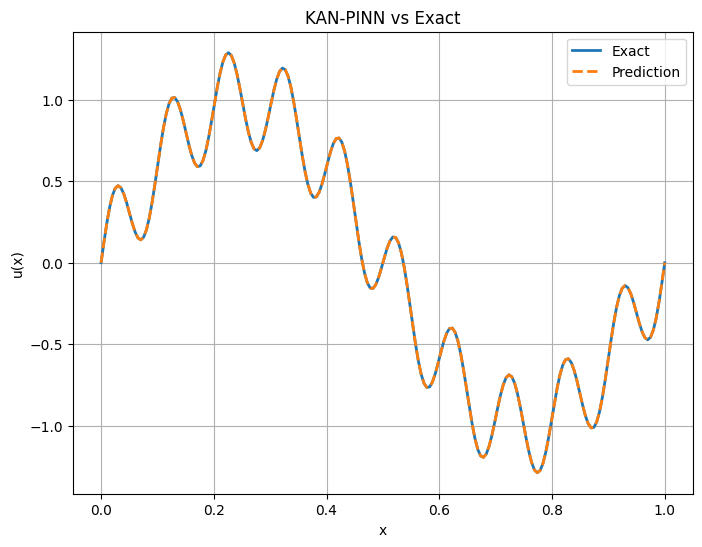

Relative Error = 1.193e-03
MSE = 2.027e-08


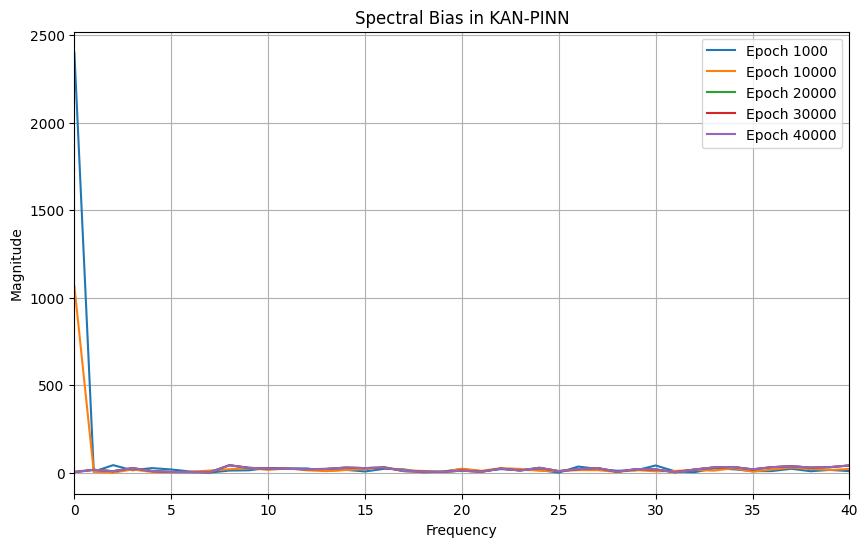

In [ ]:
# %% Import modules
import numpy as np
import jax
import jax.numpy as jnp
from jax import vjp, jit, grad
from jax.example_libraries import optimizers
from functools import partial
import time
import matplotlib.pyplot as plt

# %% Chebyshev helper functions
def chebyshev_recursive(x, degree):
    if degree == 0:
        return x * 0 + 1
    elif degree == 1:
        return x
    else:
        T_n_minus_1 = x
        T_n_minus_2 = x * 0 + 1
        for n in range(2, degree + 1):
            T_n = 2 * x * T_n_minus_1 - T_n_minus_2
            T_n_minus_2, T_n_minus_1 = T_n_minus_1, T_n
        return T_n

def chebyshev_cosine(x, degree):
    return jnp.cos(degree * jnp.arccos(x))

# %% KAN init
def init_params_kan2(layers, degree):
    keys = jax.random.split(jax.random.PRNGKey(123), len(layers) - 1)
    params = []
    for key, n_in, n_out in zip(keys[:-1], layers[:-2], layers[1:-1]):
        W = jax.random.normal(key, shape=(n_in, n_out, degree + 1)) / jnp.sqrt(n_in * (degree + 1))
        g = jax.random.normal(key, shape=(n_out,))
        params.append({'W': W, 'g': g})
    W = jax.random.normal(keys[-1], shape=(layers[-2], layers[-1])) / jnp.sqrt(layers[-2])
    B = jax.random.normal(keys[-1], shape=(layers[-1],))
    params.append({'W': W, 'B': B})
    return params

# %% KAN forward pass
# def fwd_kan(params, t, activation=jax.nn.tanh, use_cosine=False):
#     t = activation(t)
#     X = t.reshape((-1, 1))
#     *hidden, last = params
#     for layer in hidden:
#         W = layer['W']
#         degree = W.shape[-1] - 1
#         X_stack = jnp.stack([chebyshev_cosine(X, d) if use_cosine else chebyshev_recursive(X, d) for d in range(degree + 1)], axis=-1)
#         X = jnp.einsum("bid,iod->bo", X_stack, W)
#         # X = layer['g'] * X
#         X = activation(X)
#     return X @ last['W'] + last['B']
# %% KAN forward pass
def fwd_kan(params, t, activation=jax.nn.tanh, use_cosine=False):
    # t = activation(t)
    X = t.reshape((-1, 1))
    *hidden, last = params
    for layer in hidden:
        X = activation(X)
        W = layer['W']
        degree = W.shape[-1] - 1
        X_stack = jnp.stack([chebyshev_cosine(X, d) if use_cosine else chebyshev_recursive(X, d) for d in range(degree + 1)], axis=-1)
        X = jnp.einsum("bid,iod->bo", X_stack, W)
        # X = layer['g'] * X
        X = activation(X)
    return X @ last['W'] + last['B']
# %% vgrad
def vgrad(f, x):
    y, vjp_fn = vjp(f, x)
    return vjp_fn(jnp.ones_like(y))[0]

# %% Target solution with multiple frequencies
# %% new ground truth and forcing term (low + high frequency)
def exact_solution(x):
    return jnp.sin(2 * jnp.pi * x) + 0.3 * jnp.sin(20 * jnp.pi * x)

def forcing_term(x):
    return -(2 * jnp.pi)**2 * jnp.sin(2 * jnp.pi * x) - (0.3 * (20 * jnp.pi)**2) * jnp.sin(20 * jnp.pi * x) - exact_solution(x)

# %% KAN-PINN Class
class PINN_KAN:
    def __init__(self, layers, degree, weight, activation=jax.nn.tanh, use_cosine=False):
        self.degree = degree
        self.activation = activation
        self.use_cosine = use_cosine
        self.weight_eqn, self.weight_bc = weight
        self.params = init_params_kan2(layers, degree)
        self.opt_init, self.opt_update, self.get_params = optimizers.adam(1e-5)
        self.opt_state = self.opt_init(self.params)

    @partial(jit, static_argnums=(0,))
    def equation(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        fu = lambda x: pinn(x)
        dudx = lambda x: vgrad(fu, x)
        d2udx2 = lambda x: vgrad(dudx, x)
        u = fu(X)
        u_xx = d2udx2(X)
        f = forcing_term(X)
        return u_xx - u - f

    @partial(jit, static_argnums=(0,))
    def forward(self, params, X):
        return fwd_kan(params, X, activation=self.activation, use_cosine=self.use_cosine)

    @partial(jit, static_argnums=(0,))
    def loss_component(self, params, X_res, X_bc):
        x_bc, y_bc = X_bc
        eq1 = self.equation(params, X_res)
        loss_res = jnp.mean(eq1 ** 2)
        x_bc_l, x_bc_r = x_bc
        u_l_pred = self.forward(params, x_bc_l)
        u_r_pred = self.forward(params, x_bc_r)
        u_l, u_r = y_bc
        loss_bc = jnp.mean((u_l - u_l_pred)**2 + (u_r - u_r_pred)**2)
        return 0.1*loss_res, loss_bc

    def loss(self, params, X_res, X_bc):
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return self.weight_eqn * loss_res + self.weight_bc * loss_bc

    @partial(jit, static_argnums=(0,))
    def update(self, i, opt_state, X_res, X_bc):
        params = self.get_params(opt_state)
        grads = grad(self.loss)(params, X_res, X_bc)
        opt_state = self.opt_update(i, grads, opt_state)
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return opt_state, (loss_res, loss_bc)

# %% Data prep
N = 1000
X = np.random.uniform(0, 1, size=(N,1))
X_res = jnp.array(X)

X_bc = (
    (jnp.array(0.0).reshape(-1, 1), jnp.array(1.0).reshape(-1, 1)),
    (jnp.array(0.0).reshape(-1, 1), jnp.array(0.0).reshape(-1, 1)),
)


# %% Train
layers = [1, 50, 50,50, 1]
degree = 5
model = PINN_KAN(layers, degree, weight=(1, 1))
N_epochs = 50000
Y_result = []
log_epochs = [1000, 10000, 20000, 30000, 40000]

for epoch in range(1, N_epochs + 1):
    model.opt_state, losses = model.update(epoch, model.opt_state, X_res, X_bc)
    model.params = model.get_params(model.opt_state)
    if epoch % 100 == 0:
        loss_res, loss_bc = losses
        print(f"Epoch: {epoch}, Loss_eqn = {loss_res:.3e}, Loss_bc = {loss_bc:.3e}")
    if epoch in log_epochs:
        Y_result.append(np.array(model.forward(model.params, X_res)))


# %% Plot solution
X_plot = np.linspace(0, 1, 200).reshape(-1, 1)
Y_pred_plot = model.forward(model.params, jnp.array(X_plot)).flatten()
Y_true_plot = exact_solution(jnp.array(X_plot)).flatten()

plt.figure(figsize=(8,6))
plt.plot(X_plot, Y_true_plot, label="Exact", linewidth=2)
plt.plot(X_plot, Y_pred_plot, '--', label="Prediction", linewidth=2)
plt.legend(), plt.grid(), plt.title("KAN-PINN vs Exact"), plt.xlabel("x"), plt.ylabel("u(x)")
plt.show()

# %% Error metrics
Y_true = exact_solution(X_res).flatten()
Y_pred = model.forward(model.params, X_res).flatten()
rel_err = np.mean((Y_pred - Y_true)**2) / (np.mean(Y_true)**2)
mse = np.mean((Y_pred - Y_true)**2)
print(f"Relative Error = {rel_err:.3e}")
print(f"MSE = {mse:.3e}")

# %% FFT Spectral Bias
def compute_fourier_spectrum(signal, dx):
    n = len(signal)
    freqs = np.fft.fftfreq(n, d=dx)
    mag = np.abs(np.fft.fft(signal))
    return freqs[:n//2], mag[:n//2]

plt.figure(figsize=(10,6))
dx = 1 / len(X_res)
for i, (y, ep) in enumerate(zip(Y_result, log_epochs)):
    freqs, mag = compute_fourier_spectrum(np.array(y).flatten(), dx)
    plt.plot(freqs, mag, label=f"Epoch {ep}")
plt.xlim(0, 40)
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.title("Spectral Bias in KAN-PINN")
plt.legend()
plt.grid(True)
plt.show()


#correct spectral bia

In [ ]:
# %% Import modules
import numpy as np
import jax
import jax.numpy as jnp
from jax import vjp, jit, grad
from jax.example_libraries import optimizers
from functools import partial
import matplotlib.pyplot as plt

# %% Chebyshev helper functions
def chebyshev_recursive(x, degree):
    if degree == 0:
        return x * 0 + 1
    elif degree == 1:
        return x
    else:
        T_n_minus_1 = x
        T_n_minus_2 = x * 0 + 1
        for _ in range(2, degree + 1):
            T_n = 2 * x * T_n_minus_1 - T_n_minus_2
            T_n_minus_2, T_n_minus_1 = T_n_minus_1, T_n
        return T_n

def chebyshev_cosine(x, degree):
    return jnp.cos(degree * jnp.arccos(x))

# %% KAN init
def init_params_kan2(layers, degree):
    keys = jax.random.split(jax.random.PRNGKey(123), len(layers) - 1)
    params = []
    # hidden Chebyshev layers
    for key, n_in, n_out in zip(keys[:-1], layers[:-2], layers[1:-1]):
        W = jax.random.normal(key, (n_in, n_out, degree+1)) / jnp.sqrt(n_in*(degree+1))
        g = jax.random.normal(key, (n_out,))
        params.append({'W': W, 'g': g})
    # final linear layer
    Wf = jax.random.normal(keys[-1], (layers[-2], layers[-1])) / jnp.sqrt(layers[-2])
    Bf = jax.random.normal(keys[-1], (layers[-1],))
    params.append({'W': Wf, 'B': Bf})
    return params

# %% KAN forward pass
def fwd_kan(params, t, activation=jax.nn.tanh, use_cosine=False):
    X = t.reshape((-1, 1))
    *hidden, last = params
    for layer in hidden:
        X = activation(X)
        W = layer['W']
        deg = W.shape[-1] - 1
        X_stack = jnp.stack([
            chebyshev_cosine(X, d) if use_cosine else chebyshev_recursive(X, d)
            for d in range(deg+1)
        ], axis=-1)
        X = jnp.einsum("bid,iod->bo", X_stack, W)
        # (optional) X = layer['g'] * X
        X = activation(X)
    return X @ last['W'] + last['B']

# %% vjp-based gradient
def vgrad(f, x):
    y, vjp_fn = vjp(f, x)
    return vjp_fn(jnp.ones_like(y))[0]

# %% exact solution + forcing
def exact_solution(x):
    return jnp.sin(2*jnp.pi*x) + 0.3*jnp.sin(20*jnp.pi*x)

def forcing_term(x):
    return (-(2*jnp.pi)**2 * jnp.sin(2*jnp.pi*x)
            - 0.3*(20*jnp.pi)**2 * jnp.sin(20*jnp.pi*x)
            - exact_solution(x))

# %% PINN-KAN class
class PINN_KAN:
    def __init__(self, layers, degree, weight=(1,1), activation=jax.nn.tanh, use_cosine=False):
        self.degree = degree
        self.activation = activation
        self.use_cosine = use_cosine
        self.weight_eqn, self.weight_bc = weight
        self.params = init_params_kan2(layers, degree)
        self.opt_init, self.opt_update, self.get_params = optimizers.adam(1e-5)
        self.opt_state = self.opt_init(self.params)

    @partial(jit, static_argnums=0)
    def equation(self, params, X):
        pinn = lambda x: fwd_kan(params, x, activation=self.activation, use_cosine=self.use_cosine)
        dudx = lambda x: vgrad(pinn, x)
        d2udx2 = lambda x: vgrad(dudx, x)
        u = pinn(X)
        u_xx = d2udx2(X)
        return u_xx - u - forcing_term(X)

    @partial(jit, static_argnums=0)
    def forward(self, params, X):
        return fwd_kan(params, X, activation=self.activation, use_cosine=self.use_cosine)

    @partial(jit, static_argnums=0)
    def loss_component(self, params, X_res, X_bc):
        (x_bc, y_bc) = X_bc
        loss_res = jnp.mean(self.equation(params, X_res)**2)
        u_pred_l = self.forward(params, x_bc[0])
        u_pred_r = self.forward(params, x_bc[1])
        loss_bc  = jnp.mean((y_bc[0] - u_pred_l)**2 + (y_bc[1] - u_pred_r)**2)
        return loss_res, loss_bc

    def loss(self, params, X_res, X_bc):
        lr, lbc = self.loss_component(params, X_res, X_bc)
        return self.weight_eqn*lr + self.weight_bc*lbc

    @partial(jit, static_argnums=0)
    def update(self, i, opt_state, X_res, X_bc):
        params = self.get_params(opt_state)
        grads  = grad(self.loss)(params, X_res, X_bc)
        new_opt = self.opt_update(i, grads, opt_state)
        return new_opt

# %% Training & Logging
# 1) training collocation points (random)
N_train = 1000
X_res = jnp.array(np.random.rand(N_train,1))

# 2) BC
X_bc = ((jnp.array([[0.0]]), jnp.array([[1.0]])),
        (jnp.array([[1.0]]), jnp.array([[0.0]])))

# 3) spectral‐analysis grid (evenly spaced)
N_spec = 1000
X_spec = np.linspace(0,1,N_spec).reshape(-1,1)
X_spec_jax = jnp.array(X_spec)

# initialize model
layers = [1, 50, 50, 50, 1]
degree = 5
model  = PINN_KAN(layers, degree, weight=(1,1))
epochs = 50000
log_epochs = [1000, 10000, 20000, 30000, 40000]
Y_logs = []


for ep in range(1, epochs+1):
    model.opt_state = model.update(ep, model.opt_state, X_res, X_bc)
    if ep in log_epochs:
        params = model.get_params(model.opt_state)
        Y_pred_spec = np.array(model.forward(params, X_spec_jax)).flatten()
        Y_logs.append((ep, Y_pred_spec))

# %% Plot PINN vs exact on a test grid
X_plot = np.linspace(0,1,200).reshape(-1,1)
Y_true = exact_solution(jnp.array(X_plot)).flatten()
params   = model.get_params(model.opt_state)
Y_pred = model.forward(params, jnp.array(X_plot)).flatten()

plt.figure(figsize=(8,6))
plt.plot(X_plot, Y_true, label="Exact", linewidth=2)
plt.plot(X_plot, np.array(Y_pred), '--', label="PINN", linewidth=2)
plt.legend(); plt.grid(True)
plt.title("KAN-PINN vs Exact")
plt.xlabel("x"); plt.ylabel("u(x)")
plt.show()

# %% Compute and plot spectral content
plt.figure(figsize=(10,6))

# common dx and freq axis
dx = X_spec[1,0] - X_spec[0,0]
freqs = np.fft.rfftfreq(N_spec, d=dx)

for ep, y in Y_logs:
    # detrend
    y_d = y - np.mean(y)
    mag = np.abs(np.fft.rfft(y_d))
    plt.plot(freqs, mag, label=f"Epoch {ep}")

plt.xlim(0,40)
plt.xlabel("Frequency (cycles per unit x)")
plt.ylabel("Magnitude")
plt.title("Spectral Bias Over Training")
plt.legend(); plt.grid(True)
plt.show()


KeyboardInterrupt: 

In [ ]:
# %% Import modules
import numpy as np
import jax
import jax.numpy as jnp
from jax import vjp, jit, grad
from jax.example_libraries import optimizers
from functools import partial
import time
import matplotlib.pyplot as plt

# %% Chebyshev helper functions
def chebyshev_recursive(x, degree):
    if degree == 0:
        return x * 0 + 1
    elif degree == 1:
        return x
    else:
        T_n_minus_1 = x
        T_n_minus_2 = x * 0 + 1
        for n in range(2, degree + 1):
            T_n = 2 * x * T_n_minus_1 - T_n_minus_2
            T_n_minus_2, T_n_minus_1 = T_n_minus_1, T_n
        return T_n

def chebyshev_cosine(x, degree):
    return jnp.cos(degree * jnp.arccos(x))

# %% KAN init
def init_params_kan2(layers, degree):
    keys = jax.random.split(jax.random.PRNGKey(123), len(layers) - 1)
    params = []
    for key, n_in, n_out in zip(keys[:-1], layers[:-2], layers[1:-1]):
        W = jax.random.normal(key, shape=(n_in, n_out, degree + 1)) / jnp.sqrt(n_in * (degree + 1))
        g = jax.random.normal(key, shape=(n_out,))
        params.append({'W': W, 'g': g})
    W = jax.random.normal(keys[-1], shape=(layers[-2], layers[-1])) / jnp.sqrt(layers[-2])
    B = jax.random.normal(keys[-1], shape=(layers[-1],))
    params.append({'W': W, 'B': B})
    return params

# %% KAN forward pass
# def fwd_kan(params, t, activation=jax.nn.tanh, use_cosine=False):
#     t = activation(t)
#     X = t.reshape((-1, 1))
#     *hidden, last = params
#     for layer in hidden:
#         W = layer['W']
#         degree = W.shape[-1] - 1
#         X_stack = jnp.stack([chebyshev_cosine(X, d) if use_cosine else chebyshev_recursive(X, d) for d in range(degree + 1)], axis=-1)
#         X = jnp.einsum("bid,iod->bo", X_stack, W)
#         # X = layer['g'] * X
#         X = activation(X)
#     return X @ last['W'] + last['B']
# %% KAN forward pass
def fwd_kan(params, t, activation=jax.nn.tanh, use_cosine=False):
    # t = activation(t)
    X = t.reshape((-1, 1))
    *hidden, last = params
    for layer in hidden:
        X = activation(X)
        W = layer['W']
        degree = W.shape[-1] - 1
        X_stack = jnp.stack([chebyshev_cosine(X, d) if use_cosine else chebyshev_recursive(X, d) for d in range(degree + 1)], axis=-1)
        X = jnp.einsum("bid,iod->bo", X_stack, W)
        # X = layer['g'] * X
        X = activation(X)
    return X @ last['W'] + last['B']
# %% vgrad
def vgrad(f, x):
    y, vjp_fn = vjp(f, x)
    return vjp_fn(jnp.ones_like(y))[0]

# %% Target solution with multiple frequencies
# %% new ground truth and forcing term (low + high frequency)
def exact_solution(x):
    return jnp.sin(2 * jnp.pi * x) + 0.3 * jnp.sin(20 * jnp.pi * x)

def forcing_term(x):
    return -(2 * jnp.pi)**2 * jnp.sin(2 * jnp.pi * x) - (0.3 * (20 * jnp.pi)**2) * jnp.sin(20 * jnp.pi * x) - exact_solution(x)

# %% KAN-PINN Class
class PINN_KAN:
    def __init__(self, layers, degree, weight, activation=jax.nn.tanh, use_cosine=False):
        self.degree = degree
        self.activation = activation
        self.use_cosine = use_cosine
        self.weight_eqn, self.weight_bc = weight
        self.params = init_params_kan2(layers, degree)
        self.opt_init, self.opt_update, self.get_params = optimizers.adam(1e-5)
        self.opt_state = self.opt_init(self.params)

    @partial(jit, static_argnums=(0,))
    def equation(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        fu = lambda x: pinn(x)
        dudx = lambda x: vgrad(fu, x)
        d2udx2 = lambda x: vgrad(dudx, x)
        u = fu(X)
        u_xx = d2udx2(X)
        f = forcing_term(X)
        return u_xx - u - f

    @partial(jit, static_argnums=(0,))
    def forward(self, params, X):
        return fwd_kan(params, X, activation=self.activation, use_cosine=self.use_cosine)

    @partial(jit, static_argnums=(0,))
    def loss_component(self, params, X_res, X_bc):
        x_bc, y_bc = X_bc
        eq1 = self.equation(params, X_res)
        loss_res = jnp.mean(eq1 ** 2)
        x_bc_l, x_bc_r = x_bc
        u_l_pred = self.forward(params, x_bc_l)
        u_r_pred = self.forward(params, x_bc_r)
        u_l, u_r = y_bc
        loss_bc = jnp.mean((u_l - u_l_pred)**2 + (u_r - u_r_pred)**2)
        return 0.1*loss_res, loss_bc

    def loss(self, params, X_res, X_bc):
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return self.weight_eqn * loss_res + self.weight_bc * loss_bc

    @partial(jit, static_argnums=(0,))
    def update(self, i, opt_state, X_res, X_bc):
        params = self.get_params(opt_state)
        grads = grad(self.loss)(params, X_res, X_bc)
        opt_state = self.opt_update(i, grads, opt_state)
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return opt_state, (loss_res, loss_bc)

# %% Data prep
N = 1000
X = np.random.uniform(0, 1, size=(N,1))
X_res = jnp.array(X)

X_bc = (
    (jnp.array(0.0).reshape(-1, 1), jnp.array(1.0).reshape(-1, 1)),
    (jnp.array(0.0).reshape(-1, 1), jnp.array(0.0).reshape(-1, 1)),
)


# %% Train
layers = [1, 50, 50,50, 1]
degree = 5
model = PINN_KAN(layers, degree, weight=(1, 1))
N_epochs = 50000
Y_result = []
log_epochs = [1000, 10000, 20000, 30000, 40000]

for epoch in range(1, N_epochs + 1):
    model.opt_state, losses = model.update(epoch, model.opt_state, X_res, X_bc)
    model.params = model.get_params(model.opt_state)
    if epoch % 100 == 0:
        loss_res, loss_bc = losses
        print(f"Epoch: {epoch}, Loss_eqn = {loss_res:.3e}, Loss_bc = {loss_bc:.3e}")
    if epoch in log_epochs:
        Y_result.append(np.array(model.forward(model.params, X_res)))

# %% Plot solution
X_plot = np.linspace(0, 1, 200).reshape(-1, 1)
Y_pred_plot = model.forward(model.params, jnp.array(X_plot)).flatten()
Y_true_plot = exact_solution(jnp.array(X_plot)).flatten()

plt.figure(figsize=(8,6))
plt.plot(X_plot, Y_true_plot, label="Exact", linewidth=2)
plt.plot(X_plot, Y_pred_plot, '--', label="Prediction", linewidth=2)
plt.legend(), plt.grid(), plt.title("KAN-PINN vs Exact"), plt.xlabel("x"), plt.ylabel("u(x)")
plt.show()

# %% Error metrics
Y_true = exact_solution(X_res).flatten()
Y_pred = model.forward(model.params, X_res).flatten()
rel_err = np.mean((Y_pred - Y_true)**2) / (np.mean(Y_true)**2)
mse = np.mean((Y_pred - Y_true)**2)
print(f"Relative Error = {rel_err:.3e}")
print(f"MSE = {mse:.3e}")

# %% FFT Spectral Bias
def compute_fourier_spectrum(signal, dx):
    n = len(signal)
    freqs = np.fft.fftfreq(n, d=dx)
    mag = np.abs(np.fft.fft(signal))
    return freqs[:n//2], mag[:n//2]

plt.figure(figsize=(10,6))
dx = 1 / len(X_res)
for i, (y, ep) in enumerate(zip(Y_result, log_epochs)):
    freqs, mag = compute_fourier_spectrum(np.array(y).flatten(), dx)
    plt.plot(freqs, mag, label=f"Epoch {ep}")
plt.xlim(0, 40)
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.title("Spectral Bias in KAN-PINN")
plt.legend()
plt.grid(True)
plt.show()


Epoch: 100, Time: 0.00s, Loss_eqn=3.196e+05, Loss_bc=1.240e+00
Epoch: 200, Time: 0.00s, Loss_eqn=1.675e+05, Loss_bc=1.313e+00
Epoch: 300, Time: 0.00s, Loss_eqn=8.983e+04, Loss_bc=1.569e+00
Epoch: 400, Time: 0.00s, Loss_eqn=4.544e+04, Loss_bc=1.042e+00
Epoch: 500, Time: 0.00s, Loss_eqn=1.740e+04, Loss_bc=5.992e-01
Epoch: 600, Time: 0.00s, Loss_eqn=4.460e+03, Loss_bc=4.401e-01
Epoch: 700, Time: 0.00s, Loss_eqn=1.227e+03, Loss_bc=3.977e-01
Epoch: 800, Time: 0.00s, Loss_eqn=5.907e+02, Loss_bc=3.965e-01
Epoch: 900, Time: 0.00s, Loss_eqn=3.773e+02, Loss_bc=4.183e-01
Epoch: 1000, Time: 0.00s, Loss_eqn=2.605e+02, Loss_bc=4.643e-01
Epoch: 1100, Time: 0.00s, Loss_eqn=1.916e+02, Loss_bc=5.168e-01
Epoch: 1200, Time: 0.00s, Loss_eqn=1.487e+02, Loss_bc=5.667e-01
Epoch: 1300, Time: 0.00s, Loss_eqn=1.201e+02, Loss_bc=6.110e-01
Epoch: 1400, Time: 0.00s, Loss_eqn=9.937e+01, Loss_bc=6.494e-01
Epoch: 1500, Time: 0.00s, Loss_eqn=8.340e+01, Loss_bc=6.830e-01
Epoch: 1600, Time: 0.00s, Loss_eqn=7.072e+01, Los

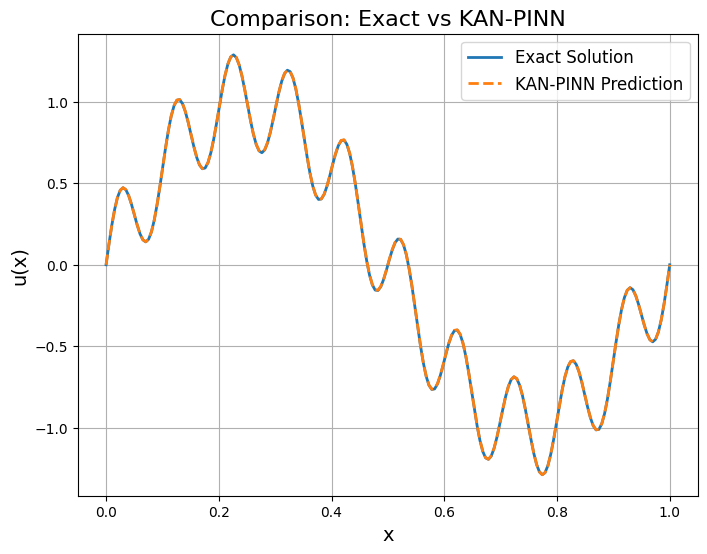

Relative error(MAE) = 1.126e-01.
MSE = 1.112e-06.


In [ ]:
# %% Import modules
import numpy as np
import jax
import jax.numpy as jnp
from jax import vjp, jit, grad
from jax.example_libraries import optimizers
from functools import partial
import time
import matplotlib.pyplot as plt

# %% Chebyshev helper functions
def chebyshev_recursive(x, degree):
    if degree == 0:
        return x * 0 + 1
    elif degree == 1:
        return x
    else:
        T_n_minus_1 = x
        T_n_minus_2 = x * 0 + 1
        for n in range(2, degree + 1):
            T_n = 2 * x * T_n_minus_1 - T_n_minus_2
            T_n_minus_2, T_n_minus_1 = T_n_minus_1, T_n
        return T_n

def chebyshev_cosine(x, degree):
    return jnp.cos(degree * jnp.arccos(x))

# %% KAN initialization
def init_params_kan2(layers, degree):
    keys = jax.random.split(jax.random.PRNGKey(123), len(layers) - 1)
    params = []
    for key, n_in, n_out in zip(keys[:-1], layers[:-2], layers[1:-1]):
        W = jax.random.normal(key, shape=(n_in, n_out, degree + 1)) / jnp.sqrt(n_in * (degree + 1))
        g = jax.random.normal(key, shape=(n_out,))
        params.append({'W': W, 'g': g})
    W = jax.random.normal(keys[-1], shape=(layers[-2], layers[-1])) / jnp.sqrt(layers[-2])
    B = jax.random.normal(keys[-1], shape=(layers[-1],))
    params.append({'W': W, 'B': B})
    return params

# %% KAN forward pass
def fwd_kan(params, t, activation=jax.nn.tanh, use_cosine=False):
    # t = 0.01 * t
    t = activation(t)
    X = t.reshape((-1, 1))
    *hidden, last = params
    for layer in hidden:
        cheby_coeffs = layer['W']
        degree = cheby_coeffs.shape[2] - 1
        if use_cosine:
            X_stack = jnp.stack([chebyshev_cosine(X, d) for d in range(degree + 1)], axis=-1)
        else:
            X_stack = jnp.stack([chebyshev_recursive(X, d) for d in range(degree + 1)], axis=-1)
        X = jnp.einsum("bid,iod->bo", X_stack, cheby_coeffs)
        X = layer['g'] * X
        X = activation(X)
    return X @ last['W'] + last['B']

# %% helper functions
def vgrad(f, x):
    y, vjp_fn = vjp(f, x)
    return vjp_fn(jnp.ones(y.shape))[0]

# Ground truth and forcing term
# def exact_solution(x):
#     return jnp.sin(9 * jnp.pi / 2 * x)

# def forcing_term(x):
#     coef = -(9 * jnp.pi / 2) ** 2 - 1
#     return coef * jnp.sin(9 * jnp.pi / 2 * x)
def exact_solution(x):
    return jnp.sin(2 * jnp.pi * x) + 0.3 * jnp.sin(20 * jnp.pi * x)

def forcing_term(x):
    return -(2 * jnp.pi)**2 * jnp.sin(2 * jnp.pi * x) - (0.3 * (20 * jnp.pi)**2) * jnp.sin(20 * jnp.pi * x) - exact_solution(x)

# %% Define KAN-based PINN model
class PINN_KAN:
    def __init__(self, layers, degree, weight, activation=jax.nn.tanh, use_cosine=False):
        self.degree = degree
        self.activation = activation
        self.use_cosine = use_cosine
        self.weight_eqn, self.weight_bc = weight
        self.params = init_params_kan2(layers, degree)
        self.opt_init, self.opt_update, self.get_params = optimizers.adam(1e-4)
        self.opt_state = self.opt_init(self.params)

    @partial(jit, static_argnums=(0,))
    def equation(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        fu = lambda x: pinn(x)
        dudx = lambda x: vgrad(fu, x)
        d2udx2 = lambda x: vgrad(dudx, x)
        u = fu(X)
        u_xx = d2udx2(X)
        f = forcing_term(X)
        return u_xx - u - f

    @partial(jit, static_argnums=(0,))
    def forward(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        return pinn(X)

    @partial(jit, static_argnums=(0,))
    def loss_component(self, params, X_res, X_bc):
        x_bc, y_bc = X_bc
        eq1 = self.equation(params, X_res)
        loss_res = jnp.mean(eq1 ** 2)
        x_bc_l, x_bc_r = x_bc
        u_l_pred = self.forward(params, x_bc_l)
        u_r_pred = self.forward(params, x_bc_r)
        u_l, u_r = y_bc
        loss_bc = jnp.mean((u_l - u_l_pred) ** 2 + (u_r - u_r_pred) ** 2)
        return loss_res, loss_bc

    def loss(self, params, X_res, X_bc):
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return self.weight_eqn * loss_res + self.weight_bc * loss_bc

    @partial(jit, static_argnums=(0,))
    def update(self, i, opt_state, X_res, X_bc):
        params = self.get_params(opt_state)
        next_opt_state = self.opt_update(i, grad(self.loss)(params, X_res, X_bc), opt_state)
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return next_opt_state, (loss_res, loss_bc)

# %% prepare data
N = 1000
X = np.random.uniform(0, 1, size=(N,1))
X_res = jnp.array(X)

X_bc = (
    (jnp.array(0.0).reshape(-1, 1), jnp.array(1.0).reshape(-1, 1)),
    (jnp.array(0.0).reshape(-1, 1), jnp.array(0.0).reshape(-1, 1)),
)


# %% training
layers = [1, 50, 50, 1]
degree = 7
model = PINN_KAN(layers, degree, weight=(1,1))
N_epochs = 40000
Y_result = []

for epoch in range(1, N_epochs+1):
    start = time.time()
    model.opt_state, losses = model.update(epoch, model.opt_state, X_res, X_bc)
    model.params = model.get_params(model.opt_state)
    end = time.time()
    if epoch % 100 == 0:
        loss_res, loss_bc = losses
        print(f"Epoch: {epoch}, Time: {end-start:.2f}s, Loss_eqn={loss_res:.3e}, Loss_bc={loss_bc:.3e}")
        Y = model.forward(model.params, X_res)
        Y_result.append(Y)

# %% Compare and plot
X_plot = np.linspace(0, 1, 200).reshape(-1, 1)
X_plot_jax = jnp.array(X_plot)

Y_pred_plot = model.forward(model.params, X_plot_jax).flatten()
Y_true_plot = exact_solution(X_plot_jax).flatten()

plt.figure(figsize=(8,6))
plt.plot(X_plot, Y_true_plot, label="Exact Solution", linewidth=2)
plt.plot(X_plot, Y_pred_plot, '--', label="KAN-PINN Prediction", linewidth=2)
plt.xlabel('x', fontsize=14)
plt.ylabel('u(x)', fontsize=14)
plt.title('Comparison: Exact vs KAN-PINN', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# %% Relative error
Y_true = exact_solution(X_res).flatten()
Y_pred = Y_result[-1].flatten()
err = np.mean((Y_pred - Y_true)**2) / (np.mean(Y_true)**2)
print(f"Relative error(MAE) = {err:.3e}.")

err = np.mean((Y_pred - Y_true)**2)# / (np.mean(Y_true)**2)
print(f"MSE = {err:.3e}.")


Epoch: 100, Time: 0.00s, Loss_eqn=1.559e+04, Loss_bc=9.486e+00
Epoch: 200, Time: 0.00s, Loss_eqn=8.549e+03, Loss_bc=8.570e+00
Epoch: 300, Time: 0.00s, Loss_eqn=4.655e+03, Loss_bc=7.702e+00
Epoch: 400, Time: 0.00s, Loss_eqn=2.797e+03, Loss_bc=7.163e+00
Epoch: 500, Time: 0.00s, Loss_eqn=1.924e+03, Loss_bc=7.272e+00
Epoch: 600, Time: 0.00s, Loss_eqn=1.426e+03, Loss_bc=8.093e+00
Epoch: 700, Time: 0.00s, Loss_eqn=1.077e+03, Loss_bc=9.514e+00
Epoch: 800, Time: 0.00s, Loss_eqn=8.086e+02, Loss_bc=1.120e+01
Epoch: 900, Time: 0.00s, Loss_eqn=6.013e+02, Loss_bc=1.263e+01
Epoch: 1000, Time: 0.00s, Loss_eqn=4.454e+02, Loss_bc=1.337e+01
Epoch: 1100, Time: 0.00s, Loss_eqn=3.310e+02, Loss_bc=1.324e+01
Epoch: 1200, Time: 0.00s, Loss_eqn=2.479e+02, Loss_bc=1.234e+01
Epoch: 1300, Time: 0.00s, Loss_eqn=1.873e+02, Loss_bc=1.091e+01
Epoch: 1400, Time: 0.00s, Loss_eqn=1.424e+02, Loss_bc=9.215e+00
Epoch: 1500, Time: 0.00s, Loss_eqn=1.084e+02, Loss_bc=7.502e+00
Epoch: 1600, Time: 0.00s, Loss_eqn=8.237e+01, Los

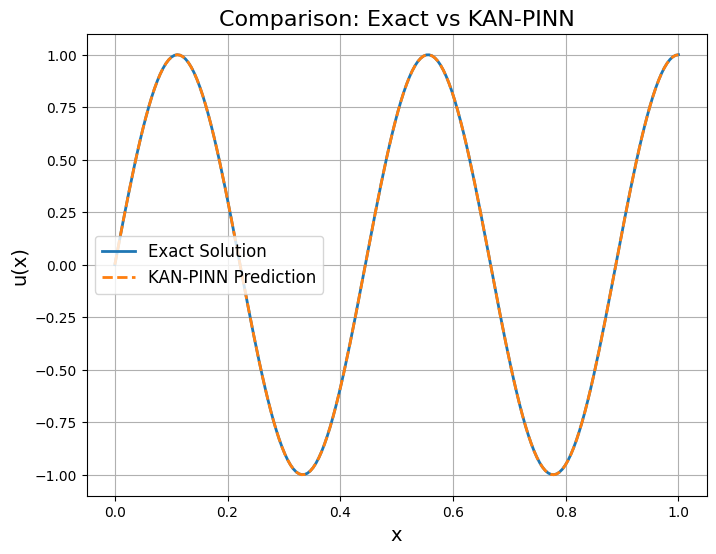

Relative error(MAE) = 6.795e-06.
MSE = 3.179e-08.


In [ ]:
# %% Import modules
import numpy as np
import jax
import jax.numpy as jnp
from jax import vjp, jit, grad
from jax.example_libraries import optimizers
from functools import partial
import time
import matplotlib.pyplot as plt

# %% Chebyshev helper functions
def chebyshev_recursive(x, degree):
    if degree == 0:
        return x * 0 + 1
    elif degree == 1:
        return x
    else:
        T_n_minus_1 = x
        T_n_minus_2 = x * 0 + 1
        for n in range(2, degree + 1):
            T_n = 2 * x * T_n_minus_1 - T_n_minus_2
            T_n_minus_2, T_n_minus_1 = T_n_minus_1, T_n
        return T_n

def chebyshev_cosine(x, degree):
    return jnp.cos(degree * jnp.arccos(x))

# %% KAN initialization
def init_params_kan2(layers, degree):
    keys = jax.random.split(jax.random.PRNGKey(123), len(layers) - 1)
    params = []
    for key, n_in, n_out in zip(keys[:-1], layers[:-2], layers[1:-1]):
        W = jax.random.normal(key, shape=(n_in, n_out, degree + 1)) / jnp.sqrt(n_in * (degree + 1))
        g = jax.random.normal(key, shape=(n_out,))
        params.append({'W': W, 'g': g})
    W = jax.random.normal(keys[-1], shape=(layers[-2], layers[-1])) / jnp.sqrt(layers[-2])
    B = jax.random.normal(keys[-1], shape=(layers[-1],))
    params.append({'W': W, 'B': B})
    return params

# %% KAN forward pass
def fwd_kan(params, t, activation=jax.nn.tanh, use_cosine=False):
    # t = 0.01 * t
    # t = activation(t)
    X = t.reshape((-1, 1))
    *hidden, last = params
    for layer in hidden:
        cheby_coeffs = layer['W']
        degree = cheby_coeffs.shape[2] - 1
        X = activation(X)
        X_stack = jnp.stack([chebyshev_recursive(X, d) for d in range(degree + 1)], axis=-1)
        X = jnp.einsum("bid,iod->bo", X_stack, cheby_coeffs)
    if X.shape[1] > 1:
        X = X[:, 0:1]

        # X = jnp.reshape(X, (outdim,))
        # X = layer['g'] * X
        # X = activation(X)
    return X #@ last['W'] + last['B']

# %% helper functions
def vgrad(f, x):
    y, vjp_fn = vjp(f, x)
    return vjp_fn(jnp.ones(y.shape))[0]

# Ground truth and forcing term
def exact_solution(x):
    return jnp.sin(9 * jnp.pi / 2 * x)

def forcing_term(x):
    coef = -(9 * jnp.pi / 2) ** 2 - 1
    return coef * jnp.sin(9 * jnp.pi / 2 * x)

# %% Define KAN-based PINN model
class PINN_KAN:
    def __init__(self, layers, degree, weight, activation=jax.nn.tanh, use_cosine=False):
        self.degree = degree
        self.activation = activation
        self.use_cosine = use_cosine
        self.weight_eqn, self.weight_bc = weight
        self.params = init_params_kan2(layers, degree)
        self.opt_init, self.opt_update, self.get_params = optimizers.adam(1e-4)
        self.opt_state = self.opt_init(self.params)

    @partial(jit, static_argnums=(0,))
    def equation(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        fu = lambda x: pinn(x)
        dudx = lambda x: vgrad(fu, x)
        d2udx2 = lambda x: vgrad(dudx, x)
        u = fu(X)
        u_xx = d2udx2(X)
        f = forcing_term(X)
        return u_xx - u - f

    @partial(jit, static_argnums=(0,))
    def forward(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        return pinn(X)

    @partial(jit, static_argnums=(0,))
    def loss_component(self, params, X_res, X_bc):
        x_bc, y_bc = X_bc
        eq1 = self.equation(params, X_res)
        loss_res = jnp.mean(eq1 ** 2)
        x_bc_l, x_bc_r = x_bc
        u_l_pred = self.forward(params, x_bc_l)
        u_r_pred = self.forward(params, x_bc_r)
        u_l, u_r = y_bc
        loss_bc = jnp.mean((u_l - u_l_pred) ** 2 + (u_r - u_r_pred) ** 2)
        return loss_res, loss_bc

    def loss(self, params, X_res, X_bc):
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return self.weight_eqn * loss_res + self.weight_bc * loss_bc

    @partial(jit, static_argnums=(0,))
    def update(self, i, opt_state, X_res, X_bc):
        params = self.get_params(opt_state)
        next_opt_state = self.opt_update(i, grad(self.loss)(params, X_res, X_bc), opt_state)
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return next_opt_state, (loss_res, loss_bc)

# %% prepare data
N = 1000
X = np.random.uniform(0, 1, size=(N,1))
X_res = jnp.array(X)

X_bc = (
    (jnp.array(0.0).reshape(-1,1), jnp.array(1.0).reshape(-1,1)),
    (jnp.array(0.0).reshape(-1,1), jnp.array(1.0).reshape(-1,1)),
)

# %% training
layers = [1, 50, 50, 1]
degree = 5
model = PINN_KAN(layers, degree, weight=(1,1))
N_epochs = 20000
Y_result = []

for epoch in range(1, N_epochs+1):
    start = time.time()
    model.opt_state, losses = model.update(epoch, model.opt_state, X_res, X_bc)
    model.params = model.get_params(model.opt_state)
    end = time.time()
    if epoch % 100 == 0:
        loss_res, loss_bc = losses
        print(f"Epoch: {epoch}, Time: {end-start:.2f}s, Loss_eqn={loss_res:.3e}, Loss_bc={loss_bc:.3e}")
        Y = model.forward(model.params, X_res)
        Y_result.append(Y)

# %% Compare and plot
X_plot = np.linspace(0, 1, 200).reshape(-1, 1)
X_plot_jax = jnp.array(X_plot)

Y_pred_plot = model.forward(model.params, X_plot_jax).flatten()
Y_true_plot = exact_solution(X_plot_jax).flatten()

plt.figure(figsize=(8,6))
plt.plot(X_plot, Y_true_plot, label="Exact Solution", linewidth=2)
plt.plot(X_plot, Y_pred_plot, '--', label="KAN-PINN Prediction", linewidth=2)
plt.xlabel('x', fontsize=14)
plt.ylabel('u(x)', fontsize=14)
plt.title('Comparison: Exact vs KAN-PINN', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# %% Relative error
Y_true = exact_solution(X_res).flatten()
Y_pred = Y_result[-1].flatten()
err = np.mean((Y_pred - Y_true)**2) / (np.mean(Y_true)**2)
print(f"Relative error(MAE) = {err:.3e}.")

err = np.mean((Y_pred - Y_true)**2)# / (np.mean(Y_true)**2)
print(f"MSE = {err:.3e}.")


Epoch: 100, Time: 0.00s, Loss_eqn=1.855e+04, Loss_bc=1.728e+00
Epoch: 200, Time: 0.00s, Loss_eqn=1.798e+04, Loss_bc=3.661e+00
Epoch: 300, Time: 0.00s, Loss_eqn=1.744e+04, Loss_bc=7.920e+00
Epoch: 400, Time: 0.00s, Loss_eqn=1.692e+04, Loss_bc=1.369e+01
Epoch: 500, Time: 0.00s, Loss_eqn=1.641e+04, Loss_bc=2.007e+01
Epoch: 600, Time: 0.00s, Loss_eqn=1.591e+04, Loss_bc=2.623e+01
Epoch: 700, Time: 0.00s, Loss_eqn=1.541e+04, Loss_bc=3.147e+01
Epoch: 800, Time: 0.00s, Loss_eqn=1.490e+04, Loss_bc=3.527e+01
Epoch: 900, Time: 0.00s, Loss_eqn=1.438e+04, Loss_bc=3.741e+01
Epoch: 1000, Time: 0.00s, Loss_eqn=1.383e+04, Loss_bc=3.792e+01
Epoch: 1100, Time: 0.00s, Loss_eqn=1.325e+04, Loss_bc=3.707e+01
Epoch: 1200, Time: 0.00s, Loss_eqn=1.264e+04, Loss_bc=3.525e+01
Epoch: 1300, Time: 0.00s, Loss_eqn=1.199e+04, Loss_bc=3.280e+01
Epoch: 1400, Time: 0.00s, Loss_eqn=1.130e+04, Loss_bc=3.002e+01
Epoch: 1500, Time: 0.00s, Loss_eqn=1.057e+04, Loss_bc=2.718e+01
Epoch: 1600, Time: 0.00s, Loss_eqn=9.817e+03, Los

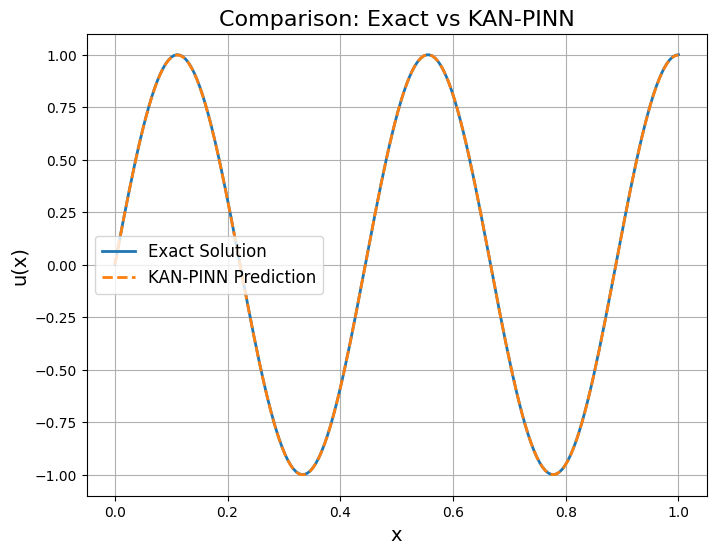

Relative error(MAE) = 6.851e-05.
MSE = 6.101e-07.


In [ ]:
# %% Import modules
import numpy as np
import jax
import jax.numpy as jnp
from jax import vjp, jit, grad
from jax.example_libraries import optimizers
from functools import partial
import time
import matplotlib.pyplot as plt

# %% Chebyshev helper functions
def chebyshev_recursive(x, degree):
    if degree == 0:
        return x * 0 + 1
    elif degree == 1:
        return x
    else:
        T_n_minus_1 = x
        T_n_minus_2 = x * 0 + 1
        for n in range(2, degree + 1):
            T_n = 2 * x * T_n_minus_1 - T_n_minus_2
            T_n_minus_2, T_n_minus_1 = T_n_minus_1, T_n
        return T_n

def chebyshev_cosine(x, degree):
    return jnp.cos(degree * jnp.arccos(x))

# %% KAN initialization
def init_params_kan2(layers, degree):
    keys = jax.random.split(jax.random.PRNGKey(13), len(layers) - 1)
    params = []
    for key, n_in, n_out in zip(keys[:-1], layers[:-2], layers[1:-1]):
        W = jax.random.normal(key, shape=(n_in, n_out, degree + 1)) / jnp.sqrt(n_in * (degree + 1))
        g = jax.random.normal(key, shape=(n_out,))
        params.append({'W': W, 'g': g})
    W = jax.random.normal(keys[-1], shape=(layers[-2], layers[-1])) / jnp.sqrt(layers[-2])
    B = jax.random.normal(keys[-1], shape=(layers[-1],))
    params.append({'W': W, 'B': B})
    return params

# %% KAN forward pass
def fwd_kan(params, t, activation=jax.nn.tanh, use_cosine=False):
    # t = 0.01 * t
    # t = activation(t)
    X = t.reshape((-1, 1))
    *hidden, last = params
    for layer in hidden:
        cheby_coeffs = layer['W']
        degree = cheby_coeffs.shape[2] - 1
        X = activation(X)
        X_stack = jnp.stack([chebyshev_recursive(X, d) for d in range(degree + 1)], axis=-1)
        X = jnp.einsum("bid,iod->bo", X_stack, cheby_coeffs)
    if X.shape[1] > 1:
        X = X[:, 0:1]
    return X #@ last['W'] + last['B']

# %% helper functions
def vgrad(f, x):
    y, vjp_fn = vjp(f, x)
    return vjp_fn(jnp.ones(y.shape))[0]

# Ground truth and forcing term
def exact_solution(x):
    return jnp.sin(9 * jnp.pi / 2 * x)

def forcing_term(x):
    coef = -(9 * jnp.pi / 2) ** 2 - 1
    return coef * jnp.sin(9 * jnp.pi / 2 * x)

# %% Define KAN-based PINN model
class PINN_KAN:
    def __init__(self, layers, degree, weight, activation=jax.nn.tanh, use_cosine=False):
        self.degree = degree
        self.activation = activation
        self.use_cosine = use_cosine
        self.weight_eqn, self.weight_bc = weight
        self.params = init_params_kan2(layers, degree)
        self.opt_init, self.opt_update, self.get_params = optimizers.adam(1e-4)
        self.opt_state = self.opt_init(self.params)

    @partial(jit, static_argnums=(0,))
    def equation(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        fu = lambda x: pinn(x)
        dudx = lambda x: vgrad(fu, x)
        d2udx2 = lambda x: vgrad(dudx, x)
        u = fu(X)
        u_xx = d2udx2(X)
        f = forcing_term(X)
        return u_xx - u - f

    @partial(jit, static_argnums=(0,))
    def forward(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        return pinn(X)

    @partial(jit, static_argnums=(0,))
    def loss_component(self, params, X_res, X_bc):
        x_bc, y_bc = X_bc
        eq1 = self.equation(params, X_res)
        loss_res = jnp.mean(eq1 ** 2)
        x_bc_l, x_bc_r = x_bc
        u_l_pred = self.forward(params, x_bc_l)
        u_r_pred = self.forward(params, x_bc_r)
        u_l, u_r = y_bc
        loss_bc = jnp.mean((u_l - u_l_pred) ** 2 + (u_r - u_r_pred) ** 2)
        return loss_res, loss_bc

    def loss(self, params, X_res, X_bc):
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return self.weight_eqn * loss_res + self.weight_bc * loss_bc

    @partial(jit, static_argnums=(0,))
    def update(self, i, opt_state, X_res, X_bc):
        params = self.get_params(opt_state)
        next_opt_state = self.opt_update(i, grad(self.loss)(params, X_res, X_bc), opt_state)
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return next_opt_state, (loss_res, loss_bc)

# %% prepare data
N = 1000
X = np.random.uniform(0, 1, size=(N,1))
X_res = jnp.array(X)

X_bc = (
    (jnp.array(0.0).reshape(-1,1), jnp.array(1.0).reshape(-1,1)),
    (jnp.array(0.0).reshape(-1,1), jnp.array(1.0).reshape(-1,1)),
)

# %% training
layers = [1, 50, 50, 1]
degree = 3
model = PINN_KAN(layers, degree, weight=(1,1))
N_epochs = 20000
Y_result = []

for epoch in range(1, N_epochs+1):
    start = time.time()
    model.opt_state, losses = model.update(epoch, model.opt_state, X_res, X_bc)
    model.params = model.get_params(model.opt_state)
    end = time.time()
    if epoch % 100 == 0:
        loss_res, loss_bc = losses
        print(f"Epoch: {epoch}, Time: {end-start:.2f}s, Loss_eqn={loss_res:.3e}, Loss_bc={loss_bc:.3e}")
        Y = model.forward(model.params, X_res)
        Y_result.append(Y)

# %% Compare and plot
X_plot = np.linspace(0, 1, 200).reshape(-1, 1)
X_plot_jax = jnp.array(X_plot)

Y_pred_plot = model.forward(model.params, X_plot_jax).flatten()
Y_true_plot = exact_solution(X_plot_jax).flatten()

plt.figure(figsize=(8,6))
plt.plot(X_plot, Y_true_plot, label="Exact Solution", linewidth=2)
plt.plot(X_plot, Y_pred_plot, '--', label="KAN-PINN Prediction", linewidth=2)
plt.xlabel('x', fontsize=14)
plt.ylabel('u(x)', fontsize=14)
plt.title('Comparison: Exact vs KAN-PINN', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# %% Relative error
Y_true = exact_solution(X_res).flatten()
Y_pred = Y_result[-1].flatten()
err = np.mean((Y_pred - Y_true)**2) / (np.mean(Y_true)**2)
print(f"Relative error(MAE) = {err:.3e}.")

err = np.mean((Y_pred - Y_true)**2)# / (np.mean(Y_true)**2)
print(f"MSE = {err:.3e}.")


Epoch: 100, Time: 0.00s, Loss_eqn=1.713e+04, Loss_bc=1.579e+00
Epoch: 200, Time: 0.00s, Loss_eqn=1.289e+04, Loss_bc=2.403e+00
Epoch: 300, Time: 0.00s, Loss_eqn=6.264e+03, Loss_bc=2.392e+00
Epoch: 400, Time: 0.00s, Loss_eqn=1.942e+03, Loss_bc=3.942e+00
Epoch: 500, Time: 0.00s, Loss_eqn=5.461e+02, Loss_bc=5.147e+00
Epoch: 600, Time: 0.00s, Loss_eqn=1.844e+02, Loss_bc=5.922e+00
Epoch: 700, Time: 0.00s, Loss_eqn=7.951e+01, Loss_bc=6.265e+00
Epoch: 800, Time: 0.00s, Loss_eqn=3.530e+01, Loss_bc=6.484e+00
Epoch: 900, Time: 0.00s, Loss_eqn=1.530e+01, Loss_bc=6.402e+00
Epoch: 1000, Time: 0.00s, Loss_eqn=7.176e+00, Loss_bc=6.160e+00
Epoch: 1100, Time: 0.00s, Loss_eqn=3.655e+00, Loss_bc=5.846e+00
Epoch: 1200, Time: 0.00s, Loss_eqn=2.102e+00, Loss_bc=5.527e+00
Epoch: 1300, Time: 0.00s, Loss_eqn=1.380e+00, Loss_bc=5.221e+00
Epoch: 1400, Time: 0.00s, Loss_eqn=9.852e-01, Loss_bc=4.933e+00
Epoch: 1500, Time: 0.00s, Loss_eqn=7.345e-01, Loss_bc=4.658e+00
Epoch: 1600, Time: 0.00s, Loss_eqn=5.763e-01, Los

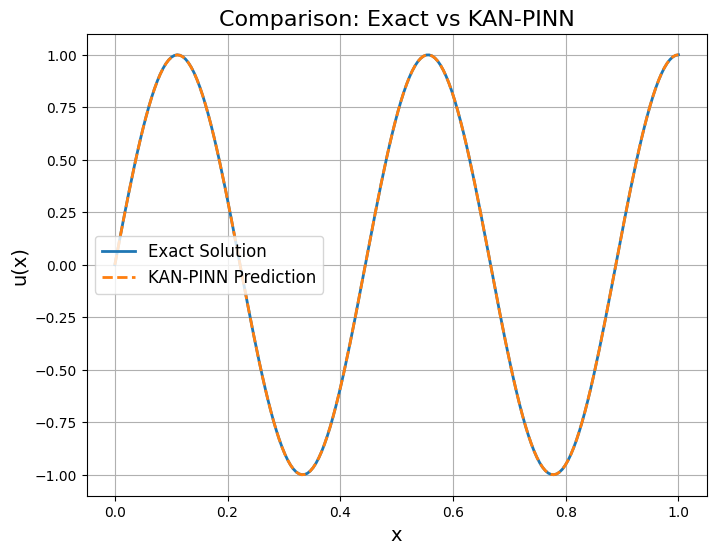

Relative error(MAE) = 2.292e-05.
MSE = 1.166e-07.


In [ ]:
# %% Import modules
import numpy as np
import jax
import jax.numpy as jnp
from jax import vjp, jit, grad
from jax.example_libraries import optimizers
from functools import partial
import time
import matplotlib.pyplot as plt

# %% Chebyshev helper functions
def chebyshev_recursive(x, degree):
    if degree == 0:
        return x * 0 + 1
    elif degree == 1:
        return x
    else:
        T_n_minus_1 = x
        T_n_minus_2 = x * 0 + 1
        for n in range(2, degree + 1):
            T_n = 2 * x * T_n_minus_1 - T_n_minus_2
            T_n_minus_2, T_n_minus_1 = T_n_minus_1, T_n
        return T_n

def chebyshev_cosine(x, degree):
    return jnp.cos(degree * jnp.arccos(x))

# %% KAN initialization
def init_params_kan2(layers, degree):
    keys = jax.random.split(jax.random.PRNGKey(123), len(layers) - 1)
    params = []
    for key, n_in, n_out in zip(keys[:-1], layers[:-2], layers[1:-1]):
        W = jax.random.normal(key, shape=(n_in, n_out, degree + 1)) / jnp.sqrt(n_in * (degree + 1))
        g = jax.random.normal(key, shape=(n_out,))
        params.append({'W': W, 'g': g})
    W = jax.random.normal(keys[-1], shape=(layers[-2], layers[-1])) / jnp.sqrt(layers[-2])
    B = jax.random.normal(keys[-1], shape=(layers[-1],))
    params.append({'W': W, 'B': B})
    return params

# %% KAN forward pass
def fwd_kan(params, t, activation=jax.nn.tanh, use_cosine=False):
    # t = 0.01 * t
    t = activation(t)
    X = t.reshape((-1, 1))
    *hidden, last = params
    for layer in hidden:
        cheby_coeffs = layer['W']
        degree = cheby_coeffs.shape[2] - 1
        if use_cosine:
            X_stack = jnp.stack([chebyshev_cosine(X, d) for d in range(degree + 1)], axis=-1)
        else:
            X_stack = jnp.stack([chebyshev_recursive(X, d) for d in range(degree + 1)], axis=-1)
        X = jnp.einsum("bid,iod->bo", X_stack, cheby_coeffs)
        # X = layer['g'] * X
        X = activation(X)
    return X @ last['W'] + last['B']

# %% helper functions
def vgrad(f, x):
    y, vjp_fn = vjp(f, x)
    return vjp_fn(jnp.ones(y.shape))[0]

# Ground truth and forcing term
def exact_solution(x):
    return jnp.sin(9 * jnp.pi / 2 * x)

def forcing_term(x):
    coef = -(9 * jnp.pi / 2) ** 2 - 1
    return coef * jnp.sin(9 * jnp.pi / 2 * x)

# %% Define KAN-based PINN model
class PINN_KAN:
    def __init__(self, layers, degree, weight, activation=jax.nn.tanh, use_cosine=False):
        self.degree = degree
        self.activation = activation
        self.use_cosine = use_cosine
        self.weight_eqn, self.weight_bc = weight
        self.params = init_params_kan2(layers, degree)
        self.opt_init, self.opt_update, self.get_params = optimizers.adam(1e-4)
        self.opt_state = self.opt_init(self.params)

    @partial(jit, static_argnums=(0,))
    def equation(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        fu = lambda x: pinn(x)
        dudx = lambda x: vgrad(fu, x)
        d2udx2 = lambda x: vgrad(dudx, x)
        u = fu(X)
        u_xx = d2udx2(X)
        f = forcing_term(X)
        return u_xx - u - f

    @partial(jit, static_argnums=(0,))
    def forward(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        return pinn(X)

    @partial(jit, static_argnums=(0,))
    def loss_component(self, params, X_res, X_bc):
        x_bc, y_bc = X_bc
        eq1 = self.equation(params, X_res)
        loss_res = jnp.mean(eq1 ** 2)
        x_bc_l, x_bc_r = x_bc
        u_l_pred = self.forward(params, x_bc_l)
        u_r_pred = self.forward(params, x_bc_r)
        u_l, u_r = y_bc
        loss_bc = jnp.mean((u_l - u_l_pred) ** 2 + (u_r - u_r_pred) ** 2)
        return loss_res, loss_bc

    def loss(self, params, X_res, X_bc):
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return self.weight_eqn * loss_res + self.weight_bc * loss_bc

    @partial(jit, static_argnums=(0,))
    def update(self, i, opt_state, X_res, X_bc):
        params = self.get_params(opt_state)
        next_opt_state = self.opt_update(i, grad(self.loss)(params, X_res, X_bc), opt_state)
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return next_opt_state, (loss_res, loss_bc)

# %% prepare data
N = 1000
X = np.random.uniform(0, 1, size=(N,1))
X_res = jnp.array(X)

X_bc = (
    (jnp.array(0.0).reshape(-1,1), jnp.array(1.0).reshape(-1,1)),
    (jnp.array(0.0).reshape(-1,1), jnp.array(1.0).reshape(-1,1)),
)

# %% training
layers = [1, 50, 50, 1]
degree = 3
model = PINN_KAN(layers, degree, weight=(1,1))
N_epochs = 20000
Y_result = []

for epoch in range(1, N_epochs+1):
    start = time.time()
    model.opt_state, losses = model.update(epoch, model.opt_state, X_res, X_bc)
    model.params = model.get_params(model.opt_state)
    end = time.time()
    if epoch % 100 == 0:
        loss_res, loss_bc = losses
        print(f"Epoch: {epoch}, Time: {end-start:.2f}s, Loss_eqn={loss_res:.3e}, Loss_bc={loss_bc:.3e}")
        Y = model.forward(model.params, X_res)
        Y_result.append(Y)

# %% Compare and plot
X_plot = np.linspace(0, 1, 200).reshape(-1, 1)
X_plot_jax = jnp.array(X_plot)

Y_pred_plot = model.forward(model.params, X_plot_jax).flatten()
Y_true_plot = exact_solution(X_plot_jax).flatten()

plt.figure(figsize=(8,6))
plt.plot(X_plot, Y_true_plot, label="Exact Solution", linewidth=2)
plt.plot(X_plot, Y_pred_plot, '--', label="KAN-PINN Prediction", linewidth=2)
plt.xlabel('x', fontsize=14)
plt.ylabel('u(x)', fontsize=14)
plt.title('Comparison: Exact vs KAN-PINN', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# %% Relative error
Y_true = exact_solution(X_res).flatten()
Y_pred = Y_result[-1].flatten()
err = np.mean((Y_pred - Y_true)**2) / (np.mean(Y_true)**2)
print(f"Relative error(MAE) = {err:.3e}.")

err = np.mean((Y_pred - Y_true)**2)# / (np.mean(Y_true)**2)
print(f"MSE = {err:.3e}.")


Epoch: 100, Time: 0.00s, Loss_eqn=1.855e+04, Loss_bc=1.724e+01
Epoch: 200, Time: 0.00s, Loss_eqn=1.690e+04, Loss_bc=5.470e+01
Epoch: 300, Time: 0.00s, Loss_eqn=1.525e+04, Loss_bc=6.462e+01
Epoch: 400, Time: 0.00s, Loss_eqn=1.336e+04, Loss_bc=4.771e+01
Epoch: 500, Time: 0.00s, Loss_eqn=1.111e+04, Loss_bc=2.791e+01
Epoch: 600, Time: 0.00s, Loss_eqn=8.586e+03, Loss_bc=2.684e+01
Epoch: 700, Time: 0.00s, Loss_eqn=6.039e+03, Loss_bc=5.671e+01
Epoch: 800, Time: 0.00s, Loss_eqn=3.864e+03, Loss_bc=1.034e+02
Epoch: 900, Time: 0.00s, Loss_eqn=2.344e+03, Loss_bc=1.305e+02
Epoch: 1000, Time: 0.00s, Loss_eqn=1.464e+03, Loss_bc=1.168e+02
Epoch: 1100, Time: 0.00s, Loss_eqn=9.953e+02, Loss_bc=7.711e+01
Epoch: 1200, Time: 0.00s, Loss_eqn=7.235e+02, Loss_bc=3.870e+01
Epoch: 1300, Time: 0.00s, Loss_eqn=5.405e+02, Loss_bc=1.465e+01
Epoch: 1400, Time: 0.00s, Loss_eqn=4.061e+02, Loss_bc=3.758e+00
Epoch: 1500, Time: 0.00s, Loss_eqn=3.045e+02, Loss_bc=4.050e-01
Epoch: 1600, Time: 0.00s, Loss_eqn=2.273e+02, Los

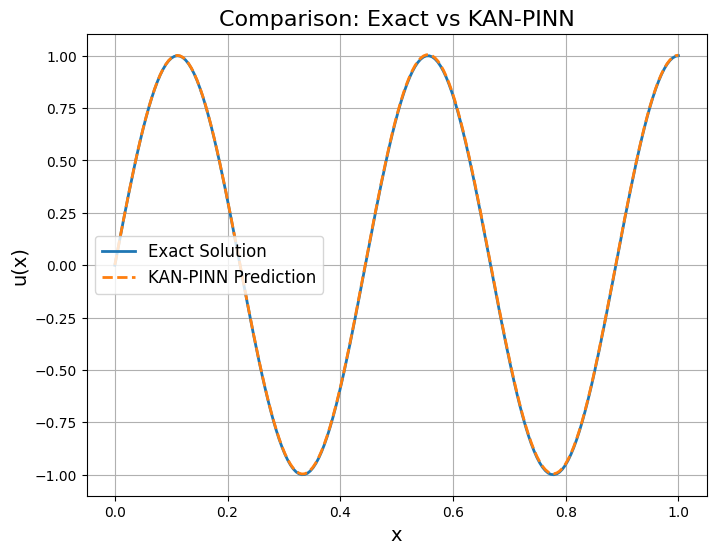

Relative error(MAE) = 4.163e-03.
MSE = 1.477e-05.


In [ ]:
# %% Import modules
import numpy as np
import jax
import jax.numpy as jnp
from jax import vjp, jit, grad
from jax.example_libraries import optimizers
from functools import partial
import time
import matplotlib.pyplot as plt

# %% Chebyshev helper functions
def chebyshev_recursive(x, degree):
    if degree == 0:
        return x * 0 + 1
    elif degree == 1:
        return x
    else:
        T_n_minus_1 = x
        T_n_minus_2 = x * 0 + 1
        for n in range(2, degree + 1):
            T_n = 2 * x * T_n_minus_1 - T_n_minus_2
            T_n_minus_2, T_n_minus_1 = T_n_minus_1, T_n
        return T_n

def chebyshev_cosine(x, degree):
    return jnp.cos(degree * jnp.arccos(x))

# %% KAN initialization
def init_params_kan2(layers, degree):
    keys = jax.random.split(jax.random.PRNGKey(123), len(layers) - 1)
    params = []
    for key, n_in, n_out in zip(keys[:-1], layers[:-2], layers[1:-1]):
        W = jax.random.normal(key, shape=(n_in, n_out, degree + 1)) / jnp.sqrt(n_in * (degree + 1))
        g = jax.random.normal(key, shape=(n_out,))
        params.append({'W': W, 'g': g})
    W = jax.random.normal(keys[-1], shape=(layers[-2], layers[-1])) / jnp.sqrt(layers[-2])
    B = jax.random.normal(keys[-1], shape=(layers[-1],))
    params.append({'W': W, 'B': B})
    return params

# %% KAN forward pass
def fwd_kan(params, t, activation=jax.nn.tanh, use_cosine=False):
    # t = 0.01 * t
    # t = activation(t)
    X = t.reshape((-1, 1))
    *hidden, last = params
    for layer in hidden:
        X = activation(X)
        cheby_coeffs = layer['W']
        degree = cheby_coeffs.shape[2] - 1
        if use_cosine:
            X_stack = jnp.stack([chebyshev_cosine(X, d) for d in range(degree + 1)], axis=-1)
        else:
            X_stack = jnp.stack([chebyshev_recursive(X, d) for d in range(degree + 1)], axis=-1)
        X = jnp.einsum("bid,iod->bo", X_stack, cheby_coeffs)
        # X = layer['g'] * X
        # X = activation(X)
    return X @ last['W'] + last['B']

# %% helper functions
def vgrad(f, x):
    y, vjp_fn = vjp(f, x)
    return vjp_fn(jnp.ones(y.shape))[0]

# Ground truth and forcing term
def exact_solution(x):
    return jnp.sin(9 * jnp.pi / 2 * x)

def forcing_term(x):
    coef = -(9 * jnp.pi / 2) ** 2 - 1
    return coef * jnp.sin(9 * jnp.pi / 2 * x)

# %% Define KAN-based PINN model
class PINN_KAN:
    def __init__(self, layers, degree, weight, activation=jax.nn.tanh, use_cosine=False):
        self.degree = degree
        self.activation = activation
        self.use_cosine = use_cosine
        self.weight_eqn, self.weight_bc = weight
        self.params = init_params_kan2(layers, degree)
        self.opt_init, self.opt_update, self.get_params = optimizers.adam(1e-4)
        self.opt_state = self.opt_init(self.params)

    @partial(jit, static_argnums=(0,))
    def equation(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        fu = lambda x: pinn(x)
        dudx = lambda x: vgrad(fu, x)
        d2udx2 = lambda x: vgrad(dudx, x)
        u = fu(X)
        u_xx = d2udx2(X)
        f = forcing_term(X)
        return u_xx - u - f

    @partial(jit, static_argnums=(0,))
    def forward(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        return pinn(X)

    @partial(jit, static_argnums=(0,))
    def loss_component(self, params, X_res, X_bc):
        x_bc, y_bc = X_bc
        eq1 = self.equation(params, X_res)
        loss_res = jnp.mean(eq1 ** 2)
        x_bc_l, x_bc_r = x_bc
        u_l_pred = self.forward(params, x_bc_l)
        u_r_pred = self.forward(params, x_bc_r)
        u_l, u_r = y_bc
        loss_bc = jnp.mean((u_l - u_l_pred) ** 2 + (u_r - u_r_pred) ** 2)
        return loss_res, loss_bc

    def loss(self, params, X_res, X_bc):
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return self.weight_eqn * loss_res + self.weight_bc * loss_bc

    @partial(jit, static_argnums=(0,))
    def update(self, i, opt_state, X_res, X_bc):
        params = self.get_params(opt_state)
        next_opt_state = self.opt_update(i, grad(self.loss)(params, X_res, X_bc), opt_state)
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return next_opt_state, (loss_res, loss_bc)

# %% prepare data
N = 1000
X = np.random.uniform(0, 1, size=(N,1))
X_res = jnp.array(X)

X_bc = (
    (jnp.array(0.0).reshape(-1,1), jnp.array(1.0).reshape(-1,1)),
    (jnp.array(0.0).reshape(-1,1), jnp.array(1.0).reshape(-1,1)),
)

# %% training
layers = [1, 50, 50, 1]
degree = 3
model = PINN_KAN(layers, degree, weight=(1,1))
N_epochs = 20000
Y_result = []

for epoch in range(1, N_epochs+1):
    start = time.time()
    model.opt_state, losses = model.update(epoch, model.opt_state, X_res, X_bc)
    model.params = model.get_params(model.opt_state)
    end = time.time()
    if epoch % 100 == 0:
        loss_res, loss_bc = losses
        print(f"Epoch: {epoch}, Time: {end-start:.2f}s, Loss_eqn={loss_res:.3e}, Loss_bc={loss_bc:.3e}")
        Y = model.forward(model.params, X_res)
        Y_result.append(Y)

# %% Compare and plot
X_plot = np.linspace(0, 1, 200).reshape(-1, 1)
X_plot_jax = jnp.array(X_plot)

Y_pred_plot = model.forward(model.params, X_plot_jax).flatten()
Y_true_plot = exact_solution(X_plot_jax).flatten()

plt.figure(figsize=(8,6))
plt.plot(X_plot, Y_true_plot, label="Exact Solution", linewidth=2)
plt.plot(X_plot, Y_pred_plot, '--', label="KAN-PINN Prediction", linewidth=2)
plt.xlabel('x', fontsize=14)
plt.ylabel('u(x)', fontsize=14)
plt.title('Comparison: Exact vs KAN-PINN', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# %% Relative error
Y_true = exact_solution(X_res).flatten()
Y_pred = Y_result[-1].flatten()
err = np.mean((Y_pred - Y_true)**2) / (np.mean(Y_true)**2)
print(f"Relative error(MAE) = {err:.3e}.")

err = np.mean((Y_pred - Y_true)**2)# / (np.mean(Y_true)**2)
print(f"MSE = {err:.3e}.")


Epoch: 100, Time: 0.00s, Loss_eqn=2.750e+03, Loss_bc=1.246e+02
Epoch: 200, Time: 0.00s, Loss_eqn=1.207e+02, Loss_bc=3.328e+00
Epoch: 300, Time: 0.00s, Loss_eqn=9.636e+00, Loss_bc=4.534e-03
Epoch: 400, Time: 0.00s, Loss_eqn=6.041e+00, Loss_bc=1.187e-02
Epoch: 500, Time: 0.00s, Loss_eqn=4.286e+00, Loss_bc=8.330e-03
Epoch: 600, Time: 0.00s, Loss_eqn=3.015e+00, Loss_bc=4.944e-03
Epoch: 700, Time: 0.00s, Loss_eqn=2.125e+00, Loss_bc=2.833e-03
Epoch: 800, Time: 0.00s, Loss_eqn=1.523e+00, Loss_bc=1.548e-03
Epoch: 900, Time: 0.00s, Loss_eqn=1.128e+00, Loss_bc=7.967e-04
Epoch: 1000, Time: 0.00s, Loss_eqn=8.747e-01, Loss_bc=3.822e-04
Epoch: 1100, Time: 0.00s, Loss_eqn=7.135e-01, Loss_bc=1.681e-04
Epoch: 1200, Time: 0.00s, Loss_eqn=6.100e-01, Loss_bc=6.721e-05
Epoch: 1300, Time: 0.00s, Loss_eqn=5.415e-01, Loss_bc=2.497e-05
Epoch: 1400, Time: 0.00s, Loss_eqn=4.940e-01, Loss_bc=1.009e-05
Epoch: 1500, Time: 0.00s, Loss_eqn=4.591e-01, Loss_bc=6.896e-06
Epoch: 1600, Time: 0.00s, Loss_eqn=4.319e-01, Los

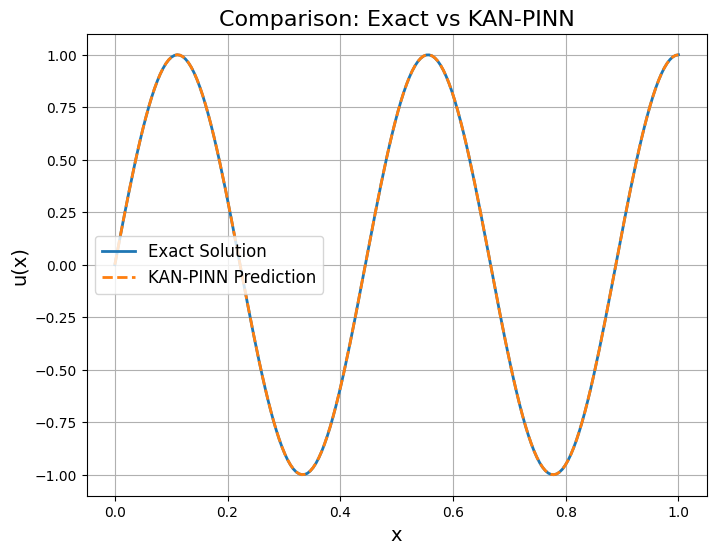

Relative error(MAE) = 2.150e-05.
MSE = 1.359e-07.


In [ ]:
# %% Import modules
import numpy as np
import jax
import jax.numpy as jnp
from jax import vjp, jit, grad
from jax.example_libraries import optimizers
from functools import partial
import time
import matplotlib.pyplot as plt

# %% Chebyshev helper functions
def chebyshev_recursive(x, degree):
    if degree == 0:
        return x * 0 + 1
    elif degree == 1:
        return x
    else:
        T_n_minus_1 = x
        T_n_minus_2 = x * 0 + 1
        for n in range(2, degree + 1):
            T_n = 2 * x * T_n_minus_1 - T_n_minus_2
            T_n_minus_2, T_n_minus_1 = T_n_minus_1, T_n
        return T_n

def chebyshev_cosine(x, degree):
    return jnp.cos(degree * jnp.arccos(x))

# %% KAN initialization
def init_params_kan2(layers, degree):
    keys = jax.random.split(jax.random.PRNGKey(123), len(layers) - 1)
    params = []
    for key, n_in, n_out in zip(keys[:-1], layers[:-2], layers[1:-1]):
        W = jax.random.normal(key, shape=(n_in, n_out, degree + 1)) / jnp.sqrt(n_in * (degree + 1))
        g = jax.random.normal(key, shape=(n_out,))
        params.append({'W': W, 'g': g})
    W = jax.random.normal(keys[-1], shape=(layers[-2], layers[-1])) / jnp.sqrt(layers[-2])
    B = jax.random.normal(keys[-1], shape=(layers[-1],))
    params.append({'W': W, 'B': B})
    return params

# %% KAN forward pass
def fwd_kan(params, t, activation=jax.nn.tanh, use_cosine=False):
    # t = 0.01 * t
    # t = activation(t)
    X = t.reshape((-1, 1))
    *hidden, last = params
    for layer in hidden:
        X = activation(X)
        cheby_coeffs = layer['W']
        degree = cheby_coeffs.shape[2] - 1
        if use_cosine:
            X_stack = jnp.stack([chebyshev_cosine(X, d) for d in range(degree + 1)], axis=-1)
        else:
            X_stack = jnp.stack([chebyshev_recursive(X, d) for d in range(degree + 1)], axis=-1)
        X = jnp.einsum("bid,iod->bo", X_stack, cheby_coeffs)
        # X = layer['g'] * X
        # X = activation(X)
    return X @ last['W'] + last['B']

# %% helper functions
def vgrad(f, x):
    y, vjp_fn = vjp(f, x)
    return vjp_fn(jnp.ones(y.shape))[0]

# Ground truth and forcing term
def exact_solution(x):
    return jnp.sin(9 * jnp.pi / 2 * x)

def forcing_term(x):
    coef = -(9 * jnp.pi / 2) ** 2 - 1
    return coef * jnp.sin(9 * jnp.pi / 2 * x)

# %% Define KAN-based PINN model
class PINN_KAN:
    def __init__(self, layers, degree, weight, activation=jax.nn.tanh, use_cosine=False):
        self.degree = degree
        self.activation = activation
        self.use_cosine = use_cosine
        self.weight_eqn, self.weight_bc = weight
        self.params = init_params_kan2(layers, degree)
        self.opt_init, self.opt_update, self.get_params = optimizers.adam(1e-3)
        self.opt_state = self.opt_init(self.params)

    @partial(jit, static_argnums=(0,))
    def equation(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        fu = lambda x: pinn(x)
        dudx = lambda x: vgrad(fu, x)
        d2udx2 = lambda x: vgrad(dudx, x)
        u = fu(X)
        u_xx = d2udx2(X)
        f = forcing_term(X)
        return u_xx - u - f

    @partial(jit, static_argnums=(0,))
    def forward(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        return pinn(X)

    @partial(jit, static_argnums=(0,))
    def loss_component(self, params, X_res, X_bc):
        x_bc, y_bc = X_bc
        eq1 = self.equation(params, X_res)
        loss_res = jnp.mean(eq1 ** 2)
        x_bc_l, x_bc_r = x_bc
        u_l_pred = self.forward(params, x_bc_l)
        u_r_pred = self.forward(params, x_bc_r)
        u_l, u_r = y_bc
        loss_bc = jnp.mean((u_l - u_l_pred) ** 2 + (u_r - u_r_pred) ** 2)
        return loss_res, loss_bc

    def loss(self, params, X_res, X_bc):
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return self.weight_eqn * loss_res + self.weight_bc * loss_bc

    @partial(jit, static_argnums=(0,))
    def update(self, i, opt_state, X_res, X_bc):
        params = self.get_params(opt_state)
        next_opt_state = self.opt_update(i, grad(self.loss)(params, X_res, X_bc), opt_state)
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return next_opt_state, (loss_res, loss_bc)

# %% prepare data
N = 1000
X = np.random.uniform(0, 1, size=(N,1))
X_res = jnp.array(X)

X_bc = (
    (jnp.array(0.0).reshape(-1,1), jnp.array(1.0).reshape(-1,1)),
    (jnp.array(0.0).reshape(-1,1), jnp.array(1.0).reshape(-1,1)),
)

# %% training
layers = [1, 50, 50, 1]
degree = 3
model = PINN_KAN(layers, degree, weight=(1,1))
N_epochs = 20000
Y_result = []

for epoch in range(1, N_epochs+1):
    start = time.time()
    model.opt_state, losses = model.update(epoch, model.opt_state, X_res, X_bc)
    model.params = model.get_params(model.opt_state)
    end = time.time()
    if epoch % 100 == 0:
        loss_res, loss_bc = losses
        print(f"Epoch: {epoch}, Time: {end-start:.2f}s, Loss_eqn={loss_res:.3e}, Loss_bc={loss_bc:.3e}")
        Y = model.forward(model.params, X_res)
        Y_result.append(Y)

# %% Compare and plot
X_plot = np.linspace(0, 1, 200).reshape(-1, 1)
X_plot_jax = jnp.array(X_plot)

Y_pred_plot = model.forward(model.params, X_plot_jax).flatten()
Y_true_plot = exact_solution(X_plot_jax).flatten()

plt.figure(figsize=(8,6))
plt.plot(X_plot, Y_true_plot, label="Exact Solution", linewidth=2)
plt.plot(X_plot, Y_pred_plot, '--', label="KAN-PINN Prediction", linewidth=2)
plt.xlabel('x', fontsize=14)
plt.ylabel('u(x)', fontsize=14)
plt.title('Comparison: Exact vs KAN-PINN', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# %% Relative error
Y_true = exact_solution(X_res).flatten()
Y_pred = Y_result[-1].flatten()
err = np.mean((Y_pred - Y_true)**2) / (np.mean(Y_true)**2)
print(f"Relative error(MAE) = {err:.3e}.")

err = np.mean((Y_pred - Y_true)**2)# / (np.mean(Y_true)**2)
print(f"MSE = {err:.3e}.")


Epoch: 100, Time: 0.00s, Loss_eqn=7.435e+02, Loss_bc=2.280e+00
Epoch: 200, Time: 0.00s, Loss_eqn=1.383e+00, Loss_bc=2.339e-02
Epoch: 300, Time: 0.00s, Loss_eqn=4.381e+00, Loss_bc=2.801e-03
Epoch: 400, Time: 0.00s, Loss_eqn=1.238e+00, Loss_bc=3.385e-03
Epoch: 500, Time: 0.00s, Loss_eqn=3.289e-01, Loss_bc=2.269e-03
Epoch: 600, Time: 0.00s, Loss_eqn=2.789e-01, Loss_bc=9.527e-04
Epoch: 700, Time: 0.00s, Loss_eqn=2.476e-01, Loss_bc=4.152e-04
Epoch: 800, Time: 0.00s, Loss_eqn=2.241e+00, Loss_bc=1.126e-04
Epoch: 900, Time: 0.00s, Loss_eqn=1.938e-01, Loss_bc=2.288e-04
Epoch: 1000, Time: 0.00s, Loss_eqn=1.968e-01, Loss_bc=5.123e-05
Epoch: 1100, Time: 0.00s, Loss_eqn=1.579e-01, Loss_bc=1.682e-04
Epoch: 1200, Time: 0.00s, Loss_eqn=3.975e-01, Loss_bc=1.404e-04
Epoch: 1300, Time: 0.00s, Loss_eqn=1.328e-01, Loss_bc=1.439e-04
Epoch: 1400, Time: 0.00s, Loss_eqn=1.194e+00, Loss_bc=3.561e-03
Epoch: 1500, Time: 0.00s, Loss_eqn=1.067e-01, Loss_bc=1.187e-04
Epoch: 1600, Time: 0.00s, Loss_eqn=9.369e-02, Los

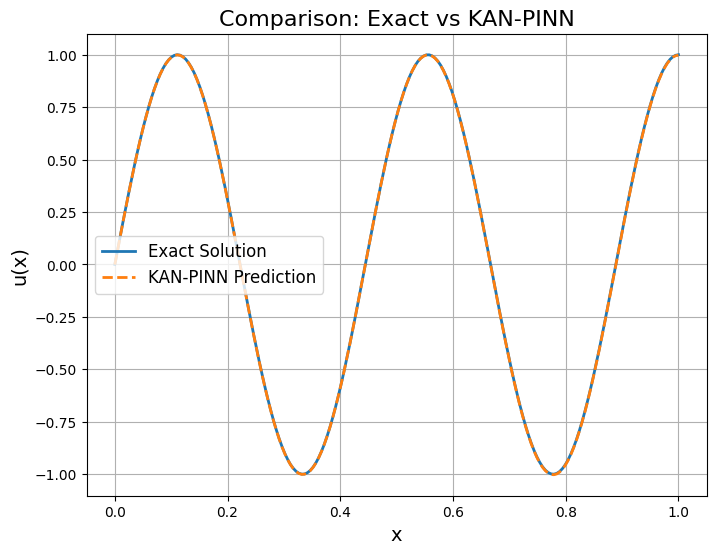

Relative error(MAE) = 5.147e-04.
MSE = 2.936e-06.


In [ ]:
# %% Import modules
import numpy as np
import jax
import jax.numpy as jnp
from jax import vjp, jit, grad
from jax.example_libraries import optimizers
from functools import partial
import time
import matplotlib.pyplot as plt

# %% Chebyshev helper functions
def chebyshev_recursive(x, degree):
    if degree == 0:
        return x * 0 + 1
    elif degree == 1:
        return x
    else:
        T_n_minus_1 = x
        T_n_minus_2 = x * 0 + 1
        for n in range(2, degree + 1):
            T_n = 2 * x * T_n_minus_1 - T_n_minus_2
            T_n_minus_2, T_n_minus_1 = T_n_minus_1, T_n
        return T_n

def chebyshev_cosine(x, degree):
    return jnp.cos(degree * jnp.arccos(x))

# %% KAN initialization
def init_params_kan2(layers, degree):
    keys = jax.random.split(jax.random.PRNGKey(123), len(layers) - 1)
    params = []
    for key, n_in, n_out in zip(keys[:-1], layers[:-2], layers[1:-1]):
        W = jax.random.normal(key, shape=(n_in, n_out, degree + 1)) / jnp.sqrt(n_in * (degree + 1))
        g = jax.random.normal(key, shape=(n_out,))
        params.append({'W': W, 'g': g})
    W = jax.random.normal(keys[-1], shape=(layers[-2], layers[-1])) / jnp.sqrt(layers[-2])
    B = jax.random.normal(keys[-1], shape=(layers[-1],))
    params.append({'W': W, 'B': B})
    return params

# %% KAN forward pass
def fwd_kan(params, t, activation=jax.nn.tanh, use_cosine=False):
    # t = 0.01 * t
    # t = activation(t)
    X = t.reshape((-1, 1))
    *hidden, last = params
    for layer in hidden:
        X = activation(X)
        cheby_coeffs = layer['W']
        degree = cheby_coeffs.shape[2] - 1
        if use_cosine:
            X_stack = jnp.stack([chebyshev_cosine(X, d) for d in range(degree + 1)], axis=-1)
        else:
            X_stack = jnp.stack([chebyshev_recursive(X, d) for d in range(degree + 1)], axis=-1)
        X = jnp.einsum("bid,iod->bo", X_stack, cheby_coeffs)
        X = layer['g'] * X
        X = activation(X)
    return X @ last['W'] + last['B']

# %% helper functions
def vgrad(f, x):
    y, vjp_fn = vjp(f, x)
    return vjp_fn(jnp.ones(y.shape))[0]

# Ground truth and forcing term
def exact_solution(x):
    return jnp.sin(9 * jnp.pi / 2 * x)

def forcing_term(x):
    coef = -(9 * jnp.pi / 2) ** 2 - 1
    return coef * jnp.sin(9 * jnp.pi / 2 * x)

# %% Define KAN-based PINN model
class PINN_KAN:
    def __init__(self, layers, degree, weight, activation=jax.nn.tanh, use_cosine=False):
        self.degree = degree
        self.activation = activation
        self.use_cosine = use_cosine
        self.weight_eqn, self.weight_bc = weight
        self.params = init_params_kan2(layers, degree)
        self.opt_init, self.opt_update, self.get_params = optimizers.adam(1e-3)
        self.opt_state = self.opt_init(self.params)

    @partial(jit, static_argnums=(0,))
    def equation(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        fu = lambda x: pinn(x)
        dudx = lambda x: vgrad(fu, x)
        d2udx2 = lambda x: vgrad(dudx, x)
        u = fu(X)
        u_xx = d2udx2(X)
        f = forcing_term(X)
        return u_xx - u - f

    @partial(jit, static_argnums=(0,))
    def forward(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        return pinn(X)

    @partial(jit, static_argnums=(0,))
    def loss_component(self, params, X_res, X_bc):
        x_bc, y_bc = X_bc
        eq1 = self.equation(params, X_res)
        loss_res = jnp.mean(eq1 ** 2)
        x_bc_l, x_bc_r = x_bc
        u_l_pred = self.forward(params, x_bc_l)
        u_r_pred = self.forward(params, x_bc_r)
        u_l, u_r = y_bc
        loss_bc = jnp.mean((u_l - u_l_pred) ** 2 + (u_r - u_r_pred) ** 2)
        return loss_res, loss_bc

    def loss(self, params, X_res, X_bc):
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return self.weight_eqn * loss_res + self.weight_bc * loss_bc

    @partial(jit, static_argnums=(0,))
    def update(self, i, opt_state, X_res, X_bc):
        params = self.get_params(opt_state)
        next_opt_state = self.opt_update(i, grad(self.loss)(params, X_res, X_bc), opt_state)
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return next_opt_state, (loss_res, loss_bc)

# %% prepare data
N = 1000
X = np.random.uniform(0, 1, size=(N,1))
X_res = jnp.array(X)

X_bc = (
    (jnp.array(0.0).reshape(-1,1), jnp.array(1.0).reshape(-1,1)),
    (jnp.array(0.0).reshape(-1,1), jnp.array(1.0).reshape(-1,1)),
)

# %% training
layers = [1, 50, 50, 1]
degree = 3
model = PINN_KAN(layers, degree, weight=(1,1))
N_epochs = 20000
Y_result = []

for epoch in range(1, N_epochs+1):
    start = time.time()
    model.opt_state, losses = model.update(epoch, model.opt_state, X_res, X_bc)
    model.params = model.get_params(model.opt_state)
    end = time.time()
    if epoch % 100 == 0:
        loss_res, loss_bc = losses
        print(f"Epoch: {epoch}, Time: {end-start:.2f}s, Loss_eqn={loss_res:.3e}, Loss_bc={loss_bc:.3e}")
        Y = model.forward(model.params, X_res)
        Y_result.append(Y)

# %% Compare and plot
X_plot = np.linspace(0, 1, 200).reshape(-1, 1)
X_plot_jax = jnp.array(X_plot)

Y_pred_plot = model.forward(model.params, X_plot_jax).flatten()
Y_true_plot = exact_solution(X_plot_jax).flatten()

plt.figure(figsize=(8,6))
plt.plot(X_plot, Y_true_plot, label="Exact Solution", linewidth=2)
plt.plot(X_plot, Y_pred_plot, '--', label="KAN-PINN Prediction", linewidth=2)
plt.xlabel('x', fontsize=14)
plt.ylabel('u(x)', fontsize=14)
plt.title('Comparison: Exact vs KAN-PINN', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# %% Relative error
Y_true = exact_solution(X_res).flatten()
Y_pred = Y_result[-1].flatten()
err = np.mean((Y_pred - Y_true)**2) / (np.mean(Y_true)**2)
print(f"Relative error(MAE) = {err:.3e}.")

err = np.mean((Y_pred - Y_true)**2)# / (np.mean(Y_true)**2)
print(f"MSE = {err:.3e}.")


Epoch: 100, Time: 0.00s, Loss_eqn=4.139e+02, Loss_bc=4.239e+00
Epoch: 200, Time: 0.00s, Loss_eqn=2.782e+00, Loss_bc=2.058e+00
Epoch: 300, Time: 0.00s, Loss_eqn=1.328e+00, Loss_bc=8.692e-01
Epoch: 400, Time: 0.00s, Loss_eqn=1.332e+00, Loss_bc=3.675e-01
Epoch: 500, Time: 0.00s, Loss_eqn=2.021e+00, Loss_bc=1.402e-01
Epoch: 600, Time: 0.00s, Loss_eqn=3.164e-01, Loss_bc=4.899e-02
Epoch: 700, Time: 0.00s, Loss_eqn=2.221e-01, Loss_bc=1.666e-02
Epoch: 800, Time: 0.00s, Loss_eqn=2.534e-01, Loss_bc=5.361e-03
Epoch: 900, Time: 0.00s, Loss_eqn=1.276e-01, Loss_bc=1.976e-03
Epoch: 1000, Time: 0.00s, Loss_eqn=1.180e-01, Loss_bc=8.468e-04
Epoch: 1100, Time: 0.00s, Loss_eqn=7.533e-01, Loss_bc=1.101e-03
Epoch: 1200, Time: 0.00s, Loss_eqn=1.233e+00, Loss_bc=2.588e-03
Epoch: 1300, Time: 0.00s, Loss_eqn=7.819e-02, Loss_bc=1.064e-04
Epoch: 1400, Time: 0.00s, Loss_eqn=6.537e-02, Loss_bc=7.175e-05
Epoch: 1500, Time: 0.00s, Loss_eqn=6.015e-02, Loss_bc=3.663e-05
Epoch: 1600, Time: 0.00s, Loss_eqn=7.878e-02, Los

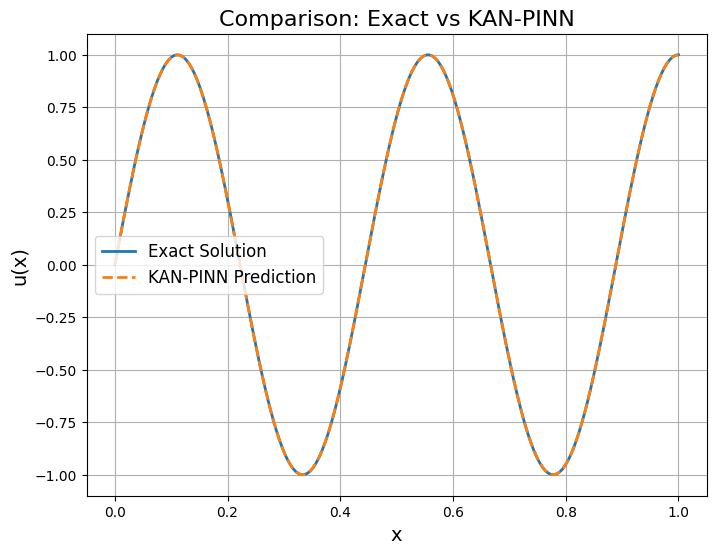

Relative error(MAE) = 1.334e-05.
MSE = 4.169e-08.


In [ ]:
# %% Import modules
import numpy as np
import jax
import jax.numpy as jnp
from jax import vjp, jit, grad
from jax.example_libraries import optimizers
from functools import partial
import time
import matplotlib.pyplot as plt

# %% Chebyshev helper functions
def chebyshev_recursive(x, degree):
    if degree == 0:
        return x * 0 + 1
    elif degree == 1:
        return x
    else:
        T_n_minus_1 = x
        T_n_minus_2 = x * 0 + 1
        for n in range(2, degree + 1):
            T_n = 2 * x * T_n_minus_1 - T_n_minus_2
            T_n_minus_2, T_n_minus_1 = T_n_minus_1, T_n
        return T_n

def chebyshev_cosine(x, degree):
    return jnp.cos(degree * jnp.arccos(x))

# %% KAN initialization
def init_params_kan2(layers, degree):
    keys = jax.random.split(jax.random.PRNGKey(123), len(layers) - 1)
    params = []
    for key, n_in, n_out in zip(keys[:-1], layers[:-2], layers[1:-1]):
        W = jax.random.normal(key, shape=(n_in, n_out, degree + 1)) / jnp.sqrt(n_in * (degree + 1))
        g = jax.random.normal(key, shape=(n_out,))
        params.append({'W': W, 'g': g})
    W = jax.random.normal(keys[-1], shape=(layers[-2], layers[-1])) / jnp.sqrt(layers[-2])
    B = jax.random.normal(keys[-1], shape=(layers[-1],))
    params.append({'W': W, 'B': B})
    return params

# %% KAN forward pass
def fwd_kan(params, t, activation=jax.nn.tanh, use_cosine=False):
    # t = 0.01 * t
    t = activation(t)
    X = t.reshape((-1, 1))
    *hidden, last = params
    for layer in hidden:
        # X = activation(X)
        cheby_coeffs = layer['W']
        degree = cheby_coeffs.shape[2] - 1
        X_stack = jnp.stack([chebyshev_recursive(X, d) for d in range(degree + 1)], axis=-1)
        X = jnp.einsum("bid,iod->bo", X_stack, cheby_coeffs)
        X = layer['g'] * X
        X = activation(X)
    return X @ last['W'] + last['B']

# %% helper functions
def vgrad(f, x):
    y, vjp_fn = vjp(f, x)
    return vjp_fn(jnp.ones(y.shape))[0]

# Ground truth and forcing term
def exact_solution(x):
    return jnp.sin(9 * jnp.pi / 2 * x)

def forcing_term(x):
    coef = -(9 * jnp.pi / 2) ** 2 - 1
    return coef * jnp.sin(9 * jnp.pi / 2 * x)

# %% Define KAN-based PINN model
class PINN_KAN:
    def __init__(self, layers, degree, weight, activation=jax.nn.tanh, use_cosine=False):
        self.degree = degree
        self.activation = activation
        self.use_cosine = use_cosine
        self.weight_eqn, self.weight_bc = weight
        self.params = init_params_kan2(layers, degree)
        self.opt_init, self.opt_update, self.get_params = optimizers.adam(1e-3)
        self.opt_state = self.opt_init(self.params)

    @partial(jit, static_argnums=(0,))
    def equation(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        fu = lambda x: pinn(x)
        dudx = lambda x: vgrad(fu, x)
        d2udx2 = lambda x: vgrad(dudx, x)
        u = fu(X)
        u_xx = d2udx2(X)
        f = forcing_term(X)
        return u_xx - u - f

    @partial(jit, static_argnums=(0,))
    def forward(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        return pinn(X)

    @partial(jit, static_argnums=(0,))
    def loss_component(self, params, X_res, X_bc):
        x_bc, y_bc = X_bc
        eq1 = self.equation(params, X_res)
        loss_res = jnp.mean(eq1 ** 2)
        x_bc_l, x_bc_r = x_bc
        u_l_pred = self.forward(params, x_bc_l)
        u_r_pred = self.forward(params, x_bc_r)
        u_l, u_r = y_bc
        loss_bc = jnp.mean((u_l - u_l_pred) ** 2 + (u_r - u_r_pred) ** 2)
        return loss_res, loss_bc

    def loss(self, params, X_res, X_bc):
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return self.weight_eqn * loss_res + self.weight_bc * loss_bc

    @partial(jit, static_argnums=(0,))
    def update(self, i, opt_state, X_res, X_bc):
        params = self.get_params(opt_state)
        next_opt_state = self.opt_update(i, grad(self.loss)(params, X_res, X_bc), opt_state)
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return next_opt_state, (loss_res, loss_bc)

# %% prepare data
N = 1000
X = np.random.uniform(0, 1, size=(N,1))
X_res = jnp.array(X)

X_bc = (
    (jnp.array(0.0).reshape(-1,1), jnp.array(1.0).reshape(-1,1)),
    (jnp.array(0.0).reshape(-1,1), jnp.array(1.0).reshape(-1,1)),
)

# %% training
layers = [1, 50, 50, 1]
degree = 3
model = PINN_KAN(layers, degree, weight=(1,1))
N_epochs = 20000
Y_result = []

for epoch in range(1, N_epochs+1):
    start = time.time()
    model.opt_state, losses = model.update(epoch, model.opt_state, X_res, X_bc)
    model.params = model.get_params(model.opt_state)
    end = time.time()
    if epoch % 100 == 0:
        loss_res, loss_bc = losses
        print(f"Epoch: {epoch}, Time: {end-start:.2f}s, Loss_eqn={loss_res:.3e}, Loss_bc={loss_bc:.3e}")
        Y = model.forward(model.params, X_res)
        Y_result.append(Y)

# %% Compare and plot
X_plot = np.linspace(0, 1, 200).reshape(-1, 1)
X_plot_jax = jnp.array(X_plot)

Y_pred_plot = model.forward(model.params, X_plot_jax).flatten()
Y_true_plot = exact_solution(X_plot_jax).flatten()

plt.figure(figsize=(8,6))
plt.plot(X_plot, Y_true_plot, label="Exact Solution", linewidth=2)
plt.plot(X_plot, Y_pred_plot, '--', label="KAN-PINN Prediction", linewidth=2)
plt.xlabel('x', fontsize=14)
plt.ylabel('u(x)', fontsize=14)
plt.title('Comparison: Exact vs KAN-PINN', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# %% Relative error
Y_true = exact_solution(X_res).flatten()
Y_pred = Y_result[-1].flatten()
err = np.mean((Y_pred - Y_true)**2) / (np.mean(Y_true)**2)
print(f"Relative error(MAE) = {err:.3e}.")

err = np.mean((Y_pred - Y_true)**2)# / (np.mean(Y_true)**2)
print(f"MSE = {err:.3e}.")


Epoch: 100, Time: 0.00s, Loss_eqn=2.569e+02, Loss_bc=2.674e+00
Epoch: 200, Time: 0.00s, Loss_eqn=5.806e-01, Loss_bc=4.529e+00
Epoch: 300, Time: 0.00s, Loss_eqn=3.442e-01, Loss_bc=2.343e+00
Epoch: 400, Time: 0.00s, Loss_eqn=2.487e-01, Loss_bc=9.393e-01
Epoch: 500, Time: 0.00s, Loss_eqn=1.266e-01, Loss_bc=3.852e-01
Epoch: 600, Time: 0.00s, Loss_eqn=2.895e+00, Loss_bc=1.769e-01
Epoch: 700, Time: 0.00s, Loss_eqn=1.020e+00, Loss_bc=7.477e-02
Epoch: 800, Time: 0.00s, Loss_eqn=3.663e+00, Loss_bc=2.560e-02
Epoch: 900, Time: 0.00s, Loss_eqn=1.845e-01, Loss_bc=1.255e-02
Epoch: 1000, Time: 0.00s, Loss_eqn=8.859e-02, Loss_bc=5.402e-03
Epoch: 1100, Time: 0.00s, Loss_eqn=6.068e-02, Loss_bc=2.244e-03
Epoch: 1200, Time: 0.00s, Loss_eqn=7.818e-01, Loss_bc=1.159e-03
Epoch: 1300, Time: 0.00s, Loss_eqn=5.274e-02, Loss_bc=3.544e-04
Epoch: 1400, Time: 0.00s, Loss_eqn=6.391e-01, Loss_bc=2.817e-04
Epoch: 1500, Time: 0.00s, Loss_eqn=2.089e-02, Loss_bc=1.279e-04
Epoch: 1600, Time: 0.00s, Loss_eqn=3.044e-02, Los

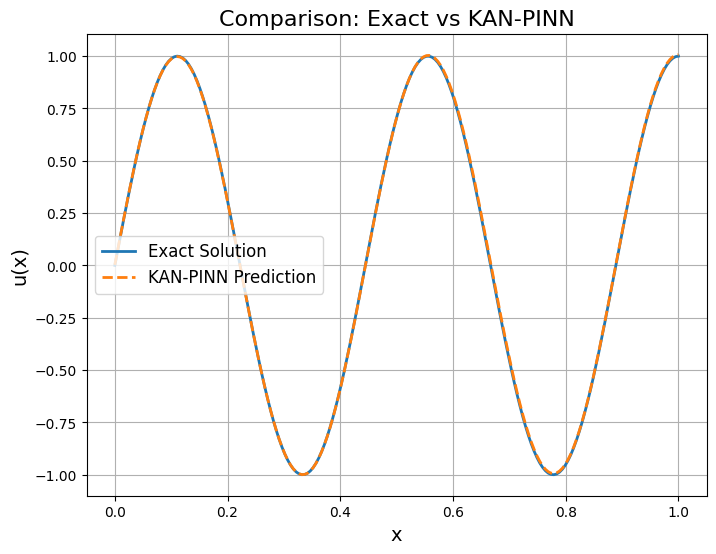

Relative error(MAE) = 1.186e-02.
MSE = 2.803e-05.


In [ ]:
# %% Import modules
import numpy as np
import jax
import jax.numpy as jnp
from jax import vjp, jit, grad
from jax.example_libraries import optimizers
from functools import partial
import time
import matplotlib.pyplot as plt

# %% Chebyshev helper functions
def chebyshev_recursive(x, degree):
    if degree == 0:
        return x * 0 + 1
    elif degree == 1:
        return x
    else:
        T_n_minus_1 = x
        T_n_minus_2 = x * 0 + 1
        for n in range(2, degree + 1):
            T_n = 2 * x * T_n_minus_1 - T_n_minus_2
            T_n_minus_2, T_n_minus_1 = T_n_minus_1, T_n
        return T_n

def chebyshev_cosine(x, degree):
    return jnp.cos(degree * jnp.arccos(x))

# %% KAN initialization
def init_params_kan2(layers, degree):
    keys = jax.random.split(jax.random.PRNGKey(123), len(layers) - 1)
    params = []
    for key, n_in, n_out in zip(keys[:-1], layers[:-2], layers[1:-1]):
        W = jax.random.normal(key, shape=(n_in, n_out, degree + 1)) / jnp.sqrt(n_in * (degree + 1))
        g = jax.random.normal(key, shape=(n_out,))
        params.append({'W': W, 'g': g})
    W = jax.random.normal(keys[-1], shape=(layers[-2], layers[-1])) / jnp.sqrt(layers[-2])
    B = jax.random.normal(keys[-1], shape=(layers[-1],))
    params.append({'W': W, 'B': B})
    return params

# %% KAN forward pass
def fwd_kan(params, t, activation=jax.nn.tanh, use_cosine=False):
    # t = 0.01 * t
    # t = activation(t)
    X = t.reshape((-1, 1))
    *hidden, last = params
    for layer in hidden:
        X = activation(X)
        cheby_coeffs = layer['W']
        degree = cheby_coeffs.shape[2] - 1
        X_stack = jnp.stack([chebyshev_recursive(X, d) for d in range(degree + 1)], axis=-1)
        X = jnp.einsum("bid,iod->bo", X_stack, cheby_coeffs)
        # X = layer['g'] * X
        X = activation(X)
    return X @ last['W'] + last['B']

# %% helper functions
def vgrad(f, x):
    y, vjp_fn = vjp(f, x)
    return vjp_fn(jnp.ones(y.shape))[0]

# Ground truth and forcing term
def exact_solution(x):
    return jnp.sin(9 * jnp.pi / 2 * x)

def forcing_term(x):
    coef = -(9 * jnp.pi / 2) ** 2 - 1
    return coef * jnp.sin(9 * jnp.pi / 2 * x)

# %% Define KAN-based PINN model
class PINN_KAN:
    def __init__(self, layers, degree, weight, activation=jax.nn.tanh, use_cosine=False):
        self.degree = degree
        self.activation = activation
        self.use_cosine = use_cosine
        self.weight_eqn, self.weight_bc = weight
        self.params = init_params_kan2(layers, degree)
        self.opt_init, self.opt_update, self.get_params = optimizers.adam(1e-3)
        self.opt_state = self.opt_init(self.params)

    @partial(jit, static_argnums=(0,))
    def equation(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        fu = lambda x: pinn(x)
        dudx = lambda x: vgrad(fu, x)
        d2udx2 = lambda x: vgrad(dudx, x)
        u = fu(X)
        u_xx = d2udx2(X)
        f = forcing_term(X)
        return u_xx - u - f

    @partial(jit, static_argnums=(0,))
    def forward(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        return pinn(X)

    @partial(jit, static_argnums=(0,))
    def loss_component(self, params, X_res, X_bc):
        x_bc, y_bc = X_bc
        eq1 = self.equation(params, X_res)
        loss_res = jnp.mean(eq1 ** 2)
        x_bc_l, x_bc_r = x_bc
        u_l_pred = self.forward(params, x_bc_l)
        u_r_pred = self.forward(params, x_bc_r)
        u_l, u_r = y_bc
        loss_bc = jnp.mean((u_l - u_l_pred) ** 2 + (u_r - u_r_pred) ** 2)
        return loss_res, loss_bc

    def loss(self, params, X_res, X_bc):
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return self.weight_eqn * loss_res + self.weight_bc * loss_bc

    @partial(jit, static_argnums=(0,))
    def update(self, i, opt_state, X_res, X_bc):
        params = self.get_params(opt_state)
        next_opt_state = self.opt_update(i, grad(self.loss)(params, X_res, X_bc), opt_state)
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return next_opt_state, (loss_res, loss_bc)

# %% prepare data
N = 1000
X = np.random.uniform(0, 1, size=(N,1))
X_res = jnp.array(X)

X_bc = (
    (jnp.array(0.0).reshape(-1,1), jnp.array(1.0).reshape(-1,1)),
    (jnp.array(0.0).reshape(-1,1), jnp.array(1.0).reshape(-1,1)),
)

# %% training
layers = [1, 50, 50, 1]
degree = 3
model = PINN_KAN(layers, degree, weight=(1,1))
N_epochs = 20000
Y_result = []

for epoch in range(1, N_epochs+1):
    start = time.time()
    model.opt_state, losses = model.update(epoch, model.opt_state, X_res, X_bc)
    model.params = model.get_params(model.opt_state)
    end = time.time()
    if epoch % 100 == 0:
        loss_res, loss_bc = losses
        print(f"Epoch: {epoch}, Time: {end-start:.2f}s, Loss_eqn={loss_res:.3e}, Loss_bc={loss_bc:.3e}")
        Y = model.forward(model.params, X_res)
        Y_result.append(Y)

# %% Compare and plot
X_plot = np.linspace(0, 1, 200).reshape(-1, 1)
X_plot_jax = jnp.array(X_plot)

Y_pred_plot = model.forward(model.params, X_plot_jax).flatten()
Y_true_plot = exact_solution(X_plot_jax).flatten()

plt.figure(figsize=(8,6))
plt.plot(X_plot, Y_true_plot, label="Exact Solution", linewidth=2)
plt.plot(X_plot, Y_pred_plot, '--', label="KAN-PINN Prediction", linewidth=2)
plt.xlabel('x', fontsize=14)
plt.ylabel('u(x)', fontsize=14)
plt.title('Comparison: Exact vs KAN-PINN', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# %% Relative error
Y_true = exact_solution(X_res).flatten()
Y_pred = Y_result[-1].flatten()
err = np.mean((Y_pred - Y_true)**2) / (np.mean(Y_true)**2)
print(f"Relative error(MAE) = {err:.3e}.")

err = np.mean((Y_pred - Y_true)**2)# / (np.mean(Y_true)**2)
print(f"MSE = {err:.3e}.")


Epoch: 100, Time: 0.00s, Loss_eqn=3.219e+00, Loss_bc=1.121e+00
Epoch: 200, Time: 0.00s, Loss_eqn=9.656e-01, Loss_bc=3.681e-01
Epoch: 300, Time: 0.00s, Loss_eqn=7.206e-01, Loss_bc=5.552e-02
Epoch: 400, Time: 0.00s, Loss_eqn=5.988e-01, Loss_bc=5.401e-03
Epoch: 500, Time: 0.00s, Loss_eqn=5.208e-01, Loss_bc=2.608e-04
Epoch: 600, Time: 0.00s, Loss_eqn=4.582e-01, Loss_bc=6.802e-05
Epoch: 700, Time: 0.00s, Loss_eqn=4.029e-01, Loss_bc=1.022e-04
Epoch: 800, Time: 0.00s, Loss_eqn=3.526e-01, Loss_bc=9.846e-05
Epoch: 900, Time: 0.00s, Loss_eqn=3.064e-01, Loss_bc=8.741e-05
Epoch: 1000, Time: 0.00s, Loss_eqn=2.641e-01, Loss_bc=7.839e-05
Epoch: 1100, Time: 0.00s, Loss_eqn=2.259e-01, Loss_bc=7.147e-05
Epoch: 1200, Time: 0.00s, Loss_eqn=1.916e-01, Loss_bc=6.552e-05
Epoch: 1300, Time: 0.00s, Loss_eqn=1.614e-01, Loss_bc=5.963e-05
Epoch: 1400, Time: 0.00s, Loss_eqn=1.352e-01, Loss_bc=5.375e-05
Epoch: 1500, Time: 0.00s, Loss_eqn=1.129e-01, Loss_bc=4.765e-05
Epoch: 1600, Time: 0.00s, Loss_eqn=9.419e-02, Los

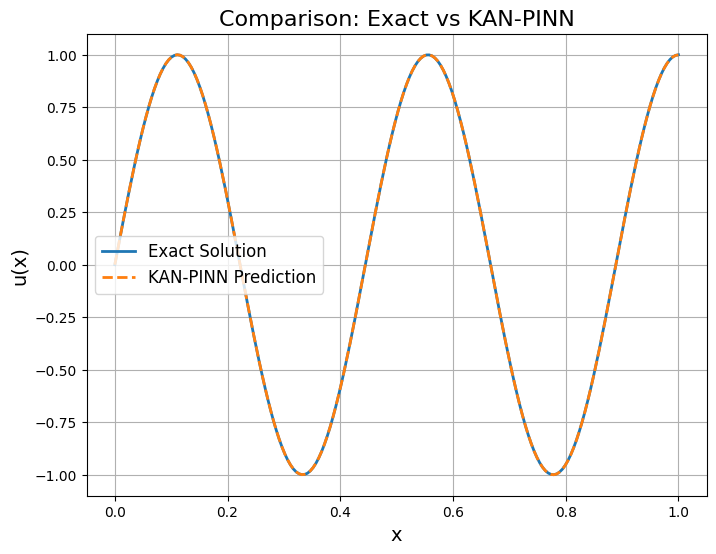

Relative error(MAE) = 2.037e-05.
MSE = 6.515e-08.


In [ ]:
# %% Import modules
import numpy as np
import jax
import jax.numpy as jnp
from jax import vjp, jit, grad
from jax.example_libraries import optimizers
from functools import partial
import time
import matplotlib.pyplot as plt

# %% Chebyshev helper functions
def chebyshev_recursive(x, degree):
    if degree == 0:
        return x * 0 + 1
    elif degree == 1:
        return x
    else:
        T_n_minus_1 = x
        T_n_minus_2 = x * 0 + 1
        for n in range(2, degree + 1):
            T_n = 2 * x * T_n_minus_1 - T_n_minus_2
            T_n_minus_2, T_n_minus_1 = T_n_minus_1, T_n
        return T_n

def chebyshev_cosine(x, degree):
    return jnp.cos(degree * jnp.arccos(x))

# %% KAN initialization
def init_params_kan2(layers, degree):
    keys = jax.random.split(jax.random.PRNGKey(123), len(layers) - 1)
    params = []
    for key, n_in, n_out in zip(keys[:-1], layers[:-2], layers[1:-1]):
        W = jax.random.normal(key, shape=(n_in, n_out, degree + 1)) / jnp.sqrt(n_in * (degree + 1))
        g = jax.random.normal(key, shape=(n_out,))
        params.append({'W': W, 'g': g})
    W = jax.random.normal(keys[-1], shape=(layers[-2], layers[-1])) / jnp.sqrt(layers[-2])
    B = jax.random.normal(keys[-1], shape=(layers[-1],))
    params.append({'W': W, 'B': B})
    return params

# %% KAN forward pass
def fwd_kan(params, t, activation=jax.nn.tanh, use_cosine=False):
    # t = 0.01 * t
    # t = activation(t)
    X = t.reshape((-1, 1))
    *hidden, last = params
    for layer in hidden:
        X = activation(X)
        cheby_coeffs = layer['W']
        degree = cheby_coeffs.shape[2] - 1
        if use_cosine:
            X_stack = jnp.stack([chebyshev_cosine(X, d) for d in range(degree + 1)], axis=-1)
        else:
            X_stack = jnp.stack([chebyshev_recursive(X, d) for d in range(degree + 1)], axis=-1)
        X = jnp.einsum("bid,iod->bo", X_stack, cheby_coeffs)
        # X = layer['g'] * X
        # X = activation(X)
    return X @ last['W'] + last['B']

# %% helper functions
def vgrad(f, x):
    y, vjp_fn = vjp(f, x)
    return vjp_fn(jnp.ones(y.shape))[0]

# Ground truth and forcing term
def exact_solution(x):
    return jnp.sin(9 * jnp.pi / 2 * x)

def forcing_term(x):
    coef = -(9 * jnp.pi / 2) ** 2 - 1
    return coef * jnp.sin(9 * jnp.pi / 2 * x)

# %% Define KAN-based PINN model
class PINN_KAN:
    def __init__(self, layers, degree, weight, activation=jax.nn.tanh, use_cosine=False):
        self.degree = degree
        self.activation = activation
        self.use_cosine = use_cosine
        self.weight_eqn, self.weight_bc = weight
        self.params = init_params_kan2(layers, degree)
        self.opt_init, self.opt_update, self.get_params = optimizers.adam(1e-3)
        self.opt_state = self.opt_init(self.params)

    @partial(jit, static_argnums=(0,))
    def equation(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        fu = lambda x: pinn(x)
        dudx = lambda x: vgrad(fu, x)
        d2udx2 = lambda x: vgrad(dudx, x)
        u = fu(X)
        u_xx = d2udx2(X)
        f = forcing_term(X)
        return u_xx - u - f

    @partial(jit, static_argnums=(0,))
    def forward(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        return pinn(X)

    @partial(jit, static_argnums=(0,))
    def loss_component(self, params, X_res, X_bc):
        x_bc, y_bc = X_bc
        eq1 = self.equation(params, X_res)
        loss_res = jnp.mean(eq1 ** 2)
        x_bc_l, x_bc_r = x_bc
        u_l_pred = self.forward(params, x_bc_l)
        u_r_pred = self.forward(params, x_bc_r)
        u_l, u_r = y_bc
        loss_bc = jnp.mean((u_l - u_l_pred) ** 2 + (u_r - u_r_pred) ** 2)
        return loss_res, loss_bc

    def loss(self, params, X_res, X_bc):
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return self.weight_eqn * loss_res + self.weight_bc * loss_bc

    @partial(jit, static_argnums=(0,))
    def update(self, i, opt_state, X_res, X_bc):
        params = self.get_params(opt_state)
        next_opt_state = self.opt_update(i, grad(self.loss)(params, X_res, X_bc), opt_state)
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return next_opt_state, (loss_res, loss_bc)

# %% prepare data
N = 1000
X = np.random.uniform(0, 1, size=(N,1))
X_res = jnp.array(X)

X_bc = (
    (jnp.array(0.0).reshape(-1,1), jnp.array(1.0).reshape(-1,1)),
    (jnp.array(0.0).reshape(-1,1), jnp.array(1.0).reshape(-1,1)),
)

# %% training
layers = [1, 50, 50, 1]
degree = 5
model = PINN_KAN(layers, degree, weight=(1,1))
N_epochs = 20000
Y_result = []

for epoch in range(1, N_epochs+1):
    start = time.time()
    model.opt_state, losses = model.update(epoch, model.opt_state, X_res, X_bc)
    model.params = model.get_params(model.opt_state)
    end = time.time()
    if epoch % 100 == 0:
        loss_res, loss_bc = losses
        print(f"Epoch: {epoch}, Time: {end-start:.2f}s, Loss_eqn={loss_res:.3e}, Loss_bc={loss_bc:.3e}")
        Y = model.forward(model.params, X_res)
        Y_result.append(Y)

# %% Compare and plot
X_plot = np.linspace(0, 1, 200).reshape(-1, 1)
X_plot_jax = jnp.array(X_plot)

Y_pred_plot = model.forward(model.params, X_plot_jax).flatten()
Y_true_plot = exact_solution(X_plot_jax).flatten()

plt.figure(figsize=(8,6))
plt.plot(X_plot, Y_true_plot, label="Exact Solution", linewidth=2)
plt.plot(X_plot, Y_pred_plot, '--', label="KAN-PINN Prediction", linewidth=2)
plt.xlabel('x', fontsize=14)
plt.ylabel('u(x)', fontsize=14)
plt.title('Comparison: Exact vs KAN-PINN', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# %% Relative error
Y_true = exact_solution(X_res).flatten()
Y_pred = Y_result[-1].flatten()
err = np.mean((Y_pred - Y_true)**2) / (np.mean(Y_true)**2)
print(f"Relative error(MAE) = {err:.3e}.")

err = np.mean((Y_pred - Y_true)**2)# / (np.mean(Y_true)**2)
print(f"MSE = {err:.3e}.")


Epoch: 100, Time: 0.00s, Loss_eqn=1.478e+03, Loss_bc=3.143e+00
Epoch: 200, Time: 0.00s, Loss_eqn=4.578e+02, Loss_bc=1.875e+01
Epoch: 300, Time: 0.00s, Loss_eqn=1.713e+02, Loss_bc=1.547e+01
Epoch: 400, Time: 0.00s, Loss_eqn=6.447e+01, Loss_bc=7.357e+00
Epoch: 500, Time: 0.00s, Loss_eqn=2.464e+01, Loss_bc=3.595e+00
Epoch: 600, Time: 0.00s, Loss_eqn=1.107e+01, Loss_bc=2.361e+00
Epoch: 700, Time: 0.00s, Loss_eqn=6.056e+00, Loss_bc=1.923e+00
Epoch: 800, Time: 0.00s, Loss_eqn=3.909e+00, Loss_bc=1.616e+00
Epoch: 900, Time: 0.00s, Loss_eqn=2.891e+00, Loss_bc=1.303e+00
Epoch: 1000, Time: 0.00s, Loss_eqn=2.358e+00, Loss_bc=9.986e-01
Epoch: 1100, Time: 0.00s, Loss_eqn=2.044e+00, Loss_bc=7.296e-01
Epoch: 1200, Time: 0.00s, Loss_eqn=1.840e+00, Loss_bc=5.113e-01
Epoch: 1300, Time: 0.00s, Loss_eqn=1.696e+00, Loss_bc=3.450e-01
Epoch: 1400, Time: 0.00s, Loss_eqn=1.590e+00, Loss_bc=2.247e-01
Epoch: 1500, Time: 0.00s, Loss_eqn=1.509e+00, Loss_bc=1.412e-01
Epoch: 1600, Time: 0.00s, Loss_eqn=1.445e+00, Los

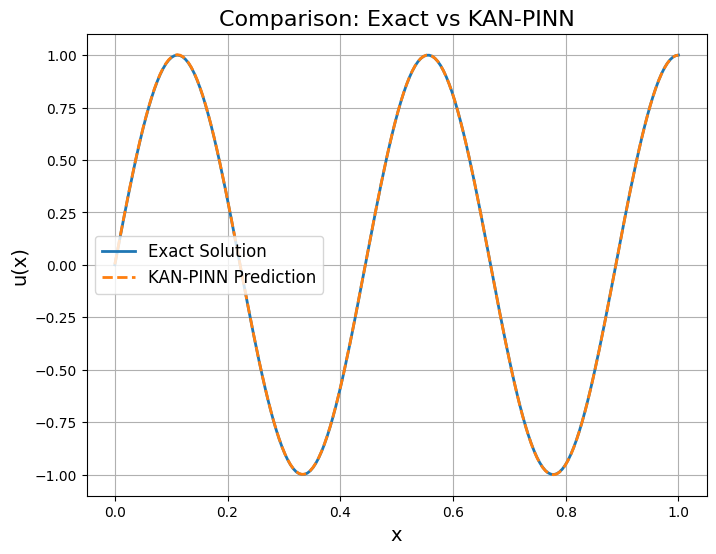

Relative error(MAE) = 2.406e-04.
MSE = 1.175e-06.


In [ ]:
# %% Import modules
import numpy as np
import jax
import jax.numpy as jnp
from jax import vjp, jit, grad
from jax.example_libraries import optimizers
from functools import partial
import time
import matplotlib.pyplot as plt

# %% Chebyshev helper functions
def chebyshev_recursive(x, degree):
    if degree == 0:
        return x * 0 + 1
    elif degree == 1:
        return x
    else:
        T_n_minus_1 = x
        T_n_minus_2 = x * 0 + 1
        for n in range(2, degree + 1):
            T_n = 2 * x * T_n_minus_1 - T_n_minus_2
            T_n_minus_2, T_n_minus_1 = T_n_minus_1, T_n
        return T_n

def chebyshev_cosine(x, degree):
    return jnp.cos(degree * jnp.arccos(x))

# %% KAN initialization
def init_params_kan2(layers, degree):
    keys = jax.random.split(jax.random.PRNGKey(123), len(layers) - 1)
    params = []
    for key, n_in, n_out in zip(keys[:-1], layers[:-2], layers[1:-1]):
        W = jax.random.normal(key, shape=(n_in, n_out, degree + 1)) / jnp.sqrt(n_in * (degree + 1))
        g = jax.random.normal(key, shape=(n_out,))
        params.append({'W': W, 'g': g})
    W = jax.random.normal(keys[-1], shape=(layers[-2], layers[-1])) / jnp.sqrt(layers[-2])
    B = jax.random.normal(keys[-1], shape=(layers[-1],))
    params.append({'W': W, 'B': B})
    return params

# %% KAN forward pass
def fwd_kan(params, t, activation=jax.nn.tanh, use_cosine=False):
    # t = 0.01 * t
    # t = activation(t)
    X = t.reshape((-1, 1))
    *hidden, last = params
    for layer in hidden:
        X = activation(X)
        cheby_coeffs = layer['W']
        degree = cheby_coeffs.shape[2] - 1
        if use_cosine:
            X_stack = jnp.stack([chebyshev_cosine(X, d) for d in range(degree + 1)], axis=-1)
        else:
            X_stack = jnp.stack([chebyshev_recursive(X, d) for d in range(degree + 1)], axis=-1)
        X = jnp.einsum("bid,iod->bo", X_stack, cheby_coeffs)
        # X = layer['g'] * X
        # X = activation(X)
    return X @ last['W'] + last['B']

# %% helper functions
def vgrad(f, x):
    y, vjp_fn = vjp(f, x)
    return vjp_fn(jnp.ones(y.shape))[0]

# Ground truth and forcing term
def exact_solution(x):
    return jnp.sin(9 * jnp.pi / 2 * x)

def forcing_term(x):
    coef = -(9 * jnp.pi / 2) ** 2 - 1
    return coef * jnp.sin(9 * jnp.pi / 2 * x)

# %% Define KAN-based PINN model
class PINN_KAN:
    def __init__(self, layers, degree, weight, activation=jax.nn.tanh, use_cosine=False):
        self.degree = degree
        self.activation = activation
        self.use_cosine = use_cosine
        self.weight_eqn, self.weight_bc = weight
        self.params = init_params_kan2(layers, degree)
        self.opt_init, self.opt_update, self.get_params = optimizers.adam(1e-4)
        self.opt_state = self.opt_init(self.params)

    @partial(jit, static_argnums=(0,))
    def equation(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        fu = lambda x: pinn(x)
        dudx = lambda x: vgrad(fu, x)
        d2udx2 = lambda x: vgrad(dudx, x)
        u = fu(X)
        u_xx = d2udx2(X)
        f = forcing_term(X)
        return u_xx - u - f

    @partial(jit, static_argnums=(0,))
    def forward(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        return pinn(X)

    @partial(jit, static_argnums=(0,))
    def loss_component(self, params, X_res, X_bc):
        x_bc, y_bc = X_bc
        eq1 = self.equation(params, X_res)
        loss_res = jnp.mean(eq1 ** 2)
        x_bc_l, x_bc_r = x_bc
        u_l_pred = self.forward(params, x_bc_l)
        u_r_pred = self.forward(params, x_bc_r)
        u_l, u_r = y_bc
        loss_bc = jnp.mean((u_l - u_l_pred) ** 2 + (u_r - u_r_pred) ** 2)
        return loss_res, loss_bc

    def loss(self, params, X_res, X_bc):
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return self.weight_eqn * loss_res + self.weight_bc * loss_bc

    @partial(jit, static_argnums=(0,))
    def update(self, i, opt_state, X_res, X_bc):
        params = self.get_params(opt_state)
        next_opt_state = self.opt_update(i, grad(self.loss)(params, X_res, X_bc), opt_state)
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return next_opt_state, (loss_res, loss_bc)

# %% prepare data
N = 1000
X = np.random.uniform(0, 1, size=(N,1))
X_res = jnp.array(X)

X_bc = (
    (jnp.array(0.0).reshape(-1,1), jnp.array(1.0).reshape(-1,1)),
    (jnp.array(0.0).reshape(-1,1), jnp.array(1.0).reshape(-1,1)),
)

# %% training
layers = [1, 50, 50, 1]
degree = 5
model = PINN_KAN(layers, degree, weight=(1,1))
N_epochs = 20000
Y_result = []

for epoch in range(1, N_epochs+1):
    start = time.time()
    model.opt_state, losses = model.update(epoch, model.opt_state, X_res, X_bc)
    model.params = model.get_params(model.opt_state)
    end = time.time()
    if epoch % 100 == 0:
        loss_res, loss_bc = losses
        print(f"Epoch: {epoch}, Time: {end-start:.2f}s, Loss_eqn={loss_res:.3e}, Loss_bc={loss_bc:.3e}")
        Y = model.forward(model.params, X_res)
        Y_result.append(Y)

# %% Compare and plot
X_plot = np.linspace(0, 1, 200).reshape(-1, 1)
X_plot_jax = jnp.array(X_plot)

Y_pred_plot = model.forward(model.params, X_plot_jax).flatten()
Y_true_plot = exact_solution(X_plot_jax).flatten()

plt.figure(figsize=(8,6))
plt.plot(X_plot, Y_true_plot, label="Exact Solution", linewidth=2)
plt.plot(X_plot, Y_pred_plot, '--', label="KAN-PINN Prediction", linewidth=2)
plt.xlabel('x', fontsize=14)
plt.ylabel('u(x)', fontsize=14)
plt.title('Comparison: Exact vs KAN-PINN', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# %% Relative error
Y_true = exact_solution(X_res).flatten()
Y_pred = Y_result[-1].flatten()
err = np.mean((Y_pred - Y_true)**2) / (np.mean(Y_true)**2)
print(f"Relative error(MAE) = {err:.3e}.")

err = np.mean((Y_pred - Y_true)**2)# / (np.mean(Y_true)**2)
print(f"MSE = {err:.3e}.")


Epoch: 100, Time: 0.00s, Loss_eqn=2.047e+04, Loss_bc=4.494e+01
Epoch: 200, Time: 0.00s, Loss_eqn=2.046e+04, Loss_bc=4.902e+01
Epoch: 300, Time: 0.00s, Loss_eqn=2.046e+04, Loss_bc=4.895e+01
Epoch: 400, Time: 0.00s, Loss_eqn=2.046e+04, Loss_bc=4.879e+01
Epoch: 500, Time: 0.00s, Loss_eqn=2.046e+04, Loss_bc=4.682e+01
Epoch: 600, Time: 0.00s, Loss_eqn=1.969e+04, Loss_bc=5.421e+01
Epoch: 700, Time: 0.00s, Loss_eqn=7.878e+03, Loss_bc=1.954e+02
Epoch: 800, Time: 0.00s, Loss_eqn=4.222e+02, Loss_bc=2.362e+02
Epoch: 900, Time: 0.00s, Loss_eqn=1.842e+02, Loss_bc=1.966e+02
Epoch: 1000, Time: 0.00s, Loss_eqn=1.241e+02, Loss_bc=1.255e+02
Epoch: 1100, Time: 0.00s, Loss_eqn=6.651e+01, Loss_bc=8.709e+01
Epoch: 1200, Time: 0.00s, Loss_eqn=1.143e+02, Loss_bc=5.884e+01
Epoch: 1300, Time: 0.00s, Loss_eqn=8.784e+00, Loss_bc=4.097e+01
Epoch: 1400, Time: 0.00s, Loss_eqn=6.174e+01, Loss_bc=2.597e+01
Epoch: 1500, Time: 0.00s, Loss_eqn=4.908e+01, Loss_bc=1.341e+01
Epoch: 1600, Time: 0.00s, Loss_eqn=2.155e+00, Los

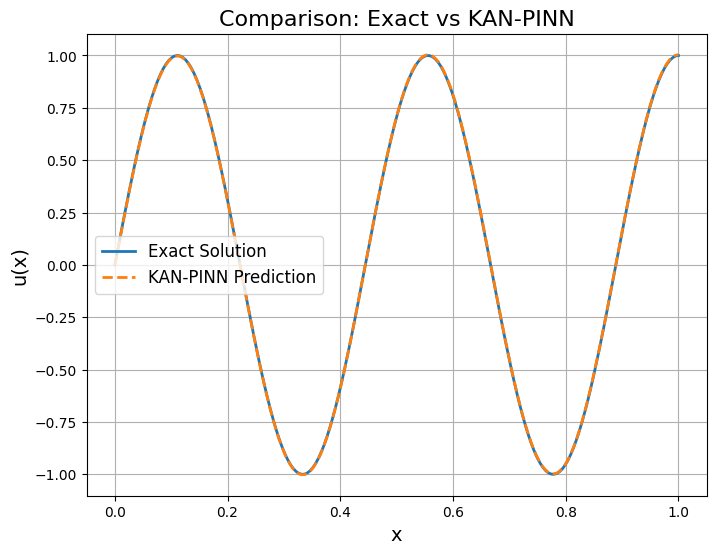

Relative error(MAE) = 1.140e-03.
MSE = 6.595e-06.


In [ ]:
# %% Import modules
import numpy as np
import jax
import jax.numpy as jnp
from jax import vjp, jit, grad
from jax.example_libraries import optimizers
from functools import partial
import time
import matplotlib.pyplot as plt

# %% Chebyshev helper functions
def chebyshev_recursive(x, degree):
    if degree == 0:
        return x * 0 + 1
    elif degree == 1:
        return x
    else:
        T_n_minus_1 = x
        T_n_minus_2 = x * 0 + 1
        for n in range(2, degree + 1):
            T_n = 2 * x * T_n_minus_1 - T_n_minus_2
            T_n_minus_2, T_n_minus_1 = T_n_minus_1, T_n
        return T_n

def chebyshev_cosine(x, degree):
    return jnp.cos(degree * jnp.arccos(x))

# %% KAN initialization
def init_params_kan2(layers, degree):
    keys = jax.random.split(jax.random.PRNGKey(123), len(layers) - 1)
    params = []
    for key, n_in, n_out in zip(keys[:-1], layers[:-2], layers[1:-1]):
        W = jax.random.normal(key, shape=(n_in, n_out, degree + 1)) / jnp.sqrt(n_in * (degree + 1))
        g = jax.random.normal(key, shape=(n_out,))
        params.append({'W': W, 'g': g})
    W = jax.random.normal(keys[-1], shape=(layers[-2], layers[-1])) / jnp.sqrt(layers[-2])
    B = jax.random.normal(keys[-1], shape=(layers[-1],))
    params.append({'W': W, 'B': B})
    return params

# %% KAN forward pass
def fwd_kan(params, t, activation=jax.nn.tanh, use_cosine=False):
    t = 0.01 * t
    X = t.reshape((-1, 1))
    *hidden, last = params
    for layer in hidden:
        cheby_coeffs = layer['W']
        degree = cheby_coeffs.shape[2] - 1
        if use_cosine:
            X_stack = jnp.stack([chebyshev_cosine(X, d) for d in range(degree + 1)], axis=-1)
        else:
            X_stack = jnp.stack([chebyshev_recursive(X, d) for d in range(degree + 1)], axis=-1)
        X = jnp.einsum("bid,iod->bo", X_stack, cheby_coeffs)
        X = layer['g'] * X
        X = activation(X)
    return X @ last['W'] + last['B']

# %% helper functions
def vgrad(f, x):
    y, vjp_fn = vjp(f, x)
    return vjp_fn(jnp.ones(y.shape))[0]

# Ground truth and forcing term
def exact_solution(x):
    return jnp.sin(9 * jnp.pi / 2 * x)

def forcing_term(x):
    coef = -(9 * jnp.pi / 2) ** 2 - 1
    return coef * jnp.sin(9 * jnp.pi / 2 * x)

# %% Define KAN-based PINN model
class PINN_KAN:
    def __init__(self, layers, degree, weight, activation=jax.nn.tanh, use_cosine=False):
        self.degree = degree
        self.activation = activation
        self.use_cosine = use_cosine
        self.weight_eqn, self.weight_bc = weight
        self.params = init_params_kan2(layers, degree)
        self.opt_init, self.opt_update, self.get_params = optimizers.adam(1e-3)
        self.opt_state = self.opt_init(self.params)

    @partial(jit, static_argnums=(0,))
    def equation(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        fu = lambda x: pinn(x)
        dudx = lambda x: vgrad(fu, x)
        d2udx2 = lambda x: vgrad(dudx, x)
        u = fu(X)
        u_xx = d2udx2(X)
        f = forcing_term(X)
        return u_xx - u - f

    @partial(jit, static_argnums=(0,))
    def forward(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        return pinn(X)

    @partial(jit, static_argnums=(0,))
    def loss_component(self, params, X_res, X_bc):
        x_bc, y_bc = X_bc
        eq1 = self.equation(params, X_res)
        loss_res = jnp.mean(eq1 ** 2)
        x_bc_l, x_bc_r = x_bc
        u_l_pred = self.forward(params, x_bc_l)
        u_r_pred = self.forward(params, x_bc_r)
        u_l, u_r = y_bc
        loss_bc = jnp.mean((u_l - u_l_pred) ** 2 + (u_r - u_r_pred) ** 2)
        return loss_res, loss_bc

    def loss(self, params, X_res, X_bc):
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return self.weight_eqn * loss_res + self.weight_bc * loss_bc

    @partial(jit, static_argnums=(0,))
    def update(self, i, opt_state, X_res, X_bc):
        params = self.get_params(opt_state)
        next_opt_state = self.opt_update(i, grad(self.loss)(params, X_res, X_bc), opt_state)
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return next_opt_state, (loss_res, loss_bc)

# %% prepare data
N = 1000
X = np.random.uniform(0, 1, size=(N,1))
X_res = jnp.array(X)

X_bc = (
    (jnp.array(0.0).reshape(-1,1), jnp.array(1.0).reshape(-1,1)),
    (jnp.array(0.0).reshape(-1,1), jnp.array(1.0).reshape(-1,1)),
)

# %% training
layers = [1, 32, 32, 1]
degree = 3
model = PINN_KAN(layers, degree, weight=(1,1))
N_epochs = 20000
Y_result = []

for epoch in range(1, N_epochs+1):
    start = time.time()
    model.opt_state, losses = model.update(epoch, model.opt_state, X_res, X_bc)
    model.params = model.get_params(model.opt_state)
    end = time.time()
    if epoch % 100 == 0:
        loss_res, loss_bc = losses
        print(f"Epoch: {epoch}, Time: {end-start:.2f}s, Loss_eqn={loss_res:.3e}, Loss_bc={loss_bc:.3e}")
        Y = model.forward(model.params, X_res)
        Y_result.append(Y)

# %% Compare and plot
X_plot = np.linspace(0, 1, 200).reshape(-1, 1)
X_plot_jax = jnp.array(X_plot)

Y_pred_plot = model.forward(model.params, X_plot_jax).flatten()
Y_true_plot = exact_solution(X_plot_jax).flatten()

plt.figure(figsize=(8,6))
plt.plot(X_plot, Y_true_plot, label="Exact Solution", linewidth=2)
plt.plot(X_plot, Y_pred_plot, '--', label="KAN-PINN Prediction", linewidth=2)
plt.xlabel('x', fontsize=14)
plt.ylabel('u(x)', fontsize=14)
plt.title('Comparison: Exact vs KAN-PINN', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# %% Relative error
Y_true = exact_solution(X_res).flatten()
Y_pred = Y_result[-1].flatten()
err = np.mean((Y_pred - Y_true)**2) / (np.mean(Y_true)**2)
print(f"Relative error(MAE) = {err:.3e}.")

err = np.mean((Y_pred - Y_true)**2)# / (np.mean(Y_true)**2)
print(f"MSE = {err:.3e}.")

Epoch: 100, Time: 0.00s, Loss_eqn=1.633e+04, Loss_bc=1.616e+01
Epoch: 200, Time: 0.00s, Loss_eqn=1.616e+04, Loss_bc=4.592e+01
Epoch: 300, Time: 0.00s, Loss_eqn=1.554e+04, Loss_bc=2.733e+01
Epoch: 400, Time: 0.00s, Loss_eqn=1.511e+04, Loss_bc=3.849e+00
Epoch: 500, Time: 0.00s, Loss_eqn=9.783e+03, Loss_bc=1.473e+02
Epoch: 600, Time: 0.00s, Loss_eqn=1.336e+02, Loss_bc=3.762e+00
Epoch: 700, Time: 0.00s, Loss_eqn=6.149e+01, Loss_bc=5.218e-02
Epoch: 800, Time: 0.00s, Loss_eqn=5.144e+01, Loss_bc=2.672e-02
Epoch: 900, Time: 0.00s, Loss_eqn=4.583e+01, Loss_bc=2.858e-02
Epoch: 1000, Time: 0.00s, Loss_eqn=4.319e+01, Loss_bc=2.674e-02
Epoch: 1100, Time: 0.00s, Loss_eqn=3.837e+01, Loss_bc=2.287e-02
Epoch: 1200, Time: 0.00s, Loss_eqn=5.327e+01, Loss_bc=1.571e+00
Epoch: 1300, Time: 0.00s, Loss_eqn=3.345e+01, Loss_bc=2.015e-02
Epoch: 1400, Time: 0.00s, Loss_eqn=3.077e+01, Loss_bc=1.348e-02
Epoch: 1500, Time: 0.00s, Loss_eqn=2.830e+01, Loss_bc=1.092e-02
Epoch: 1600, Time: 0.00s, Loss_eqn=2.708e+01, Los

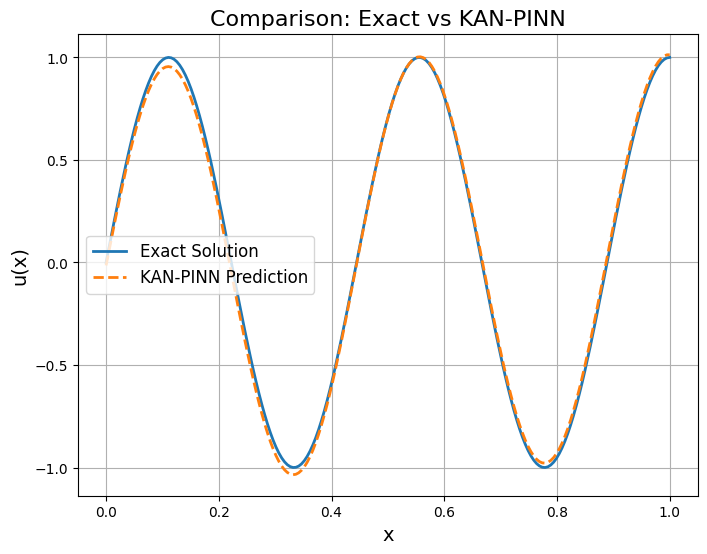

Relative error(MAE) = 5.518e-01.


In [ ]:
# %% Import modules
import numpy as np
import jax
import jax.numpy as jnp
from jax import vjp, jit, grad
from jax.example_libraries import optimizers
from functools import partial
import time
import matplotlib.pyplot as plt

# %% Chebyshev helper functions
def chebyshev_recursive(x, degree):
    if degree == 0:
        return x * 0 + 1
    elif degree == 1:
        return x
    else:
        T_n_minus_1 = x
        T_n_minus_2 = x * 0 + 1
        for n in range(2, degree + 1):
            T_n = 2 * x * T_n_minus_1 - T_n_minus_2
            T_n_minus_2, T_n_minus_1 = T_n_minus_1, T_n
        return T_n

def chebyshev_cosine(x, degree):
    return jnp.cos(degree * jnp.arccos(x))

# %% KAN initialization
def init_params_kan2(layers, degree):
    keys = jax.random.split(jax.random.PRNGKey(123), len(layers) - 1)
    params = []
    for key, n_in, n_out in zip(keys[:-1], layers[:-2], layers[1:-1]):
        W = jax.random.normal(key, shape=(n_in, n_out, degree + 1)) / jnp.sqrt(n_in * (degree + 1))
        g = jax.random.normal(key, shape=(n_out,))
        params.append({'W': W, 'g': g})
    W = jax.random.normal(keys[-1], shape=(layers[-2], layers[-1])) / jnp.sqrt(layers[-2])
    B = jax.random.normal(keys[-1], shape=(layers[-1],))
    params.append({'W': W, 'B': B})
    return params

# %% KAN forward pass
def fwd_kan(params, t, activation=jax.nn.tanh, use_cosine=False):
    t = 0.01 * t
    X = t.reshape((-1, 1))
    *hidden, last = params
    for layer in hidden:
        X = activation(X)
        cheby_coeffs = layer['W']
        degree = cheby_coeffs.shape[2] - 1
        if use_cosine:
            X_stack = jnp.stack([chebyshev_cosine(X, d) for d in range(degree + 1)], axis=-1)
        else:
            X_stack = jnp.stack([chebyshev_recursive(X, d) for d in range(degree + 1)], axis=-1)
        X = jnp.einsum("bid,iod->bo", X_stack, cheby_coeffs)
        # X = layer['g'] * X
    return X @ last['W'] + last['B']

# %% helper functions
def vgrad(f, x):
    y, vjp_fn = vjp(f, x)
    return vjp_fn(jnp.ones(y.shape))[0]

# Ground truth and forcing term
def exact_solution(x):
    return jnp.sin(9 * jnp.pi / 2 * x)

def forcing_term(x):
    coef = -(9 * jnp.pi / 2) ** 2 - 1
    return coef * jnp.sin(9 * jnp.pi / 2 * x)

# %% Define KAN-based PINN model
class PINN_KAN:
    def __init__(self, layers, degree, weight, activation=jax.nn.tanh, use_cosine=False):
        self.degree = degree
        self.activation = activation
        self.use_cosine = use_cosine
        self.weight_eqn, self.weight_bc = weight
        self.params = init_params_kan2(layers, degree)
        self.opt_init, self.opt_update, self.get_params = optimizers.adam(1e-3)
        self.opt_state = self.opt_init(self.params)

    @partial(jit, static_argnums=(0,))
    def equation(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        fu = lambda x: pinn(x)
        dudx = lambda x: vgrad(fu, x)
        d2udx2 = lambda x: vgrad(dudx, x)
        u = fu(X)
        u_xx = d2udx2(X)
        f = forcing_term(X)
        return u_xx - u - f

    @partial(jit, static_argnums=(0,))
    def forward(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        return pinn(X)

    @partial(jit, static_argnums=(0,))
    def loss_component(self, params, X_res, X_bc):
        x_bc, y_bc = X_bc
        eq1 = self.equation(params, X_res)
        loss_res = jnp.mean(eq1 ** 2)
        x_bc_l, x_bc_r = x_bc
        u_l_pred = self.forward(params, x_bc_l)
        u_r_pred = self.forward(params, x_bc_r)
        u_l, u_r = y_bc
        loss_bc = jnp.mean((u_l - u_l_pred) ** 2 + (u_r - u_r_pred) ** 2)
        return loss_res, loss_bc

    def loss(self, params, X_res, X_bc):
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return self.weight_eqn * loss_res + self.weight_bc * loss_bc

    @partial(jit, static_argnums=(0,))
    def update(self, i, opt_state, X_res, X_bc):
        params = self.get_params(opt_state)
        next_opt_state = self.opt_update(i, grad(self.loss)(params, X_res, X_bc), opt_state)
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return next_opt_state, (loss_res, loss_bc)

# %% prepare data
N = 100
X = np.random.uniform(0, 1, size=(N,1))
X_res = jnp.array(X)

X_bc = (
    (jnp.array(0.0).reshape(-1,1), jnp.array(1.0).reshape(-1,1)),
    (jnp.array(0.0).reshape(-1,1), jnp.array(1.0).reshape(-1,1)),
)

# %% training
layers = [1, 20, 20, 20, 1]
degree = 3
model = PINN_KAN(layers, degree, weight=(1,1))
N_epochs = 20000
Y_result = []

for epoch in range(1, N_epochs+1):
    start = time.time()
    model.opt_state, losses = model.update(epoch, model.opt_state, X_res, X_bc)
    model.params = model.get_params(model.opt_state)
    end = time.time()
    if epoch % 100 == 0:
        loss_res, loss_bc = losses
        print(f"Epoch: {epoch}, Time: {end-start:.2f}s, Loss_eqn={loss_res:.3e}, Loss_bc={loss_bc:.3e}")
        Y = model.forward(model.params, X_res)
        Y_result.append(Y)

# %% Compare and plot
X_plot = np.linspace(0, 1, 200).reshape(-1, 1)
X_plot_jax = jnp.array(X_plot)

Y_pred_plot = model.forward(model.params, X_plot_jax).flatten()
Y_true_plot = exact_solution(X_plot_jax).flatten()

plt.figure(figsize=(8,6))
plt.plot(X_plot, Y_true_plot, label="Exact Solution", linewidth=2)
plt.plot(X_plot, Y_pred_plot, '--', label="KAN-PINN Prediction", linewidth=2)
plt.xlabel('x', fontsize=14)
plt.ylabel('u(x)', fontsize=14)
plt.title('Comparison: Exact vs KAN-PINN', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# %% Relative error
Y_true = exact_solution(X_res).flatten()
Y_pred = Y_result[-1].flatten()
err = np.mean((Y_pred - Y_true)**2) / (np.mean(Y_true)**2)
print(f"Relative error(MAE) = {err:.3e}.")


err = np.mean((Y_pred - Y_true)**2)
print(f"MSE = {err:.3e}.")

MSE = 8.433e-04.


Epoch: 100, Time: 0.00s, Loss_eqn=6.566e+01, Loss_bc=1.194e+01
Epoch: 200, Time: 0.00s, Loss_eqn=6.599e-01, Loss_bc=4.835e+00
Epoch: 300, Time: 0.00s, Loss_eqn=2.897e-01, Loss_bc=2.583e+00
Epoch: 400, Time: 0.00s, Loss_eqn=1.791e-01, Loss_bc=1.428e+00
Epoch: 500, Time: 0.00s, Loss_eqn=2.309e-01, Loss_bc=8.519e-01
Epoch: 600, Time: 0.00s, Loss_eqn=1.198e-01, Loss_bc=5.383e-01
Epoch: 700, Time: 0.00s, Loss_eqn=1.030e-01, Loss_bc=3.542e-01
Epoch: 800, Time: 0.00s, Loss_eqn=2.637e-01, Loss_bc=2.315e-01
Epoch: 900, Time: 0.00s, Loss_eqn=5.688e-02, Loss_bc=1.585e-01
Epoch: 1000, Time: 0.00s, Loss_eqn=8.317e-02, Loss_bc=1.061e-01
Epoch: 1100, Time: 0.00s, Loss_eqn=3.902e-02, Loss_bc=7.138e-02
Epoch: 1200, Time: 0.00s, Loss_eqn=1.332e-01, Loss_bc=4.598e-02
Epoch: 1300, Time: 0.00s, Loss_eqn=1.267e+00, Loss_bc=3.367e-02
Epoch: 1400, Time: 0.00s, Loss_eqn=1.250e-01, Loss_bc=2.106e-02
Epoch: 1500, Time: 0.00s, Loss_eqn=2.624e-02, Loss_bc=1.509e-02
Epoch: 1600, Time: 0.00s, Loss_eqn=5.620e-02, Los

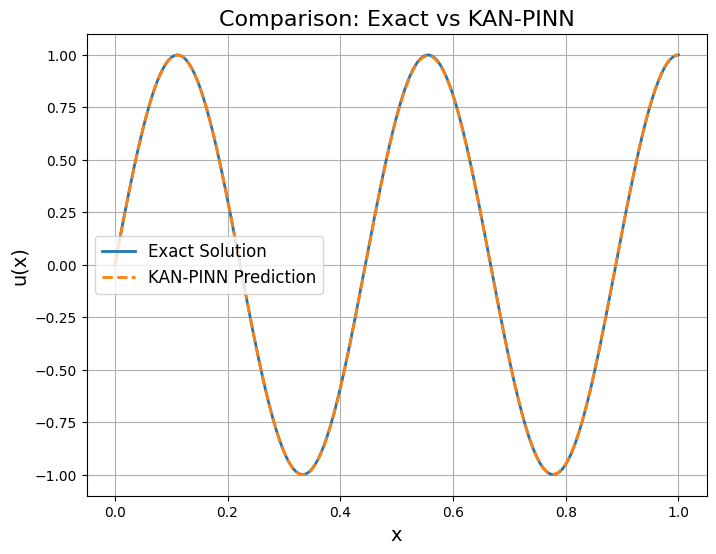

Relative error(MAE) = 6.782e-04.


In [ ]:
# %% Import modules
import numpy as np
import jax
import jax.numpy as jnp
from jax import vjp, jit, grad
from jax.example_libraries import optimizers
from functools import partial
import time
import matplotlib.pyplot as plt

# %% Chebyshev helper functions
def chebyshev_recursive(x, degree):
    if degree == 0:
        return x * 0 + 1
    elif degree == 1:
        return x
    else:
        T_n_minus_1 = x
        T_n_minus_2 = x * 0 + 1
        for n in range(2, degree + 1):
            T_n = 2 * x * T_n_minus_1 - T_n_minus_2
            T_n_minus_2, T_n_minus_1 = T_n_minus_1, T_n
        return T_n

def chebyshev_cosine(x, degree):
    return jnp.cos(degree * jnp.arccos(x))

# %% KAN initialization
def init_params_kan2(layers, degree):
    keys = jax.random.split(jax.random.PRNGKey(123), len(layers) - 1)
    params = []
    for key, n_in, n_out in zip(keys[:-1], layers[:-2], layers[1:-1]):
        W = jax.random.normal(key, shape=(n_in, n_out, degree + 1)) / jnp.sqrt(n_in * (degree + 1))
        g = jax.random.normal(key, shape=(n_out,))
        params.append({'W': W, 'g': g})
    W = jax.random.normal(keys[-1], shape=(layers[-2], layers[-1])) / jnp.sqrt(layers[-2])
    B = jax.random.normal(keys[-1], shape=(layers[-1],))
    params.append({'W': W, 'B': B})
    return params

# %% KAN forward pass
def fwd_kan(params, t, activation=jax.nn.tanh, use_cosine=False):
    X = t.reshape((-1, 1))
    *hidden, last = params
    for layer in hidden:
        X = activation(X)
        cheby_coeffs = layer['W']
        degree = cheby_coeffs.shape[2] - 1
        if use_cosine:
            X_stack = jnp.stack([chebyshev_cosine(X, d) for d in range(degree + 1)], axis=-1)
        else:
            X_stack = jnp.stack([chebyshev_recursive(X, d) for d in range(degree + 1)], axis=-1)
        X = jnp.einsum("bid,iod->bo", X_stack, cheby_coeffs)
        X = activation(X)
        # X = layer['g'] * X
    return X @ last['W'] + last['B']

# %% helper functions
def vgrad(f, x):
    y, vjp_fn = vjp(f, x)
    return vjp_fn(jnp.ones(y.shape))[0]

# Ground truth and forcing term
def exact_solution(x):
    return jnp.sin(9 * jnp.pi / 2 * x)

def forcing_term(x):
    coef = -(9 * jnp.pi / 2) ** 2 - 1
    return coef * jnp.sin(9 * jnp.pi / 2 * x)

# %% Define KAN-based PINN model
class PINN_KAN:
    def __init__(self, layers, degree, weight, activation=jax.nn.tanh, use_cosine=False):
        self.degree = degree
        self.activation = activation
        self.use_cosine = use_cosine
        self.weight_eqn, self.weight_bc = weight
        self.params = init_params_kan2(layers, degree)
        self.opt_init, self.opt_update, self.get_params = optimizers.adam(1e-3)
        self.opt_state = self.opt_init(self.params)

    @partial(jit, static_argnums=(0,))
    def equation(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        fu = lambda x: pinn(x)
        dudx = lambda x: vgrad(fu, x)
        d2udx2 = lambda x: vgrad(dudx, x)
        u = fu(X)
        u_xx = d2udx2(X)
        f = forcing_term(X)
        return u_xx - u - f

    @partial(jit, static_argnums=(0,))
    def forward(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        return pinn(X)

    @partial(jit, static_argnums=(0,))
    def loss_component(self, params, X_res, X_bc):
        x_bc, y_bc = X_bc
        eq1 = self.equation(params, X_res)
        loss_res = jnp.mean(eq1 ** 2)
        x_bc_l, x_bc_r = x_bc
        u_l_pred = self.forward(params, x_bc_l)
        u_r_pred = self.forward(params, x_bc_r)
        u_l, u_r = y_bc
        loss_bc = jnp.mean((u_l - u_l_pred) ** 2 + (u_r - u_r_pred) ** 2)
        return loss_res, loss_bc

    def loss(self, params, X_res, X_bc):
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return self.weight_eqn * loss_res + self.weight_bc * loss_bc

    @partial(jit, static_argnums=(0,))
    def update(self, i, opt_state, X_res, X_bc):
        params = self.get_params(opt_state)
        next_opt_state = self.opt_update(i, grad(self.loss)(params, X_res, X_bc), opt_state)
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return next_opt_state, (loss_res, loss_bc)

# %% prepare data
N = 1000
X = np.random.uniform(0, 1, size=(N,1))
X_res = jnp.array(X)

X_bc = (
    (jnp.array(0.0).reshape(-1,1), jnp.array(1.0).reshape(-1,1)),
    (jnp.array(0.0).reshape(-1,1), jnp.array(1.0).reshape(-1,1)),
)

# %% training
layers = [1, 20, 20, 20, 1]
degree = 3
model = PINN_KAN(layers, degree, weight=(1,1))
N_epochs = 20000
Y_result = []

for epoch in range(1, N_epochs+1):
    start = time.time()
    model.opt_state, losses = model.update(epoch, model.opt_state, X_res, X_bc)
    model.params = model.get_params(model.opt_state)
    end = time.time()
    if epoch % 100 == 0:
        loss_res, loss_bc = losses
        print(f"Epoch: {epoch}, Time: {end-start:.2f}s, Loss_eqn={loss_res:.3e}, Loss_bc={loss_bc:.3e}")
        Y = model.forward(model.params, X_res)
        Y_result.append(Y)

# %% Compare and plot
X_plot = np.linspace(0, 1, 200).reshape(-1, 1)
X_plot_jax = jnp.array(X_plot)

Y_pred_plot = model.forward(model.params, X_plot_jax).flatten()
Y_true_plot = exact_solution(X_plot_jax).flatten()

plt.figure(figsize=(8,6))
plt.plot(X_plot, Y_true_plot, label="Exact Solution", linewidth=2)
plt.plot(X_plot, Y_pred_plot, '--', label="KAN-PINN Prediction", linewidth=2)
plt.xlabel('x', fontsize=14)
plt.ylabel('u(x)', fontsize=14)
plt.title('Comparison: Exact vs KAN-PINN', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# %% Relative error
Y_true = exact_solution(X_res).flatten()
Y_pred = Y_result[-1].flatten()
err = np.mean((Y_pred - Y_true)**2) / (np.mean(Y_true)**2)
print(f"Relative error(MAE) = {err:.3e}.")


err = np.mean((Y_pred - Y_true)**2)
print(f"MSE = {err:.3e}.")

Epoch: 100, Time: 0.00s, Loss_eqn=2.011e+02, Loss_bc=1.242e+01
Epoch: 200, Time: 0.00s, Loss_eqn=2.835e+00, Loss_bc=6.001e+00
Epoch: 300, Time: 0.00s, Loss_eqn=4.223e-01, Loss_bc=3.524e+00
Epoch: 400, Time: 0.00s, Loss_eqn=2.866e-01, Loss_bc=2.148e+00
Epoch: 500, Time: 0.00s, Loss_eqn=2.003e-01, Loss_bc=1.277e+00
Epoch: 600, Time: 0.00s, Loss_eqn=7.853e-01, Loss_bc=7.624e-01
Epoch: 700, Time: 0.00s, Loss_eqn=9.844e-02, Loss_bc=4.424e-01
Epoch: 800, Time: 0.00s, Loss_eqn=1.833e-01, Loss_bc=2.641e-01
Epoch: 900, Time: 0.00s, Loss_eqn=5.110e-02, Loss_bc=1.582e-01
Epoch: 1000, Time: 0.00s, Loss_eqn=7.279e-01, Loss_bc=9.733e-02
Epoch: 1100, Time: 0.00s, Loss_eqn=6.565e-01, Loss_bc=5.891e-02
Epoch: 1200, Time: 0.00s, Loss_eqn=1.056e-01, Loss_bc=3.156e-02
Epoch: 1300, Time: 0.00s, Loss_eqn=1.759e-02, Loss_bc=1.793e-02
Epoch: 1400, Time: 0.00s, Loss_eqn=2.257e-01, Loss_bc=9.316e-03
Epoch: 1500, Time: 0.00s, Loss_eqn=2.555e-01, Loss_bc=6.708e-03
Epoch: 1600, Time: 0.00s, Loss_eqn=3.041e+00, Los

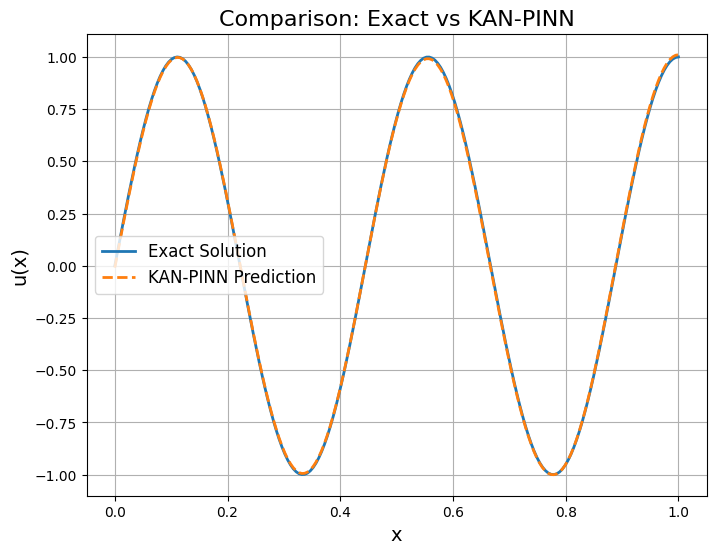

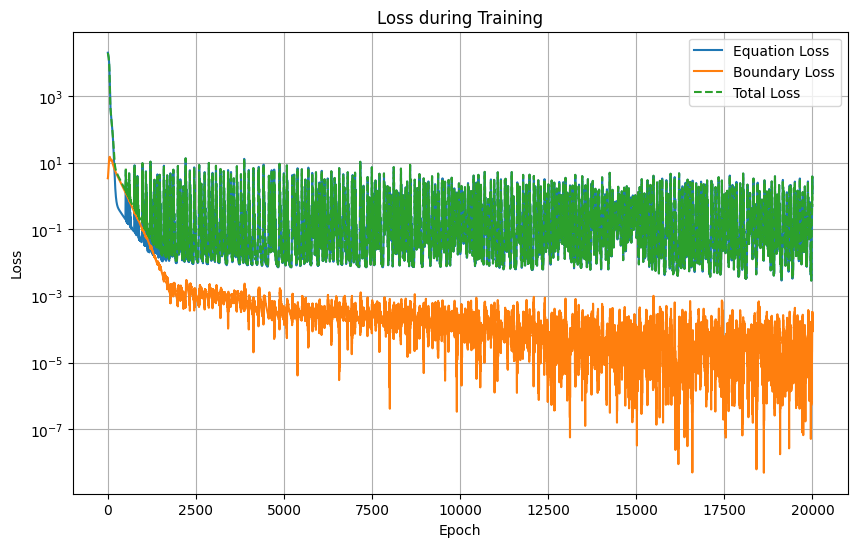

Relative error(MAE) = 6.277e-03.


In [ ]:
# %% Import modules
import numpy as np
import jax
import jax.numpy as jnp
from jax import vjp, jit, grad
from jax.example_libraries import optimizers
from functools import partial
import time
import matplotlib.pyplot as plt

# %% Chebyshev helper functions
def chebyshev_recursive(x, degree):
    if degree == 0:
        return x * 0 + 1
    elif degree == 1:
        return x
    else:
        T_n_minus_1 = x
        T_n_minus_2 = x * 0 + 1
        for n in range(2, degree + 1):
            T_n = 2 * x * T_n_minus_1 - T_n_minus_2
            T_n_minus_2, T_n_minus_1 = T_n_minus_1, T_n
        return T_n

def chebyshev_cosine(x, degree):
    return jnp.cos(degree * jnp.arccos(x))

# %% KAN initialization
def init_params_kan2(layers, degree):
    keys = jax.random.split(jax.random.PRNGKey(123), len(layers) - 1)
    params = []
    for key, n_in, n_out in zip(keys[:-1], layers[:-2], layers[1:-1]):
        W = jax.random.normal(key, shape=(n_in, n_out, degree + 1)) / jnp.sqrt(n_in * (degree + 1))
        g = jax.random.normal(key, shape=(n_out,))
        params.append({'W': W, 'g': g})
    W = jax.random.normal(keys[-1], shape=(layers[-2], layers[-1])) / jnp.sqrt(layers[-2])
    B = jax.random.normal(keys[-1], shape=(layers[-1],))
    params.append({'W': W, 'B': B})
    return params

# %% KAN forward pass
def fwd_kan(params, t, activation=jax.nn.tanh, use_cosine=False):
    X = t.reshape((-1, 1))
    *hidden, last = params
    for layer in hidden:
        X = activation(X)
        cheby_coeffs = layer['W']
        degree = cheby_coeffs.shape[2] - 1
        X_stack = jnp.stack([chebyshev_recursive(X, d) for d in range(degree + 1)], axis=-1)
        X = jnp.einsum("bid,iod->bo", X_stack, cheby_coeffs)
        X = activation(X)
    return X @ last['W'] + last['B']

# %% helper functions
def vgrad(f, x):
    y, vjp_fn = vjp(f, x)
    return vjp_fn(jnp.ones(y.shape))[0]

# Ground truth and forcing term
def exact_solution(x):
    return jnp.sin(9 * jnp.pi / 2 * x)

def forcing_term(x):
    coef = -(9 * jnp.pi / 2) ** 2 - 1
    return coef * jnp.sin(9 * jnp.pi / 2 * x)

# %% Define KAN-based PINN model
class PINN_KAN:
    def __init__(self, layers, degree, weight, activation=jax.nn.tanh, use_cosine=False):
        self.degree = degree
        self.activation = activation
        self.use_cosine = use_cosine
        self.weight_eqn, self.weight_bc = weight
        self.params = init_params_kan2(layers, degree)
        self.opt_init, self.opt_update, self.get_params = optimizers.adam(1e-3)
        self.opt_state = self.opt_init(self.params)

    @partial(jit, static_argnums=(0,))
    def equation(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        fu = lambda x: pinn(x)
        dudx = lambda x: vgrad(fu, x)
        d2udx2 = lambda x: vgrad(dudx, x)
        u = fu(X)
        u_xx = d2udx2(X)
        f = forcing_term(X)
        return u_xx - u - f

    @partial(jit, static_argnums=(0,))
    def forward(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        return pinn(X)

    @partial(jit, static_argnums=(0,))
    def loss_component(self, params, X_res, X_bc):
        x_bc, y_bc = X_bc
        eq1 = self.equation(params, X_res)
        loss_res = jnp.mean(eq1 ** 2)
        x_bc_l, x_bc_r = x_bc
        u_l_pred = self.forward(params, x_bc_l)
        u_r_pred = self.forward(params, x_bc_r)
        u_l, u_r = y_bc
        loss_bc = jnp.mean((u_l - u_l_pred) ** 2 + (u_r - u_r_pred) ** 2)
        return loss_res, loss_bc

    def loss(self, params, X_res, X_bc):
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return self.weight_eqn * loss_res + self.weight_bc * loss_bc

    @partial(jit, static_argnums=(0,))
    def update(self, i, opt_state, X_res, X_bc):
        params = self.get_params(opt_state)
        next_opt_state = self.opt_update(i, grad(self.loss)(params, X_res, X_bc), opt_state)
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return next_opt_state, (loss_res, loss_bc)

# %% prepare data
N = 1000
X = np.random.uniform(0, 1, size=(N,1))
X_res = jnp.array(X)

X_bc = (
    (jnp.array(0.0).reshape(-1,1), jnp.array(1.0).reshape(-1,1)),
    (jnp.array(0.0).reshape(-1,1), jnp.array(1.0).reshape(-1,1)),
)

# %% training
layers = [1, 20, 20, 20, 1]
degree = 3
model = PINN_KAN(layers, degree, weight=(1,1))
N_epochs = 20000
Y_result = []

# track losses
loss_eqn_hist = []
loss_bc_hist = []
total_loss_hist = []

for epoch in range(1, N_epochs+1):
    start = time.time()
    model.opt_state, losses = model.update(epoch, model.opt_state, X_res, X_bc)
    model.params = model.get_params(model.opt_state)
    loss_res, loss_bc = losses
    total_loss = model.loss(model.params, X_res, X_bc)
    loss_eqn_hist.append(loss_res)
    loss_bc_hist.append(loss_bc)
    total_loss_hist.append(total_loss)
    end = time.time()

    if epoch % 100 == 0:
        print(f"Epoch: {epoch}, Time: {end-start:.2f}s, Loss_eqn={loss_res:.3e}, Loss_bc={loss_bc:.3e}")
        Y = model.forward(model.params, X_res)
        Y_result.append(Y)

# %% Compare and plot
X_plot = np.linspace(0, 1, 200).reshape(-1, 1)
X_plot_jax = jnp.array(X_plot)

Y_pred_plot = model.forward(model.params, X_plot_jax).flatten()
Y_true_plot = exact_solution(X_plot_jax).flatten()

plt.figure(figsize=(8,6))
plt.plot(X_plot, Y_true_plot, label="Exact Solution", linewidth=2)
plt.plot(X_plot, Y_pred_plot, '--', label="KAN-PINN Prediction", linewidth=2)
plt.xlabel('x', fontsize=14)
plt.ylabel('u(x)', fontsize=14)
plt.title('Comparison: Exact vs KAN-PINN', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# %% Plot loss curves
plt.figure(figsize=(10,6))
plt.plot(loss_eqn_hist, label='Equation Loss')
plt.plot(loss_bc_hist, label='Boundary Loss')
plt.plot(total_loss_hist, label='Total Loss', linestyle='--')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss during Training')
plt.legend()
plt.grid(True)
plt.show()

# %% Relative error
Y_true = exact_solution(X_res).flatten()
Y_pred = Y_result[-1].flatten()
err = np.mean((Y_pred - Y_true)**2) / (np.mean(Y_true)**2)
print(f"Relative error(MAE) = {err:.3e}.")

err = np.mean((Y_pred - Y_true)**2) #/ (np.mean(Y_true)**2)
print(f"MSE = {err:.3e}.")

Epoch: 100, Time: 0.00s, Loss_eqn=1.771e+04, Loss_bc=5.394e+00
Epoch: 200, Time: 0.00s, Loss_eqn=1.268e+04, Loss_bc=1.047e+01
Epoch: 300, Time: 0.00s, Loss_eqn=6.671e+03, Loss_bc=1.403e+01
Epoch: 400, Time: 0.00s, Loss_eqn=2.290e+03, Loss_bc=1.472e+01
Epoch: 500, Time: 0.00s, Loss_eqn=6.912e+02, Loss_bc=1.226e+01
Epoch: 600, Time: 0.00s, Loss_eqn=3.360e+02, Loss_bc=9.982e+00
Epoch: 700, Time: 0.00s, Loss_eqn=2.067e+02, Loss_bc=8.214e+00
Epoch: 800, Time: 0.00s, Loss_eqn=1.295e+02, Loss_bc=7.056e+00
Epoch: 900, Time: 0.00s, Loss_eqn=7.736e+01, Loss_bc=6.281e+00
Epoch: 1000, Time: 0.00s, Loss_eqn=4.253e+01, Loss_bc=5.708e+00
Epoch: 1100, Time: 0.00s, Loss_eqn=2.158e+01, Loss_bc=5.253e+00
Epoch: 1200, Time: 0.00s, Loss_eqn=1.062e+01, Loss_bc=4.851e+00
Epoch: 1300, Time: 0.00s, Loss_eqn=5.471e+00, Loss_bc=4.477e+00
Epoch: 1400, Time: 0.00s, Loss_eqn=3.132e+00, Loss_bc=4.133e+00
Epoch: 1500, Time: 0.00s, Loss_eqn=2.044e+00, Loss_bc=3.819e+00
Epoch: 1600, Time: 0.00s, Loss_eqn=1.500e+00, Los

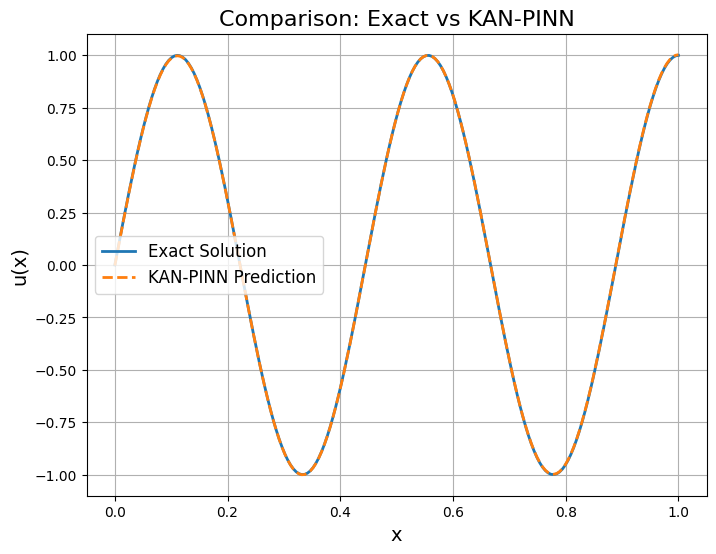

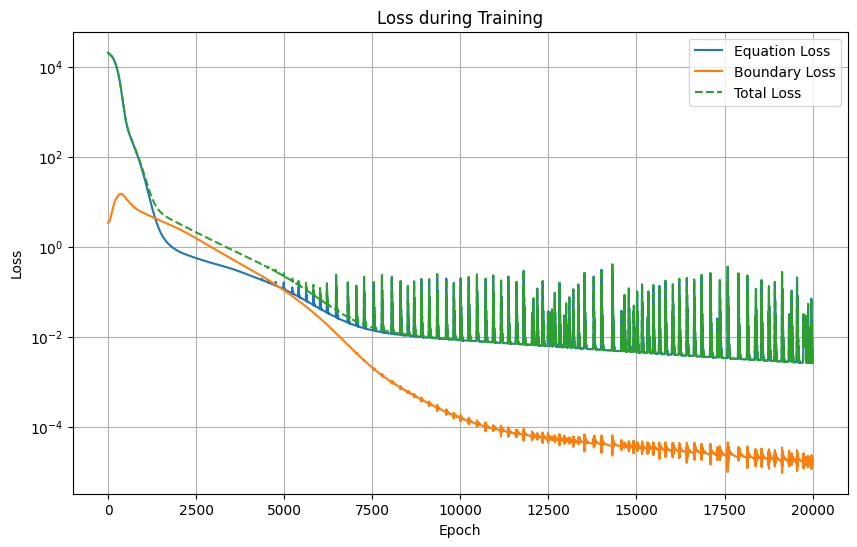

Relative error(MAE) = 5.637e-04.
MSE = 2.675e-06.


In [ ]:
# %% Import modules
import numpy as np
import jax
import jax.numpy as jnp
from jax import vjp, jit, grad
from jax.example_libraries import optimizers
from functools import partial
import time
import matplotlib.pyplot as plt

# %% Chebyshev helper functions
def chebyshev_recursive(x, degree):
    if degree == 0:
        return x * 0 + 1
    elif degree == 1:
        return x
    else:
        T_n_minus_1 = x
        T_n_minus_2 = x * 0 + 1
        for n in range(2, degree + 1):
            T_n = 2 * x * T_n_minus_1 - T_n_minus_2
            T_n_minus_2, T_n_minus_1 = T_n_minus_1, T_n
        return T_n

def chebyshev_cosine(x, degree):
    return jnp.cos(degree * jnp.arccos(x))

# %% KAN initialization
def init_params_kan2(layers, degree):
    keys = jax.random.split(jax.random.PRNGKey(123), len(layers) - 1)
    params = []
    for key, n_in, n_out in zip(keys[:-1], layers[:-2], layers[1:-1]):
        W = jax.random.normal(key, shape=(n_in, n_out, degree + 1)) / jnp.sqrt(n_in * (degree + 1))
        g = jax.random.normal(key, shape=(n_out,))
        params.append({'W': W, 'g': g})
    W = jax.random.normal(keys[-1], shape=(layers[-2], layers[-1])) / jnp.sqrt(layers[-2])
    B = jax.random.normal(keys[-1], shape=(layers[-1],))
    params.append({'W': W, 'B': B})
    return params

# %% KAN forward pass
def fwd_kan(params, t, activation=jax.nn.tanh, use_cosine=False):
    X = t.reshape((-1, 1))
    *hidden, last = params
    for layer in hidden:
        X = activation(X)
        cheby_coeffs = layer['W']
        degree = cheby_coeffs.shape[2] - 1
        X_stack = jnp.stack([chebyshev_recursive(X, d) for d in range(degree + 1)], axis=-1)
        X = jnp.einsum("bid,iod->bo", X_stack, cheby_coeffs)
        X = activation(X)
    return X @ last['W'] + last['B']

# %% helper functions
def vgrad(f, x):
    y, vjp_fn = vjp(f, x)
    return vjp_fn(jnp.ones(y.shape))[0]

# Ground truth and forcing term
def exact_solution(x):
    return jnp.sin(9 * jnp.pi / 2 * x)

def forcing_term(x):
    coef = -(9 * jnp.pi / 2) ** 2 - 1
    return coef * jnp.sin(9 * jnp.pi / 2 * x)

# %% Define KAN-based PINN model
class PINN_KAN:
    def __init__(self, layers, degree, weight, activation=jax.nn.tanh, use_cosine=False):
        self.degree = degree
        self.activation = activation
        self.use_cosine = use_cosine
        self.weight_eqn, self.weight_bc = weight
        self.params = init_params_kan2(layers, degree)
        self.opt_init, self.opt_update, self.get_params = optimizers.adam(1e-4)
        self.opt_state = self.opt_init(self.params)

    @partial(jit, static_argnums=(0,))
    def equation(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        fu = lambda x: pinn(x)
        dudx = lambda x: vgrad(fu, x)
        d2udx2 = lambda x: vgrad(dudx, x)
        u = fu(X)
        u_xx = d2udx2(X)
        f = forcing_term(X)
        return u_xx - u - f

    @partial(jit, static_argnums=(0,))
    def forward(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        return pinn(X)

    @partial(jit, static_argnums=(0,))
    def loss_component(self, params, X_res, X_bc):
        x_bc, y_bc = X_bc
        eq1 = self.equation(params, X_res)
        loss_res = jnp.mean(eq1 ** 2)
        x_bc_l, x_bc_r = x_bc
        u_l_pred = self.forward(params, x_bc_l)
        u_r_pred = self.forward(params, x_bc_r)
        u_l, u_r = y_bc
        loss_bc = jnp.mean((u_l - u_l_pred) ** 2 + (u_r - u_r_pred) ** 2)
        return loss_res, loss_bc

    def loss(self, params, X_res, X_bc):
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return self.weight_eqn * loss_res + self.weight_bc * loss_bc

    @partial(jit, static_argnums=(0,))
    def update(self, i, opt_state, X_res, X_bc):
        params = self.get_params(opt_state)
        next_opt_state = self.opt_update(i, grad(self.loss)(params, X_res, X_bc), opt_state)
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return next_opt_state, (loss_res, loss_bc)

# %% prepare data
N = 1000
X = np.random.uniform(0, 1, size=(N,1))
X_res = jnp.array(X)

X_bc = (
    (jnp.array(0.0).reshape(-1,1), jnp.array(1.0).reshape(-1,1)),
    (jnp.array(0.0).reshape(-1,1), jnp.array(1.0).reshape(-1,1)),
)

# %% training
layers = [1, 20, 20, 20, 1]
degree = 3
model = PINN_KAN(layers, degree, weight=(1,1))
N_epochs = 20000
Y_result = []

# track losses
loss_eqn_hist = []
loss_bc_hist = []
total_loss_hist = []

for epoch in range(1, N_epochs+1):
    start = time.time()
    model.opt_state, losses = model.update(epoch, model.opt_state, X_res, X_bc)
    model.params = model.get_params(model.opt_state)
    loss_res, loss_bc = losses
    total_loss = model.loss(model.params, X_res, X_bc)
    loss_eqn_hist.append(loss_res)
    loss_bc_hist.append(loss_bc)
    total_loss_hist.append(total_loss)
    end = time.time()

    if epoch % 100 == 0:
        print(f"Epoch: {epoch}, Time: {end-start:.2f}s, Loss_eqn={loss_res:.3e}, Loss_bc={loss_bc:.3e}")
        Y = model.forward(model.params, X_res)
        Y_result.append(Y)

# %% Compare and plot
X_plot = np.linspace(0, 1, 200).reshape(-1, 1)
X_plot_jax = jnp.array(X_plot)

Y_pred_plot = model.forward(model.params, X_plot_jax).flatten()
Y_true_plot = exact_solution(X_plot_jax).flatten()

plt.figure(figsize=(8,6))
plt.plot(X_plot, Y_true_plot, label="Exact Solution", linewidth=2)
plt.plot(X_plot, Y_pred_plot, '--', label="KAN-PINN Prediction", linewidth=2)
plt.xlabel('x', fontsize=14)
plt.ylabel('u(x)', fontsize=14)
plt.title('Comparison: Exact vs KAN-PINN', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# %% Plot loss curves
plt.figure(figsize=(10,6))
plt.plot(loss_eqn_hist, label='Equation Loss')
plt.plot(loss_bc_hist, label='Boundary Loss')
plt.plot(total_loss_hist, label='Total Loss', linestyle='--')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss during Training')
plt.legend()
plt.grid(True)
plt.show()

# %% Relative error
Y_true = exact_solution(X_res).flatten()
Y_pred = Y_result[-1].flatten()
err = np.mean((Y_pred - Y_true)**2) / (np.mean(Y_true)**2)
print(f"Relative error(MAE) = {err:.3e}.")

err = np.mean((Y_pred - Y_true)**2) #/ (np.mean(Y_true)**2)
print(f"MSE = {err:.3e}.")

Epoch: 100, Time: 0.00s, Loss_eqn=1.851e+04, Loss_bc=1.599e+00
Epoch: 200, Time: 0.00s, Loss_eqn=1.630e+04, Loss_bc=1.787e+00
Epoch: 300, Time: 0.00s, Loss_eqn=1.253e+04, Loss_bc=1.361e+00
Epoch: 400, Time: 0.00s, Loss_eqn=7.628e+03, Loss_bc=6.524e-01
Epoch: 500, Time: 0.00s, Loss_eqn=3.718e+03, Loss_bc=1.199e-01
Epoch: 600, Time: 0.00s, Loss_eqn=1.482e+03, Loss_bc=8.593e-02
Epoch: 700, Time: 0.00s, Loss_eqn=5.477e+02, Loss_bc=3.732e-01
Epoch: 800, Time: 0.00s, Loss_eqn=2.184e+02, Loss_bc=8.878e-01
Epoch: 900, Time: 0.00s, Loss_eqn=1.002e+02, Loss_bc=1.579e+00
Epoch: 1000, Time: 0.00s, Loss_eqn=4.617e+01, Loss_bc=2.352e+00
Epoch: 1100, Time: 0.00s, Loss_eqn=2.126e+01, Loss_bc=2.930e+00
Epoch: 1200, Time: 0.00s, Loss_eqn=1.006e+01, Loss_bc=3.258e+00
Epoch: 1300, Time: 0.00s, Loss_eqn=5.013e+00, Loss_bc=3.377e+00
Epoch: 1400, Time: 0.00s, Loss_eqn=2.698e+00, Loss_bc=3.340e+00
Epoch: 1500, Time: 0.00s, Loss_eqn=1.600e+00, Loss_bc=3.206e+00
Epoch: 1600, Time: 0.00s, Loss_eqn=1.053e+00, Los

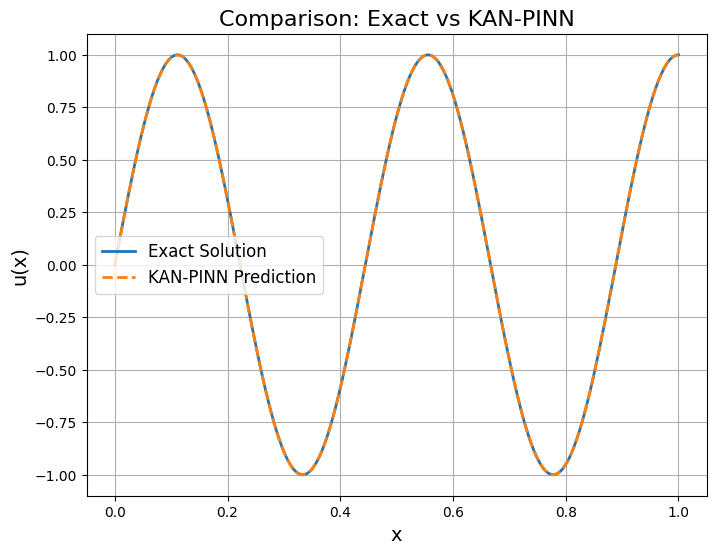

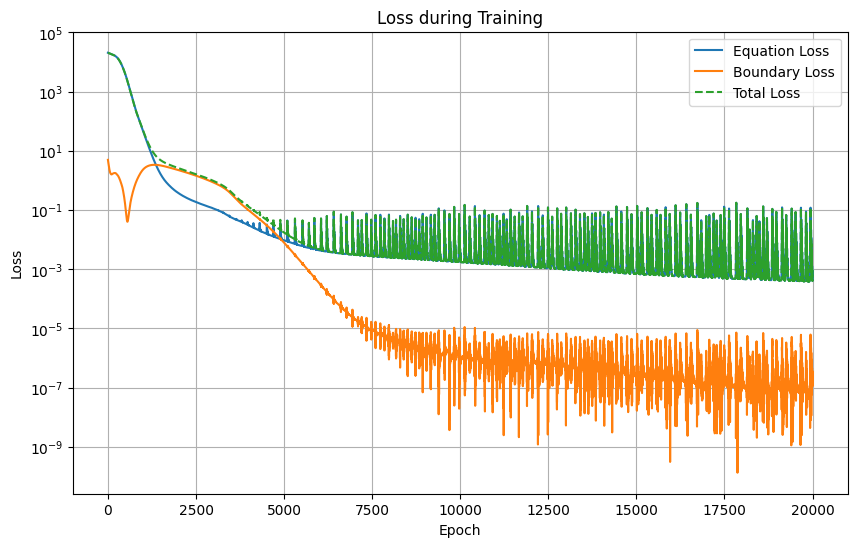

Relative error(MAE) = 1.830e-05.
MSE = 3.923e-08.


In [ ]:
# %% Import modules
import numpy as np
import jax
import jax.numpy as jnp
from jax import vjp, jit, grad
from jax.example_libraries import optimizers
from functools import partial
import time
import matplotlib.pyplot as plt

# %% Chebyshev helper functions
def chebyshev_recursive(x, degree):
    if degree == 0:
        return x * 0 + 1
    elif degree == 1:
        return x
    else:
        T_n_minus_1 = x
        T_n_minus_2 = x * 0 + 1
        for n in range(2, degree + 1):
            T_n = 2 * x * T_n_minus_1 - T_n_minus_2
            T_n_minus_2, T_n_minus_1 = T_n_minus_1, T_n
        return T_n

def chebyshev_cosine(x, degree):
    return jnp.cos(degree * jnp.arccos(x))

# %% KAN initialization
def init_params_kan2(layers, degree):
    keys = jax.random.split(jax.random.PRNGKey(123), len(layers) - 1)
    params = []
    for key, n_in, n_out in zip(keys[:-1], layers[:-2], layers[1:-1]):
        W = jax.random.normal(key, shape=(n_in, n_out, degree + 1)) / jnp.sqrt(n_in * (degree + 1))
        g = jax.random.normal(key, shape=(n_out,))
        params.append({'W': W, 'g': g})
    W = jax.random.normal(keys[-1], shape=(layers[-2], layers[-1])) / jnp.sqrt(layers[-2])
    B = jax.random.normal(keys[-1], shape=(layers[-1],))
    params.append({'W': W, 'B': B})
    return params

# %% KAN forward pass
def fwd_kan(params, t, activation=jax.nn.tanh, use_cosine=False):
    X = t.reshape((-1, 1))
    *hidden, last = params
    for layer in hidden:
        X = activation(X)
        cheby_coeffs = layer['W']
        degree = cheby_coeffs.shape[2] - 1
        X_stack = jnp.stack([chebyshev_recursive(X, d) for d in range(degree + 1)], axis=-1)
        X = jnp.einsum("bid,iod->bo", X_stack, cheby_coeffs)
        X = activation(X)
    return X @ last['W'] + last['B']

# %% helper functions
def vgrad(f, x):
    y, vjp_fn = vjp(f, x)
    return vjp_fn(jnp.ones(y.shape))[0]

# Ground truth and forcing term
def exact_solution(x):
    return jnp.sin(9 * jnp.pi / 2 * x)

def forcing_term(x):
    coef = -(9 * jnp.pi / 2) ** 2 - 1
    return coef * jnp.sin(9 * jnp.pi / 2 * x)

# %% Define KAN-based PINN model
class PINN_KAN:
    def __init__(self, layers, degree, weight, activation=jax.nn.tanh, use_cosine=False):
        self.degree = degree
        self.activation = activation
        self.use_cosine = use_cosine
        self.weight_eqn, self.weight_bc = weight
        self.params = init_params_kan2(layers, degree)
        self.opt_init, self.opt_update, self.get_params = optimizers.adam(1e-4)
        self.opt_state = self.opt_init(self.params)

    @partial(jit, static_argnums=(0,))
    def equation(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        fu = lambda x: pinn(x)
        dudx = lambda x: vgrad(fu, x)
        d2udx2 = lambda x: vgrad(dudx, x)
        u = fu(X)
        u_xx = d2udx2(X)
        f = forcing_term(X)
        return u_xx - u - f

    @partial(jit, static_argnums=(0,))
    def forward(self, params, X):
        pinn = partial(fwd_kan, params, activation=self.activation, use_cosine=self.use_cosine)
        return pinn(X)

    @partial(jit, static_argnums=(0,))
    def loss_component(self, params, X_res, X_bc):
        x_bc, y_bc = X_bc
        eq1 = self.equation(params, X_res)
        loss_res = jnp.mean(eq1 ** 2)
        x_bc_l, x_bc_r = x_bc
        u_l_pred = self.forward(params, x_bc_l)
        u_r_pred = self.forward(params, x_bc_r)
        u_l, u_r = y_bc
        loss_bc = jnp.mean((u_l - u_l_pred) ** 2 + (u_r - u_r_pred) ** 2)
        return loss_res, loss_bc

    def loss(self, params, X_res, X_bc):
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return self.weight_eqn * loss_res + self.weight_bc * loss_bc

    @partial(jit, static_argnums=(0,))
    def update(self, i, opt_state, X_res, X_bc):
        params = self.get_params(opt_state)
        next_opt_state = self.opt_update(i, grad(self.loss)(params, X_res, X_bc), opt_state)
        loss_res, loss_bc = self.loss_component(params, X_res, X_bc)
        return next_opt_state, (loss_res, loss_bc)

# %% prepare data
N = 1000
X = np.random.uniform(0, 1, size=(N,1))
X_res = jnp.array(X)

X_bc = (
    (jnp.array(0.0).reshape(-1,1), jnp.array(1.0).reshape(-1,1)),
    (jnp.array(0.0).reshape(-1,1), jnp.array(1.0).reshape(-1,1)),
)

# %% training
layers = [1, 50, 50, 1]
degree = 3
model = PINN_KAN(layers, degree, weight=(1,1))
N_epochs = 20000
Y_result = []

# track losses
loss_eqn_hist = []
loss_bc_hist = []
total_loss_hist = []

for epoch in range(1, N_epochs+1):
    start = time.time()
    model.opt_state, losses = model.update(epoch, model.opt_state, X_res, X_bc)
    model.params = model.get_params(model.opt_state)
    loss_res, loss_bc = losses
    total_loss = model.loss(model.params, X_res, X_bc)
    loss_eqn_hist.append(loss_res)
    loss_bc_hist.append(loss_bc)
    total_loss_hist.append(total_loss)
    end = time.time()

    if epoch % 100 == 0:
        print(f"Epoch: {epoch}, Time: {end-start:.2f}s, Loss_eqn={loss_res:.3e}, Loss_bc={loss_bc:.3e}")
        Y = model.forward(model.params, X_res)
        Y_result.append(Y)

# %% Compare and plot
X_plot = np.linspace(0, 1, 200).reshape(-1, 1)
X_plot_jax = jnp.array(X_plot)

Y_pred_plot = model.forward(model.params, X_plot_jax).flatten()
Y_true_plot = exact_solution(X_plot_jax).flatten()

plt.figure(figsize=(8,6))
plt.plot(X_plot, Y_true_plot, label="Exact Solution", linewidth=2)
plt.plot(X_plot, Y_pred_plot, '--', label="KAN-PINN Prediction", linewidth=2)
plt.xlabel('x', fontsize=14)
plt.ylabel('u(x)', fontsize=14)
plt.title('Comparison: Exact vs KAN-PINN', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# %% Plot loss curves
plt.figure(figsize=(10,6))
plt.plot(loss_eqn_hist, label='Equation Loss')
plt.plot(loss_bc_hist, label='Boundary Loss')
plt.plot(total_loss_hist, label='Total Loss', linestyle='--')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss during Training')
plt.legend()
plt.grid(True)
plt.show()

# %% Relative error
Y_true = exact_solution(X_res).flatten()
Y_pred = Y_result[-1].flatten()
err = np.mean((Y_pred - Y_true)**2) / (np.mean(Y_true)**2)
print(f"Relative error(MAE) = {err:.3e}.")

err = np.mean((Y_pred - Y_true)**2) #/ (np.mean(Y_true)**2)
print(f"MSE = {err:.3e}.")